# Diabetic Retinopathy Stage Detection using Transfer Learning
**Computer Vision Coursework, BSc (Hons) Computer Science**
**Author:** L.M. Navaratna
**Dataset:** APTOS 2019 Blindness Detection (Kaggle)

---

This notebook grades diabetic eye disease from photos of the back of the eye (fundus photos). Every design choice is **tested, not assumed**. Each stage compares a few options on the validation set, keeps the winner, and passes it to the next stage. Only when every choice is fixed are the final models trained and tested once on the untouched test set.

1. Setup and the settings that are fixed up front
2. Looking at the data
3. Preprocessing methods (resize only, CLAHE, Ben Graham) and their tests
4. Image size check
5. Data splits and class weights
6. Augmentation policies and their tests
7. Feeding photos to the model
8. Models, freezing and the training engine
9. Experiments: preprocessing, augmentation, class balance, freezing, learning rate, regularisation
10. Final configuration
11. Final training of three models
12. Testing the models
13. Grad-CAM
14. Error analysis
15. Web app export

**How to run on Kaggle:** add the APTOS 2019 competition data, turn on the **GPU T4**, then **Save Version** and **Save & Run All (Commit)** so everything runs once, top to bottom, in one clean session. Expect roughly **4 to 5 hours**. Every figure, table and model is saved under `/kaggle/working/`, in a folder named after its section.

## 1. Setup

In [1]:
# Cell 1: load every library the notebook uses, all in one place
import os
import random
import time
import glob
import copy
import platform
import json as json_module
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as seaborn_plotting_library

import torch
import torch.nn as neural_network_layers
import torch.optim as optimizers
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models import (
    efficientnet_b3, EfficientNet_B3_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50, ResNet50_Weights,
)

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)
from scipy.stats import chi2

print("Cell 1 finished: all libraries loaded.")
print("Python version:", platform.python_version())
print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("OpenCV version:", cv2.__version__)

Cell 1 finished: all libraries loaded.
Python version: 3.12.13
Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
OpenCV version: 4.13.0


In [2]:
# Cell 2: check which hardware this session is running on
is_gpu_available = torch.cuda.is_available()
compute_device = torch.device("cuda" if is_gpu_available else "cpu")

print("Cell 2 finished: hardware check complete.")
print("GPU available:", is_gpu_available)
if is_gpu_available:
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
else:
    print("No GPU found. On Kaggle, turn on the GPU accelerator in the settings panel before running.")
print("Selected compute device:", compute_device)

Cell 2 finished: hardware check complete.
GPU available: True
GPU name: Tesla T4
GPU memory (GB): 15.64
Selected compute device: cuda


In [3]:
# Cell 3: fix the random seed so every run splits, shuffles and starts the models the same way
RANDOM_SEED = 42


def set_global_random_seed(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)


set_global_random_seed(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Cell 3 finished: random seed fixed to", RANDOM_SEED, "and the GPU told to use repeatable maths where it can.")

Cell 3 finished: random seed fixed to 42 and the GPU told to use repeatable maths where it can.


### Settings fixed up front, and why
Most choices in this project are **tested** later (section 9). A few are fixed at the start, either because something else forces them or because testing them would cost more GPU time than it is worth. Each one has a reason:

| Setting | Value | Why it is fixed rather than tested |
|---|---|---|
| Data split | 70% train, 15% validation, 15% test, same grade mix in each | Leaves about 29 Severe photos in each of validation and test, the smallest amount that still gives a usable score for that grade |
| Random seeds | 42, plus 7 for the repeat run of each experiment | Repeatable results. Two seeds show whether a difference is real or just luck |
| Image size | 384 x 384 | Checked by the image size study in section 4 |
| Batch size | 16 | The largest batch where all three models fit in the T4's memory at 384, measured in section 4 |
| Normalisation | ImageNet mean and standard deviation | The pretrained weights expect it |
| Black border threshold | 7 | Pixels darker than this are background. Checked by the preprocessing tests |
| CLAHE settings | clip 2.0, 8 x 8 tiles | Common default for fundus photos. Tuning them is listed as future work |
| Ben Graham blur | eye radius / 30 | Graham's original setting |
| Experiment model | EfficientNet-B0, short schedule | Fastest model, so about 26 experiments fit in the GPU budget |
| Short schedule (experiments) | 2 head epochs, up to 10 more, stop after 3 without gain | Enough to rank options fairly |
| Full schedule (final models) | 5 head epochs, up to 25 more, stop after 6 without gain | Gives the final models time to settle |
| Main metric | Validation QWK | The grades are ordered, and QWK punishes big grade mistakes more than small ones |

**Everything else is tested:** the preprocessing method, whether and how to augment, class weights, how much of the model to freeze, the learning rate, and extra regularisation against overfitting.

In [4]:
# Cell 4: store the fixed settings, the starting recipe that experiments will improve, and create the output folders
project_configuration = {
    "competition_data_directory": "/kaggle/input/competitions/aptos2019-blindness-detection",
    "train_csv_filename": "train.csv",
    "train_images_subfolder": "train_images",
    "image_file_extension": ".png",
    "target_image_size": 384,
    "number_of_dr_classes": 5,
    "batch_size": 16,
    "validation_split_fraction": 0.15,
    "test_split_fraction": 0.15,
    "dark_pixel_brightness_threshold": 7,
    "clahe_clip_limit": 2.0,
    "clahe_tile_grid_size": 8,
    "ben_graham_blur_divisor": 30,
    "minimum_images_required_in_rarest_class": 50,
    "number_of_data_loader_workers": 4,
    "screening_architecture": "efficientnet_b0",
    "screening_phase_one_epochs": 2,
    "screening_phase_two_max_epochs": 10,
    "screening_early_stopping_patience": 3,
    "final_phase_one_epochs": 5,
    "final_phase_two_max_epochs": 25,
    "final_early_stopping_patience": 6,
    "experiment_seeds": [42, 7],
    "tie_margin_qwk": 0.005,
    "output_root_directory": "/kaggle/working",
    "cache_root_directory": "/tmp/dr_preprocessing_cache",
    "figure_dpi": 200,
}

starting_training_recipe = {
    "preprocessing_method": "clahe",
    "augmentation_policy": "full",
    "use_class_weights": True,
    "transfer_strategy": "two_phase_full_unfreeze",
    "phase_one_learning_rate": 1e-3,
    "phase_two_learning_rate": 1e-4,
    "label_smoothing": 0.0,
    "weight_decay": 0.0,
    "head_dropout": None,
    "phase_two_schedule": "reduce_on_plateau",
}

for candidate_data_directory in ["/kaggle/input/competitions/aptos2019-blindness-detection", "/kaggle/input/aptos2019-blindness-detection"]:
    if os.path.exists(candidate_data_directory):
        project_configuration["competition_data_directory"] = candidate_data_directory
        break

output_root_directory = project_configuration["output_root_directory"]
output_section_names = [
    "01_data_exploration",
    "02_preprocessing_methods",
    "03_image_size_study",
    "04_splits_and_class_weights",
    "05_augmentation_policies",
    "06_models_and_freezing",
    "07_experiment_preprocessing",
    "08_experiment_augmentation",
    "09_experiment_class_balance",
    "10_experiment_transfer_learning",
    "11_experiment_learning_rate",
    "12_experiment_regularisation",
    "13_final_configuration",
    "14_final_training",
    "15_evaluation",
    "16_gradcam",
    "17_error_analysis",
    "18_app_export",
]
figure_folder_paths = {section_name: os.path.join(output_root_directory, "figures", section_name) for section_name in output_section_names}
results_folder_paths = {section_name: os.path.join(output_root_directory, "results", section_name) for section_name in output_section_names}
main_models_folder_path = os.path.join(output_root_directory, "models")
app_export_folder_path = os.path.join(output_root_directory, "app_export")
demo_images_folder_path = os.path.join(output_root_directory, "demo_images")
preprocessing_method_names = ["resize_only", "clahe", "ben_graham"]
cache_folder_paths = {method_name: os.path.join(project_configuration["cache_root_directory"], method_name) for method_name in preprocessing_method_names}
experiment_checkpoint_path = os.path.join(project_configuration["cache_root_directory"], "experiment_checkpoint.pth")

for folder_path in [*figure_folder_paths.values(), *results_folder_paths.values(), main_models_folder_path,
                    app_export_folder_path, demo_images_folder_path, *cache_folder_paths.values()]:
    os.makedirs(folder_path, exist_ok=True)


def save_current_figure(section_name, file_name):
    plt.tight_layout()
    saved_figure_path = os.path.join(figure_folder_paths[section_name], file_name)
    plt.savefig(saved_figure_path, dpi=project_configuration["figure_dpi"], bbox_inches="tight")
    plt.show()
    print(f"  figure saved: figures/{section_name}/{file_name}")
    return saved_figure_path


def save_results_table(results_dataframe, section_name, file_name, keep_index=False):
    saved_table_path = os.path.join(results_folder_paths[section_name], file_name)
    results_dataframe.to_csv(saved_table_path, index=keep_index)
    print(f"  table saved: results/{section_name}/{file_name}")
    return saved_table_path


def convert_numpy_values_for_json(value):
    return value.item() if hasattr(value, "item") else str(value)


def save_results_json(results_dictionary, section_name, file_name):
    saved_json_path = os.path.join(results_folder_paths[section_name], file_name)
    with open(saved_json_path, "w") as json_file:
        json_module.dump(results_dictionary, json_file, indent=2, default=convert_numpy_values_for_json)
    print(f"  summary saved: results/{section_name}/{file_name}")
    return saved_json_path


print("Cell 4 finished: settings stored and output folders created.")
print("Data folder in use:", project_configuration["competition_data_directory"])
print("Starting recipe (the experiments in section 9 will replace each part with the tested winner):")
print(json_module.dumps(starting_training_recipe, indent=2))

Cell 4 finished: settings stored and output folders created.
Data folder in use: /kaggle/input/competitions/aptos2019-blindness-detection
Starting recipe (the experiments in section 9 will replace each part with the tested winner):
{
  "preprocessing_method": "clahe",
  "augmentation_policy": "full",
  "use_class_weights": true,
  "transfer_strategy": "two_phase_full_unfreeze",
  "phase_one_learning_rate": 0.001,
  "phase_two_learning_rate": 0.0001,
  "label_smoothing": 0.0,
  "weight_decay": 0.0,
  "head_dropout": null,
  "phase_two_schedule": "reduce_on_plateau"
}


## 2. Looking at the Data
Quick pass or fail checks (smoke tests) come first, so nothing is built on broken data. Then the data is explored: how many photos each grade has, what they look like, and how much their sizes vary.

In [5]:
# Cell 5: load the labels file and link each label to its photo
train_labels_csv_path = os.path.join(project_configuration["competition_data_directory"], project_configuration["train_csv_filename"])
train_images_directory_path = os.path.join(project_configuration["competition_data_directory"], project_configuration["train_images_subfolder"])

diabetic_retinopathy_labels_dataframe = pd.read_csv(train_labels_csv_path)
diagnosis_stage_names = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}
list_of_class_indices = list(range(project_configuration["number_of_dr_classes"]))
stage_names_in_order = [diagnosis_stage_names[class_index] for class_index in list_of_class_indices]


def build_image_path_from_id(image_id_code):
    return os.path.join(train_images_directory_path, image_id_code + project_configuration["image_file_extension"])


print("Cell 5 finished: labels file loaded.")
print("Number of labelled photos:", len(diabetic_retinopathy_labels_dataframe))
print("Duplicated photo IDs:", int(diabetic_retinopathy_labels_dataframe["id_code"].duplicated().sum()))
print(diabetic_retinopathy_labels_dataframe.head())

Cell 5 finished: labels file loaded.
Number of labelled photos: 3662
Duplicated photo IDs: 0
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [6]:
# Cell 6: SMOKE TESTS, make sure nothing is missing or broken in the data before building on it
expected_file_names = set(diabetic_retinopathy_labels_dataframe["id_code"] + project_configuration["image_file_extension"])
actual_file_names_on_disk = set(os.path.basename(file_path) for file_path in glob.glob(os.path.join(train_images_directory_path, "*")))
labelled_but_missing_from_disk = expected_file_names - actual_file_names_on_disk
present_on_disk_but_not_labelled = actual_file_names_on_disk - expected_file_names

diagnosis_column = diabetic_retinopathy_labels_dataframe["diagnosis"]
labels_are_valid_grades = bool(
    diagnosis_column.notnull().all() and pd.api.types.is_integer_dtype(diagnosis_column) and diagnosis_column.between(0, 4).all()
)
images_in_rarest_grade = int(diagnosis_column.value_counts().min())
minimum_images_needed = project_configuration["minimum_images_required_in_rarest_class"]

smoke_test_results_dataframe = pd.DataFrame([
    {"smoke_test": "1. Every label has a photo and every photo has a label",
     "passed": len(labelled_but_missing_from_disk) == 0 and len(present_on_disk_but_not_labelled) == 0,
     "details": f"{len(labelled_but_missing_from_disk)} labels without a photo, {len(present_on_disk_but_not_labelled)} photos without a label"},
    {"smoke_test": "2. Every grade is a whole number from 0 to 4",
     "passed": labels_are_valid_grades,
     "details": f"grades found: {sorted(diagnosis_column.dropna().unique().tolist())}"},
    {"smoke_test": "3. The rarest grade has enough photos to split safely",
     "passed": images_in_rarest_grade >= minimum_images_needed,
     "details": f"rarest grade has {images_in_rarest_grade} photos, at least {minimum_images_needed} needed"},
])
smoke_test_results_dataframe["result"] = np.where(smoke_test_results_dataframe["passed"], "PASS", "FAIL")
all_data_smoke_tests_passed = bool(smoke_test_results_dataframe["passed"].all())
save_results_table(smoke_test_results_dataframe[["smoke_test", "result", "details"]], "01_data_exploration", "data_smoke_tests.csv")

print("Cell 6 finished: data smoke tests complete.")
print(smoke_test_results_dataframe[["smoke_test", "result", "details"]].to_string(index=False))
print("All data checks passed, safe to continue." if all_data_smoke_tests_passed
      else "At least one check failed. Stop here and fix the data before going any further.")

  table saved: results/01_data_exploration/data_smoke_tests.csv
Cell 6 finished: data smoke tests complete.
                                            smoke_test result                                            details
1. Every label has a photo and every photo has a label   PASS 0 labels without a photo, 0 photos without a label
          2. Every grade is a whole number from 0 to 4   PASS                      grades found: [0, 1, 2, 3, 4]
 3. The rarest grade has enough photos to split safely   PASS    rarest grade has 193 photos, at least 50 needed
All data checks passed, safe to continue.


  table saved: results/01_data_exploration/class_distribution.csv


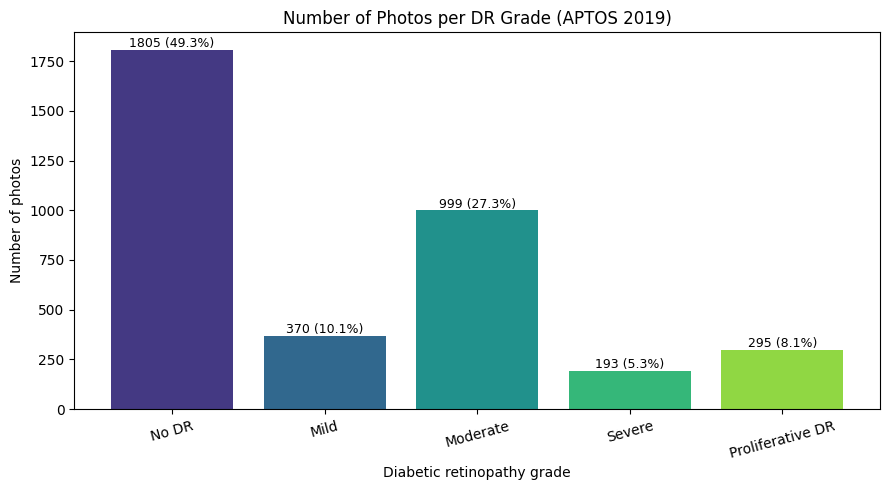

  figure saved: figures/01_data_exploration/class_distribution.png
Cell 7 finished: class distribution counted and charted.
 grade            stage  photo_count  percent_of_dataset
     0            No DR         1805                49.3
     1             Mild          370                10.1
     2         Moderate          999                27.3
     3           Severe          193                 5.3
     4 Proliferative DR          295                 8.1
The biggest grade has 9.4 times more photos than the smallest one.


In [7]:
# Cell 7: count the photos in each grade and chart how unbalanced the dataset is
class_counts_series = diabetic_retinopathy_labels_dataframe["diagnosis"].value_counts().sort_index()
class_percentages_series = (class_counts_series / class_counts_series.sum() * 100).round(1)
imbalance_ratio = class_counts_series.max() / class_counts_series.min()

class_distribution_dataframe = pd.DataFrame({
    "grade": class_counts_series.index,
    "stage": [diagnosis_stage_names[grade] for grade in class_counts_series.index],
    "photo_count": class_counts_series.values,
    "percent_of_dataset": class_percentages_series.values,
})
save_results_table(class_distribution_dataframe, "01_data_exploration", "class_distribution.csv")

figure_object, axis_object = plt.subplots(figsize=(9, 5))
axis_object.bar(class_distribution_dataframe["stage"], class_distribution_dataframe["photo_count"],
                color=seaborn_plotting_library.color_palette("viridis", len(class_counts_series)))
for bar_index, (photo_count, percent_value) in enumerate(zip(class_distribution_dataframe["photo_count"], class_distribution_dataframe["percent_of_dataset"])):
    axis_object.text(bar_index, photo_count + 15, f"{photo_count} ({percent_value}%)", ha="center", fontsize=9)
axis_object.set_title("Number of Photos per DR Grade (APTOS 2019)")
axis_object.set_xlabel("Diabetic retinopathy grade")
axis_object.set_ylabel("Number of photos")
plt.xticks(rotation=15)
save_current_figure("01_data_exploration", "class_distribution.png")

print("Cell 7 finished: class distribution counted and charted.")
print(class_distribution_dataframe.to_string(index=False))
print(f"The biggest grade has {imbalance_ratio:.1f} times more photos than the smallest one.")

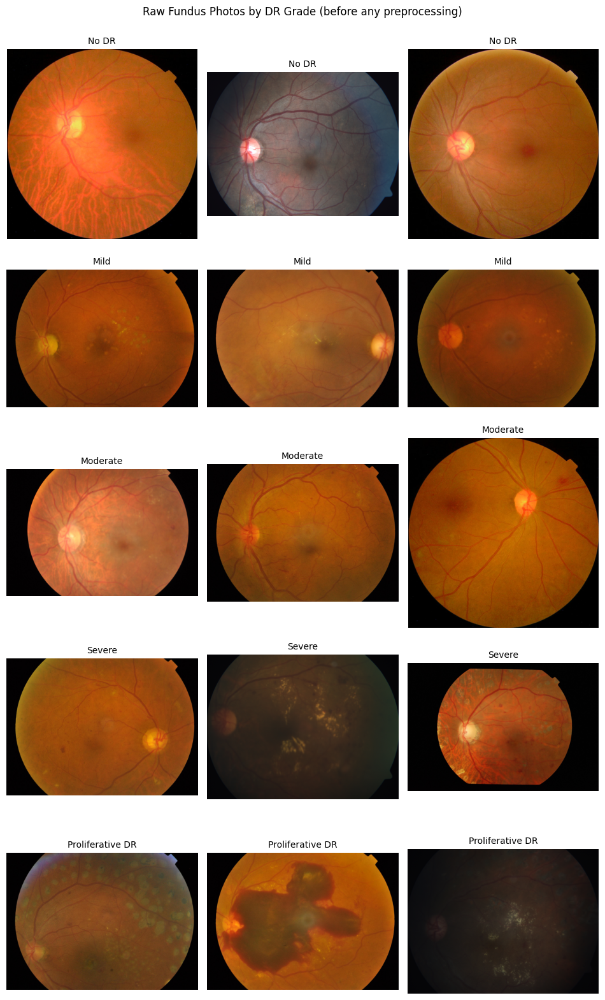

  figure saved: figures/01_data_exploration/sample_photos_by_grade.png
Cell 8 finished: sample photos shown for every grade.


In [8]:
# Cell 8: show three raw photos from each grade to see how the grades differ
number_of_examples_per_class = 3
figure_object, axis_grid = plt.subplots(len(list_of_class_indices), number_of_examples_per_class,
                                        figsize=(number_of_examples_per_class * 3.2, len(list_of_class_indices) * 3.2))
for class_label in list_of_class_indices:
    example_rows = diabetic_retinopathy_labels_dataframe[diabetic_retinopathy_labels_dataframe["diagnosis"] == class_label].sample(
        number_of_examples_per_class, random_state=RANDOM_SEED)
    for column_index, (_, example_row) in enumerate(example_rows.iterrows()):
        current_axis = axis_grid[class_label, column_index]
        current_axis.imshow(cv2.cvtColor(cv2.imread(build_image_path_from_id(example_row["id_code"])), cv2.COLOR_BGR2RGB))
        current_axis.set_title(diagnosis_stage_names[class_label], fontsize=10)
        current_axis.axis("off")
plt.suptitle("Raw Fundus Photos by DR Grade (before any preprocessing)", y=1.0)
save_current_figure("01_data_exploration", "sample_photos_by_grade.png")

print("Cell 8 finished: sample photos shown for every grade.")

  table saved: results/01_data_exploration/resolution_summary.csv


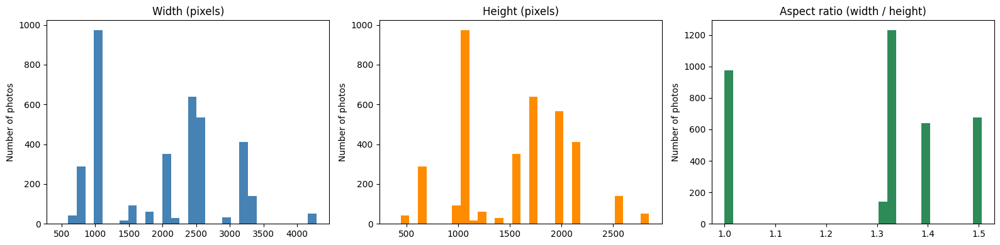

  figure saved: figures/01_data_exploration/resolution_and_aspect_ratio.png
Cell 9 finished: size and shape measured for every photo.
         width   height  aspect_ratio
count  3662.00  3662.00       3662.00
mean   2015.18  1526.83          1.28
std     884.30   542.66          0.18
min     474.00   358.00          1.00
25%    1050.00  1050.00          1.00
50%    2144.00  1536.00          1.33
75%    2588.00  1958.00          1.39
max    4288.00  2848.00          1.51
Number of different resolutions in the dataset: 17
Sizes and shapes vary a lot, so every photo must be brought to one square size without stretching the eye.


In [9]:
# Cell 9: measure the width, height and shape of every photo to see how much they vary
recorded_widths = []
recorded_heights = []
for image_id_code in diabetic_retinopathy_labels_dataframe["id_code"]:
    with Image.open(build_image_path_from_id(image_id_code)) as opened_image:
        image_width, image_height = opened_image.size
    recorded_widths.append(image_width)
    recorded_heights.append(image_height)

image_dimensions_dataframe = pd.DataFrame({
    "id_code": diabetic_retinopathy_labels_dataframe["id_code"], "width": recorded_widths, "height": recorded_heights,
})
image_dimensions_dataframe["aspect_ratio"] = image_dimensions_dataframe["width"] / image_dimensions_dataframe["height"]
number_of_distinct_resolutions = image_dimensions_dataframe.groupby(["width", "height"]).ngroups
resolution_summary_dataframe = image_dimensions_dataframe[["width", "height", "aspect_ratio"]].describe().round(2)
save_results_table(resolution_summary_dataframe, "01_data_exploration", "resolution_summary.csv", keep_index=True)

figure_object, axis_array = plt.subplots(1, 3, figsize=(16, 4))
for current_axis, column_name, colour, chart_title in zip(
    axis_array, ["width", "height", "aspect_ratio"], ["steelblue", "darkorange", "seagreen"],
    ["Width (pixels)", "Height (pixels)", "Aspect ratio (width / height)"],
):
    current_axis.hist(image_dimensions_dataframe[column_name], bins=30, color=colour)
    current_axis.set_title(chart_title)
    current_axis.set_ylabel("Number of photos")
save_current_figure("01_data_exploration", "resolution_and_aspect_ratio.png")

print("Cell 9 finished: size and shape measured for every photo.")
print(resolution_summary_dataframe)
print("Number of different resolutions in the dataset:", number_of_distinct_resolutions)
print("Sizes and shapes vary a lot, so every photo must be brought to one square size without stretching the eye.")

## 3. Preprocessing Methods
Three methods are built and compared. They all share the same first steps, so only the contrast step differs:

1. **Crop the black border** so only the eye is left.
2. **Pad to a square** with black. Many APTOS photos cut off the top and bottom of the eye, so the crop is wider than it is tall. Resizing that rectangle straight to a square would squash the eye into an oval, so it is padded to a square first and keeps its true shape.
3. **Circular mask** so only the round eye is left. The circle now fits the square, so the sides of the eye are no longer clipped.
4. **Contrast step**, the only part that differs:
   - **Resize only:** no enhancement. This is the baseline that shows whether enhancement helps at all.
   - **CLAHE:** boosts contrast in small patches of the brightness channel, which makes tiny spots easier to see without changing colours (Lee et al., 2023; Fatima et al., 2024).
   - **Ben Graham:** subtracts a blurred copy of the photo, removing uneven lighting and camera colour differences and leaving sharp details like spots and new vessels.
5. **Resize to 384 x 384.**

Which method wins is decided by experiment in section 9, not by opinion.

In [10]:
# Cell 10: shared step 1, crop away the black border around the eye
def crop_away_dark_borders(image_array_rgb, brightness_threshold=None):
    if brightness_threshold is None:
        brightness_threshold = project_configuration["dark_pixel_brightness_threshold"]
    non_dark_pixel_mask = cv2.cvtColor(image_array_rgb, cv2.COLOR_RGB2GRAY) > brightness_threshold
    if non_dark_pixel_mask.sum() == 0:
        return image_array_rgb
    non_dark_row_indices = np.where(non_dark_pixel_mask.any(axis=1))[0]
    non_dark_column_indices = np.where(non_dark_pixel_mask.any(axis=0))[0]
    cropped_image = image_array_rgb[non_dark_row_indices[0]:non_dark_row_indices[-1] + 1, non_dark_column_indices[0]:non_dark_column_indices[-1] + 1]
    if cropped_image.shape[0] < 10 or cropped_image.shape[1] < 10:
        return image_array_rgb
    return cropped_image


print("Cell 10 finished: border cropping function ready.")

Cell 10 finished: border cropping function ready.


In [11]:
# Cell 11: shared step 2, pad the crop to a centred square so the eye keeps its true round shape
def pad_to_centred_square(image_array_rgb, fill_value=0):
    image_height, image_width = image_array_rgb.shape[:2]
    square_side = max(image_height, image_width)
    top_padding = (square_side - image_height) // 2
    left_padding = (square_side - image_width) // 2
    return cv2.copyMakeBorder(
        image_array_rgb, top_padding, square_side - image_height - top_padding, left_padding, square_side - image_width - left_padding,
        cv2.BORDER_CONSTANT, value=(fill_value, fill_value, fill_value),
    )


print("Cell 11 finished: pad-to-square function ready. Padding keeps the eye round when it is resized.")

Cell 11 finished: pad-to-square function ready. Padding keeps the eye round when it is resized.


In [12]:
# Cell 12: shared step 3, blank out everything outside the circle that fits the square
def apply_circular_field_of_view_mask(square_image_rgb):
    image_height, image_width = square_image_rgb.shape[:2]
    circular_mask = np.zeros((image_height, image_width), dtype=np.uint8)
    cv2.circle(circular_mask, (image_width // 2, image_height // 2), min(image_height, image_width) // 2, 255, thickness=-1)
    return cv2.bitwise_and(square_image_rgb, square_image_rgb, mask=circular_mask)


print("Cell 12 finished: circular mask function ready.")

Cell 12 finished: circular mask function ready.


In [13]:
# Cell 13: contrast option A, CLAHE on the brightness channel only, then re-mask so the background stays pure black
def enhance_local_contrast_with_clahe(masked_image_rgb):
    lightness_channel, a_channel, b_channel = cv2.split(cv2.cvtColor(masked_image_rgb, cv2.COLOR_RGB2LAB))
    tile_count = project_configuration["clahe_tile_grid_size"]
    clahe_operator = cv2.createCLAHE(clipLimit=project_configuration["clahe_clip_limit"], tileGridSize=(tile_count, tile_count))
    enhanced_image = cv2.cvtColor(cv2.merge((clahe_operator.apply(lightness_channel), a_channel, b_channel)), cv2.COLOR_LAB2RGB)
    return apply_circular_field_of_view_mask(enhanced_image)


print("Cell 13 finished: CLAHE function ready, clip limit", project_configuration["clahe_clip_limit"],
      "on a", project_configuration["clahe_tile_grid_size"], "by", project_configuration["clahe_tile_grid_size"], "grid.")

Cell 13 finished: CLAHE function ready, clip limit 2.0 on a 8 by 8 grid.


In [14]:
# Cell 14: contrast option B, the Ben Graham method (subtract the blurred background, keep the inner eye)
def subtract_local_average_colour(image_array_rgb, gaussian_sigma):
    blurred_background_estimate = cv2.GaussianBlur(image_array_rgb, (0, 0), gaussian_sigma)
    return cv2.addWeighted(image_array_rgb, 4, blurred_background_estimate, -4, 128)


def keep_inner_eye_with_neutral_fill(image_array_rgb, radius_fraction=0.9, neutral_fill_value=128):
    image_height, image_width = image_array_rgb.shape[:2]
    inner_circle_mask = np.zeros((image_height, image_width), dtype=np.uint8)
    cv2.circle(inner_circle_mask, (image_width // 2, image_height // 2), int(min(image_width, image_height) // 2 * radius_fraction), 1, thickness=-1)
    inner_circle_mask = inner_circle_mask[:, :, np.newaxis]
    return (image_array_rgb * inner_circle_mask + neutral_fill_value * (1 - inner_circle_mask)).astype(np.uint8)


def apply_ben_graham_enhancement(resized_masked_image_rgb):
    gaussian_sigma = (resized_masked_image_rgb.shape[0] / 2) / project_configuration["ben_graham_blur_divisor"]
    return keep_inner_eye_with_neutral_fill(subtract_local_average_colour(resized_masked_image_rgb, gaussian_sigma))


print("Cell 14 finished: Ben Graham function ready. The blur size is the eye radius divided by",
      project_configuration["ben_graham_blur_divisor"], "as in Graham's original method.")

Cell 14 finished: Ben Graham function ready. The blur size is the eye radius divided by 30 as in Graham's original method.


In [15]:
# Cell 15: join the steps into one pipeline with a method switch, and cache each cleaned photo to save time
def load_image_as_rgb(image_file_path):
    return cv2.cvtColor(cv2.imread(image_file_path), cv2.COLOR_BGR2RGB)


def resize_to_target(image_rgb, target_size):
    return cv2.resize(image_rgb, (target_size, target_size), interpolation=cv2.INTER_AREA)


def run_preprocessing_steps(image_rgb, target_size, preprocessing_method):
    cropped_image = crop_away_dark_borders(image_rgb)
    squared_image = pad_to_centred_square(cropped_image)
    masked_image = apply_circular_field_of_view_mask(squared_image)
    if preprocessing_method == "clahe":
        enhanced_image = enhance_local_contrast_with_clahe(masked_image)
        final_image = resize_to_target(enhanced_image, target_size)
    elif preprocessing_method == "ben_graham":
        final_image = apply_ben_graham_enhancement(resize_to_target(masked_image, target_size))
        enhanced_image = final_image
    elif preprocessing_method == "resize_only":
        enhanced_image = masked_image
        final_image = resize_to_target(masked_image, target_size)
    else:
        raise ValueError(f"Unknown preprocessing method: {preprocessing_method}")
    return {
        "original": image_rgb,
        "cropped": cropped_image,
        "squared": squared_image,
        "masked": masked_image,
        "enhanced": enhanced_image,
        "resized": final_image,
    }


def preprocess_fundus_image(image_file_path, target_size, preprocessing_method):
    cache_file_name = os.path.splitext(os.path.basename(image_file_path))[0] + f"_{target_size}.npy"
    cache_file_path = os.path.join(cache_folder_paths[preprocessing_method], cache_file_name)
    if os.path.exists(cache_file_path):
        return np.load(cache_file_path)
    preprocessed_image = run_preprocessing_steps(load_image_as_rgb(image_file_path), target_size, preprocessing_method)["resized"]
    np.save(cache_file_path, preprocessed_image)
    return preprocessed_image


print("Cell 15 finished: one pipeline, three methods:", preprocessing_method_names)
print("Shared order: crop border, pad to square, circular mask, then the method's contrast step, then resize.")

Cell 15 finished: one pipeline, three methods: ['resize_only', 'clahe', 'ben_graham']
Shared order: crop border, pad to square, circular mask, then the method's contrast step, then resize.


  table saved: results/02_preprocessing_methods/preprocessing_tests_per_photo.csv
  table saved: results/02_preprocessing_methods/preprocessing_tests_summary.csv


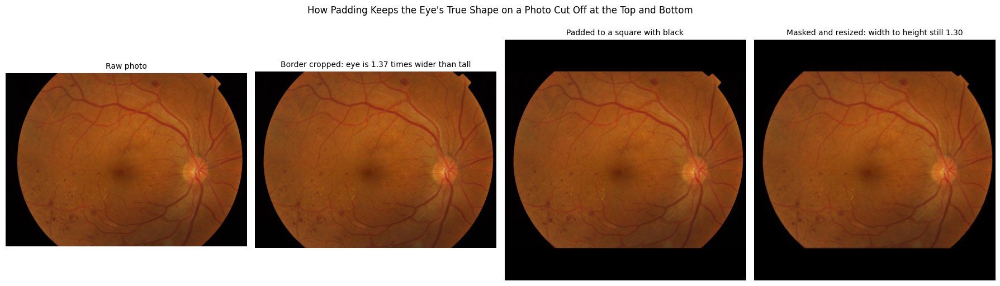

  figure saved: figures/02_preprocessing_methods/eye_shape_kept_by_padding.png
Cell 16 finished: preprocessing tests complete on 50 photos.
                                                           test  passed_percent  required_percent result
  Every method outputs a square colour image of the target size           100.0               100   PASS
   The eye keeps its shape after resizing (distortion under 3%)            80.0               100   FAIL
         Background corners are pure black (resize only, CLAHE)           100.0               100   PASS
               Background corners are neutral grey (Ben Graham)           100.0               100   PASS
                     CLAHE raises local contrast inside the eye           100.0                90   PASS
Ben Graham removes the background colour (centre near grey 128)           100.0                90   PASS

Photos in the test sample where the eye is cut at the top and bottom: 34 of 50
Average shape distortion on those photos afte

In [16]:
# Cell 16: PREPROCESSING TESTS, check every method really did what it should, including that the eye keeps its shape
def measure_eye_width_to_height_ratio(image_rgb):
    eye_pixels = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY) > project_configuration["dark_pixel_brightness_threshold"]
    eye_rows = np.where(eye_pixels.any(axis=1))[0]
    eye_columns = np.where(eye_pixels.any(axis=0))[0]
    return (eye_columns[-1] - eye_columns[0] + 1) / (eye_rows[-1] - eye_rows[0] + 1)


def measure_average_local_contrast_inside_eye(image_rgb, window_size=15):
    image_height, image_width = image_rgb.shape[:2]
    inner_eye_mask = np.zeros((image_height, image_width), dtype=np.uint8)
    cv2.circle(inner_eye_mask, (image_width // 2, image_height // 2), int(min(image_height, image_width) // 2 * 0.85), 1, thickness=-1)
    green_channel = image_rgb[:, :, 1].astype(np.float32)
    local_mean = cv2.blur(green_channel, (window_size, window_size))
    local_standard_deviation = np.sqrt(np.clip(cv2.blur(green_channel ** 2, (window_size, window_size)) - local_mean ** 2, 0, None))
    return float(local_standard_deviation[inner_eye_mask.astype(bool)].mean())


target_size_for_tests = project_configuration["target_image_size"]
preprocessing_test_sample = diabetic_retinopathy_labels_dataframe.sample(50, random_state=RANDOM_SEED)
per_photo_test_rows = []
for _, sample_row in preprocessing_test_sample.iterrows():
    raw_image_rgb = load_image_as_rgb(build_image_path_from_id(sample_row["id_code"]))
    steps_by_method = {method: run_preprocessing_steps(raw_image_rgb, target_size_for_tests, method) for method in preprocessing_method_names}
    cropped_image = steps_by_method["resize_only"]["cropped"]
    ratio_before = cropped_image.shape[1] / cropped_image.shape[0]
    ratio_after = measure_eye_width_to_height_ratio(steps_by_method["resize_only"]["resized"])
    clahe_final = steps_by_method["clahe"]["resized"]
    ben_graham_final = steps_by_method["ben_graham"]["resized"]
    inner_region = ben_graham_final[target_size_for_tests // 4: 3 * target_size_for_tests // 4, target_size_for_tests // 4: 3 * target_size_for_tests // 4]
    per_photo_test_rows.append({
        "id_code": sample_row["id_code"],
        "eye_ratio_before": ratio_before,
        "eye_ratio_after": ratio_after,
        "shape_distortion_percent": abs(ratio_after - ratio_before) / ratio_before * 100,
        "all_outputs_correct_size": all(steps["resized"].shape == (target_size_for_tests, target_size_for_tests, 3) and steps["resized"].dtype == np.uint8 for steps in steps_by_method.values()),
        "black_corners_resize_only_and_clahe": int(steps_by_method["resize_only"]["resized"][0, 0].max()) == 0 and int(clahe_final[0, 0].max()) == 0,
        "neutral_corners_ben_graham": bool(np.all(ben_graham_final[0, 0] == 128)),
        "clahe_raised_local_contrast": measure_average_local_contrast_inside_eye(clahe_final) > measure_average_local_contrast_inside_eye(steps_by_method["resize_only"]["resized"]),
        "ben_graham_background_removed": abs(float(inner_region.mean()) - 128) < 30,
    })
per_photo_test_dataframe = pd.DataFrame(per_photo_test_rows)
save_results_table(per_photo_test_dataframe.round(4), "02_preprocessing_methods", "preprocessing_tests_per_photo.csv")

cut_eye_rows = per_photo_test_dataframe[per_photo_test_dataframe["eye_ratio_before"] > 1.05]
preprocessing_test_summary_dataframe = pd.DataFrame([
    {"test": "Every method outputs a square colour image of the target size", "passed_percent": per_photo_test_dataframe["all_outputs_correct_size"].mean() * 100, "required_percent": 100},
    {"test": "The eye keeps its shape after resizing (distortion under 3%)", "passed_percent": (per_photo_test_dataframe["shape_distortion_percent"] < 3).mean() * 100, "required_percent": 100},
    {"test": "Background corners are pure black (resize only, CLAHE)", "passed_percent": per_photo_test_dataframe["black_corners_resize_only_and_clahe"].mean() * 100, "required_percent": 100},
    {"test": "Background corners are neutral grey (Ben Graham)", "passed_percent": per_photo_test_dataframe["neutral_corners_ben_graham"].mean() * 100, "required_percent": 100},
    {"test": "CLAHE raises local contrast inside the eye", "passed_percent": per_photo_test_dataframe["clahe_raised_local_contrast"].mean() * 100, "required_percent": 90},
    {"test": "Ben Graham removes the background colour (centre near grey 128)", "passed_percent": per_photo_test_dataframe["ben_graham_background_removed"].mean() * 100, "required_percent": 90},
])
preprocessing_test_summary_dataframe["result"] = np.where(
    preprocessing_test_summary_dataframe["passed_percent"] >= preprocessing_test_summary_dataframe["required_percent"], "PASS", "FAIL")
save_results_table(preprocessing_test_summary_dataframe.round(1), "02_preprocessing_methods", "preprocessing_tests_summary.csv")

most_cut_row = per_photo_test_dataframe.loc[per_photo_test_dataframe["eye_ratio_before"].idxmax()]
most_cut_steps = run_preprocessing_steps(load_image_as_rgb(build_image_path_from_id(most_cut_row["id_code"])), target_size_for_tests, "resize_only")
figure_object, axis_array = plt.subplots(1, 4, figsize=(18, 5))
for current_axis, step_name, panel_title in zip(axis_array, ["original", "cropped", "squared", "resized"], [
    "Raw photo",
    f"Border cropped: eye is {most_cut_row['eye_ratio_before']:.2f} times wider than tall",
    "Padded to a square with black",
    f"Masked and resized: width to height still {most_cut_row['eye_ratio_after']:.2f}",
]):
    current_axis.imshow(most_cut_steps[step_name])
    current_axis.set_title(panel_title, fontsize=10)
    current_axis.axis("off")
plt.suptitle("How Padding Keeps the Eye's True Shape on a Photo Cut Off at the Top and Bottom", y=1.02)
save_current_figure("02_preprocessing_methods", "eye_shape_kept_by_padding.png")

print("Cell 16 finished: preprocessing tests complete on", len(per_photo_test_dataframe), "photos.")
print(preprocessing_test_summary_dataframe.round(1).to_string(index=False))
print()
print(f"Photos in the test sample where the eye is cut at the top and bottom: {len(cut_eye_rows)} of {len(per_photo_test_dataframe)}")
if len(cut_eye_rows) > 0:
    print(f"Average shape distortion on those photos after preprocessing: {cut_eye_rows['shape_distortion_percent'].mean():.1f}%")

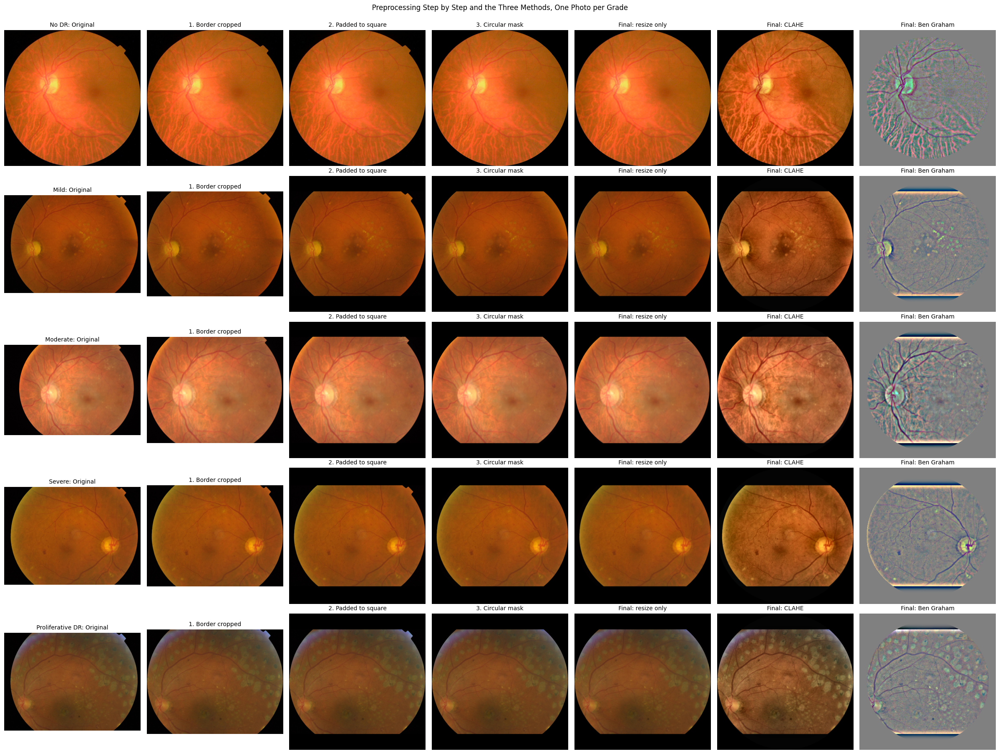

  figure saved: figures/02_preprocessing_methods/preprocessing_steps_and_methods_per_grade.png
  table saved: results/02_preprocessing_methods/local_contrast_per_photo_per_method.csv
  table saved: results/02_preprocessing_methods/local_contrast_summary_per_method.csv
Cell 17 finished: step-by-step figure saved and local contrast compared on 200 photos.
     method  average_local_contrast  times_resize_only
resize_only                   5.458              1.000
      clahe                  10.432              1.911
 ben_graham                  17.729              3.248
Higher local contrast makes small spots easier to see, but it does not prove better grading.
That is decided by the preprocessing experiment in section 9.


In [17]:
# Cell 17: show every step for one photo per grade, and compare how much local contrast each method gives
step_preview_rows = [
    diabetic_retinopathy_labels_dataframe[diabetic_retinopathy_labels_dataframe["diagnosis"] == class_label].sample(1, random_state=RANDOM_SEED).iloc[0]
    for class_label in list_of_class_indices
]
preview_column_titles = ["Original", "1. Border cropped", "2. Padded to square", "3. Circular mask", "Final: resize only", "Final: CLAHE", "Final: Ben Graham"]
figure_object, axis_grid = plt.subplots(len(step_preview_rows), len(preview_column_titles), figsize=(24, 3.6 * len(step_preview_rows)))
for row_index, preview_row in enumerate(step_preview_rows):
    raw_image_rgb = load_image_as_rgb(build_image_path_from_id(preview_row["id_code"]))
    shared_steps = run_preprocessing_steps(raw_image_rgb, project_configuration["target_image_size"], "resize_only")
    panel_images = [
        shared_steps["original"], shared_steps["cropped"], shared_steps["squared"], shared_steps["masked"], shared_steps["resized"],
        run_preprocessing_steps(raw_image_rgb, project_configuration["target_image_size"], "clahe")["resized"],
        run_preprocessing_steps(raw_image_rgb, project_configuration["target_image_size"], "ben_graham")["resized"],
    ]
    for column_index, panel_image in enumerate(panel_images):
        current_axis = axis_grid[row_index, column_index]
        current_axis.imshow(panel_image)
        grade_prefix = f"{diagnosis_stage_names[int(preview_row['diagnosis'])]}: " if column_index == 0 else ""
        current_axis.set_title(grade_prefix + preview_column_titles[column_index], fontsize=10)
        current_axis.axis("off")
plt.suptitle("Preprocessing Step by Step and the Three Methods, One Photo per Grade", y=1.0)
save_current_figure("02_preprocessing_methods", "preprocessing_steps_and_methods_per_grade.png")

contrast_sample = diabetic_retinopathy_labels_dataframe.sample(200, random_state=RANDOM_SEED)
contrast_rows = []
for _, sample_row in contrast_sample.iterrows():
    raw_image_rgb = load_image_as_rgb(build_image_path_from_id(sample_row["id_code"]))
    contrast_row = {"id_code": sample_row["id_code"], "grade": int(sample_row["diagnosis"])}
    for method_name in preprocessing_method_names:
        contrast_row[f"local_contrast_{method_name}"] = measure_average_local_contrast_inside_eye(
            run_preprocessing_steps(raw_image_rgb, project_configuration["target_image_size"], method_name)["resized"])
    contrast_rows.append(contrast_row)
contrast_dataframe = pd.DataFrame(contrast_rows)
save_results_table(contrast_dataframe.round(3), "02_preprocessing_methods", "local_contrast_per_photo_per_method.csv")
contrast_summary_dataframe = pd.DataFrame({
    "method": preprocessing_method_names,
    "average_local_contrast": [contrast_dataframe[f"local_contrast_{method_name}"].mean() for method_name in preprocessing_method_names],
})
contrast_summary_dataframe["times_resize_only"] = contrast_summary_dataframe["average_local_contrast"] / contrast_summary_dataframe.loc[0, "average_local_contrast"]
save_results_table(contrast_summary_dataframe.round(3), "02_preprocessing_methods", "local_contrast_summary_per_method.csv")

print("Cell 17 finished: step-by-step figure saved and local contrast compared on 200 photos.")
print(contrast_summary_dataframe.round(3).to_string(index=False))
print("Higher local contrast makes small spots easier to see, but it does not prove better grading.")
print("That is decided by the preprocessing experiment in section 9.")

## 4. Image Size Check
A bigger photo keeps more of the tiny spots that show the disease, but it makes training slower. This check measures both sides **without training any model**:

- **Detail kept:** 100 photos (20 per grade) are cleaned at a large size of 1000 x 1000, shrunk to each size from 224 to 512, then grown back. **SSIM** (structural similarity, 1.0 means identical) compares the result with the original, inside the eye only, on the green channel where lesions stand out most.
- **Cost:** each model is timed on the GPU at each size with a batch of 16, and its memory use is checked. This also confirms that a batch size of 16 fits.

Sizes go up in steps of 32 because all three models shrink the photo 32 times before their last layer. The pipeline uses 384. These results show what 384 keeps and what a bigger size would cost.

In [18]:
# Cell 18: image size check part 1, measure how much structure survives at each size using SSIM
candidate_image_sizes = list(range(224, 513, 32))
reference_image_size = 1000
images_per_grade_for_size_study = 20

size_study_sample_dataframe = diabetic_retinopathy_labels_dataframe.groupby("diagnosis").sample(n=images_per_grade_for_size_study, random_state=RANDOM_SEED)
inner_region_mask = np.zeros((reference_image_size, reference_image_size), dtype=np.uint8)
cv2.circle(inner_region_mask, (reference_image_size // 2, reference_image_size // 2), int(reference_image_size // 2 * 0.85), 1, thickness=-1)
inner_region_mask = inner_region_mask.astype(bool)


def compute_structural_similarity_map(first_channel, second_channel):
    first_channel = first_channel.astype(np.float64)
    second_channel = second_channel.astype(np.float64)
    constant_one, constant_two = (0.01 * 255) ** 2, (0.03 * 255) ** 2
    blur = partial(cv2.GaussianBlur, ksize=(11, 11), sigmaX=1.5)
    mean_first, mean_second = blur(first_channel), blur(second_channel)
    variance_first = blur(first_channel ** 2) - mean_first ** 2
    variance_second = blur(second_channel ** 2) - mean_second ** 2
    covariance = blur(first_channel * second_channel) - mean_first * mean_second
    return ((2 * mean_first * mean_second + constant_one) * (2 * covariance + constant_two)) / (
        (mean_first ** 2 + mean_second ** 2 + constant_one) * (variance_first + variance_second + constant_two))


def build_reference_green_channel(image_file_path):
    masked_image = run_preprocessing_steps(load_image_as_rgb(image_file_path), reference_image_size, "resize_only")["masked"]
    resize_method = cv2.INTER_AREA if masked_image.shape[0] >= reference_image_size else cv2.INTER_CUBIC
    return cv2.resize(masked_image, (reference_image_size, reference_image_size), interpolation=resize_method)[:, :, 1]


def measure_structure_kept_at_size(reference_green_channel, candidate_size):
    shrunk_channel = cv2.resize(reference_green_channel, (candidate_size, candidate_size), interpolation=cv2.INTER_AREA)
    restored_channel = cv2.resize(shrunk_channel, (reference_image_size, reference_image_size), interpolation=cv2.INTER_CUBIC)
    return float(compute_structural_similarity_map(reference_green_channel, restored_channel)[inner_region_mask].mean())


size_study_start_time = time.time()
detail_retention_rows = []
for _, sample_row in size_study_sample_dataframe.iterrows():
    reference_green_channel = build_reference_green_channel(build_image_path_from_id(sample_row["id_code"]))
    for candidate_size in candidate_image_sizes:
        detail_retention_rows.append({
            "id_code": sample_row["id_code"], "diagnosis": int(sample_row["diagnosis"]), "image_size": candidate_size,
            "ssim_kept": measure_structure_kept_at_size(reference_green_channel, candidate_size),
        })
detail_retention_dataframe = pd.DataFrame(detail_retention_rows)
save_results_table(detail_retention_dataframe, "03_image_size_study", "ssim_per_photo_per_size.csv")

detail_retention_summary = detail_retention_dataframe.groupby("image_size")["ssim_kept"].agg(["mean", "std", "count"])
detail_retention_summary["ci95_half_width"] = 1.96 * detail_retention_summary["std"] / np.sqrt(detail_retention_summary["count"])

print(f"Cell 18 finished: structure measured on {len(size_study_sample_dataframe)} photos in {(time.time() - size_study_start_time) / 60:.1f} minutes.")
print("Average SSIM at each size compared with the 1000 x 1000 original (1.0 means nothing was lost):")
print(detail_retention_summary[["mean", "ci95_half_width"]].round(4).to_string())

  table saved: results/03_image_size_study/ssim_per_photo_per_size.csv
Cell 18 finished: structure measured on 100 photos in 1.3 minutes.
Average SSIM at each size compared with the 1000 x 1000 original (1.0 means nothing was lost):
              mean  ci95_half_width
image_size                         
224         0.9630           0.0030
256         0.9665           0.0027
288         0.9700           0.0025
320         0.9732           0.0023
352         0.9754           0.0021
384         0.9774           0.0019
416         0.9795           0.0017
448         0.9814           0.0016
480         0.9828           0.0014
512         0.9843           0.0013


In [19]:
# Cell 19: image size check part 2, time one training step for each model at each size and check GPU memory with a batch of 16
architecture_builders_for_timing = {"efficientnet_b3": efficientnet_b3, "efficientnet_b0": efficientnet_b0, "resnet50": resnet50}
number_of_warmup_steps = 2
number_of_timed_steps = 5
usable_gpu_memory_gigabytes = torch.cuda.get_device_properties(0).total_memory / 1e9 * 0.9 if is_gpu_available else float("nan")
expected_training_images = round(len(diabetic_retinopathy_labels_dataframe) * (1 - project_configuration["validation_split_fraction"] - project_configuration["test_split_fraction"]))
expected_validation_images = round(len(diabetic_retinopathy_labels_dataframe) * project_configuration["validation_split_fraction"])
training_batches_per_epoch = int(np.ceil(expected_training_images / project_configuration["batch_size"]))
validation_batches_per_epoch = int(np.ceil(expected_validation_images / project_configuration["batch_size"]))
expected_epochs_per_architecture = 20

gpu_cost_rows = []
if not is_gpu_available:
    print("No GPU found, so the timing check is skipped. Turn on the GPU to get real timing numbers.")
else:
    for architecture_name, architecture_builder in architecture_builders_for_timing.items():
        timing_model = architecture_builder(weights=None, num_classes=project_configuration["number_of_dr_classes"]).to(compute_device)
        timing_model.train()
        timing_optimizer = optimizers.Adam(timing_model.parameters(), lr=1e-4)
        timing_loss_function = neural_network_layers.CrossEntropyLoss()
        for candidate_size in candidate_image_sizes:
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
            try:
                fake_images = torch.randn(project_configuration["batch_size"], 3, candidate_size, candidate_size, device=compute_device)
                fake_labels = torch.randint(0, project_configuration["number_of_dr_classes"], (project_configuration["batch_size"],), device=compute_device)
                for step_index in range(number_of_warmup_steps + number_of_timed_steps):
                    if step_index == number_of_warmup_steps:
                        torch.cuda.synchronize()
                        timing_start = time.time()
                    timing_optimizer.zero_grad()
                    timing_loss_function(timing_model(fake_images), fake_labels).backward()
                    timing_optimizer.step()
                torch.cuda.synchronize()
                seconds_per_training_step = (time.time() - timing_start) / number_of_timed_steps
                peak_memory_gigabytes = torch.cuda.max_memory_allocated() / 1e9
                fits_in_memory = peak_memory_gigabytes <= usable_gpu_memory_gigabytes
            except torch.cuda.OutOfMemoryError:
                seconds_per_training_step, peak_memory_gigabytes, fits_in_memory = float("nan"), float("nan"), False
                timing_optimizer.zero_grad(set_to_none=True)
            fake_images = fake_labels = None
            torch.cuda.empty_cache()
            seconds_per_epoch = seconds_per_training_step * (training_batches_per_epoch + validation_batches_per_epoch / 3)
            gpu_cost_rows.append({
                "architecture": architecture_name, "image_size": candidate_size,
                "seconds_per_training_step": round(seconds_per_training_step, 4), "peak_memory_gigabytes": round(peak_memory_gigabytes, 2),
                "fits_in_memory": fits_in_memory, "estimated_training_minutes": round(seconds_per_epoch * expected_epochs_per_architecture / 60, 1),
            })
        timing_model = timing_optimizer = None
        torch.cuda.empty_cache()

gpu_cost_dataframe = pd.DataFrame(gpu_cost_rows)
if len(gpu_cost_dataframe) > 0:
    save_results_table(gpu_cost_dataframe, "03_image_size_study", "gpu_cost_per_size.csv")
    print("Cell 19 finished: training speed and memory measured for every model and size.")
    print(gpu_cost_dataframe.pivot(index="image_size", columns="architecture", values="estimated_training_minutes").to_string())
    print("Peak GPU memory at 384 with a batch of 16 (GB):")
    print(gpu_cost_dataframe[gpu_cost_dataframe["image_size"] == project_configuration["target_image_size"]][["architecture", "peak_memory_gigabytes", "fits_in_memory"]].to_string(index=False))
else:
    print("Cell 19 finished: timing skipped because there is no GPU.")

  table saved: results/03_image_size_study/gpu_cost_per_size.csv
Cell 19 finished: training speed and memory measured for every model and size.
architecture  efficientnet_b0  efficientnet_b3  resnet50
image_size                                              
224                       4.5              8.9       9.9
256                       5.5             10.8      11.9
288                       7.0             14.0      17.9
320                       8.5             17.0      22.0
352                      10.4             21.0      25.6
384                      11.9             24.0      29.3
416                      14.3             28.8      36.1
448                      16.3             32.9      41.5
480                      19.0             38.3      49.1
512                      20.8             42.3      53.9
Peak GPU memory at 384 with a batch of 16 (GB):
   architecture  peak_memory_gigabytes  fits_in_memory
efficientnet_b3                   8.23            True
efficientnet_b

  table saved: results/03_image_size_study/image_size_evidence_table.csv
  summary saved: results/03_image_size_study/image_size_study_summary.json


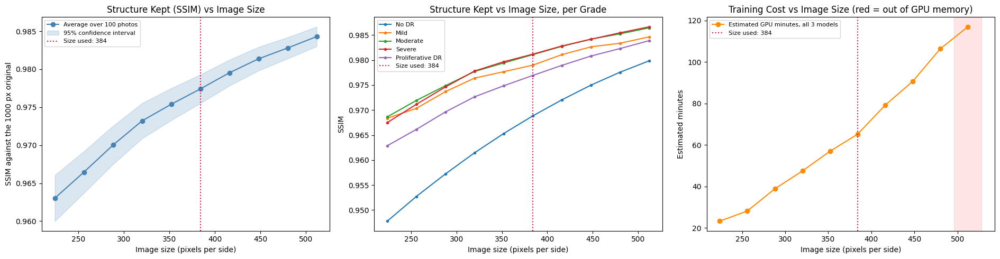

  figure saved: figures/03_image_size_study/image_size_ssim_vs_cost.png
Cell 20 finished: image size evidence table and chart saved.
            mean_ssim_kept  ci95_half_width  gain_from_next_size_up  all_three_models_fit_in_memory  estimated_minutes_all_three_models  time_compared_with_size_used
image_size                                                                                                                                                           
224                 0.9630           0.0030                  0.0034                            True                                23.3                        0.3574
256                 0.9665           0.0027                  0.0036                            True                                28.2                        0.4325
288                 0.9700           0.0025                  0.0032                            True                                38.9                        0.5966
320                 0.9732           

In [20]:
# Cell 20: image size check part 3, put structure kept and training cost side by side and show where 384 sits
used_image_size = project_configuration["target_image_size"]
largest_candidate_size = max(candidate_image_sizes)
smallest_candidate_size = min(candidate_image_sizes)

size_evidence_table = detail_retention_summary[["mean", "ci95_half_width"]].rename(columns={"mean": "mean_ssim_kept"})
per_image_retention_table = detail_retention_dataframe.pivot(index="id_code", columns="image_size", values="ssim_kept")
size_evidence_table["gain_from_next_size_up"] = [
    (per_image_retention_table[size + 32] - per_image_retention_table[size]).mean() if size + 32 in per_image_retention_table.columns else np.nan
    for size in size_evidence_table.index
]
timing_is_available = len(gpu_cost_dataframe) > 0
if timing_is_available:
    cost_by_size = gpu_cost_dataframe.groupby("image_size").agg(
        all_three_models_fit_in_memory=("fits_in_memory", "all"),
        estimated_minutes_all_three_models=("estimated_training_minutes", lambda minutes: minutes.sum(min_count=len(minutes))),
    )
    size_evidence_table = size_evidence_table.join(cost_by_size)
    size_evidence_table["time_compared_with_size_used"] = (
        size_evidence_table["estimated_minutes_all_three_models"] / size_evidence_table.loc[used_image_size, "estimated_minutes_all_three_models"])
save_results_table(size_evidence_table.round(4).reset_index(), "03_image_size_study", "image_size_evidence_table.csv")

ssim_by_size = size_evidence_table["mean_ssim_kept"]
image_size_study_summary = {
    "size_used_in_pipeline": used_image_size,
    "photos_measured": int(len(size_study_sample_dataframe)),
    f"ssim_at_{smallest_candidate_size}": round(float(ssim_by_size.loc[smallest_candidate_size]), 4),
    f"ssim_at_{used_image_size}": round(float(ssim_by_size.loc[used_image_size]), 4),
    f"ssim_at_{largest_candidate_size}": round(float(ssim_by_size.loc[largest_candidate_size]), 4),
}
if timing_is_available:
    image_size_study_summary.update({
        f"estimated_minutes_three_models_at_{used_image_size}": float(size_evidence_table.loc[used_image_size, "estimated_minutes_all_three_models"]),
        f"time_multiplier_{used_image_size}_to_{largest_candidate_size}": round(float(size_evidence_table.loc[largest_candidate_size, "time_compared_with_size_used"]), 2),
        f"all_models_fit_in_memory_at_{largest_candidate_size}": bool(size_evidence_table.loc[largest_candidate_size, "all_three_models_fit_in_memory"]),
    })
save_results_json(image_size_study_summary, "03_image_size_study", "image_size_study_summary.json")

figure_object, axis_array = plt.subplots(1, 3 if timing_is_available else 2, figsize=(19 if timing_is_available else 13, 5))
axis_array[0].plot(candidate_image_sizes, ssim_by_size, marker="o", color="steelblue", label="Average over 100 photos")
axis_array[0].fill_between(candidate_image_sizes, ssim_by_size - size_evidence_table["ci95_half_width"], ssim_by_size + size_evidence_table["ci95_half_width"],
                           alpha=0.2, color="steelblue", label="95% confidence interval")
axis_array[0].set_title("Structure Kept (SSIM) vs Image Size")
axis_array[0].set_ylabel("SSIM against the 1000 px original")
for grade_index, grade_rows in detail_retention_dataframe.groupby("diagnosis"):
    grade_means = grade_rows.groupby("image_size")["ssim_kept"].mean()
    axis_array[1].plot(grade_means.index, grade_means.values, marker="o", markersize=3, label=diagnosis_stage_names[grade_index])
axis_array[1].set_title("Structure Kept vs Image Size, per Grade")
axis_array[1].set_ylabel("SSIM")
if timing_is_available:
    axis_array[2].plot(candidate_image_sizes, size_evidence_table["estimated_minutes_all_three_models"], marker="o", color="darkorange", label="Estimated GPU minutes, all 3 models")
    for size_that_does_not_fit in [size for size in candidate_image_sizes if not size_evidence_table.loc[size, "all_three_models_fit_in_memory"]]:
        axis_array[2].axvspan(size_that_does_not_fit - 16, size_that_does_not_fit + 16, color="red", alpha=0.1)
    axis_array[2].set_title("Training Cost vs Image Size (red = out of GPU memory)")
    axis_array[2].set_ylabel("Estimated minutes")
for current_axis in axis_array:
    current_axis.axvline(used_image_size, color="crimson", linestyle=":", label=f"Size used: {used_image_size}")
    current_axis.set_xlabel("Image size (pixels per side)")
    current_axis.legend(fontsize=8)
save_current_figure("03_image_size_study", "image_size_ssim_vs_cost.png")

print("Cell 20 finished: image size evidence table and chart saved.")
print(size_evidence_table.round(4).to_string())
print(f"At {used_image_size}, SSIM is {ssim_by_size.loc[used_image_size]:.3f}. At {largest_candidate_size} it is {ssim_by_size.loc[largest_candidate_size]:.3f}.")
if timing_is_available:
    print(f"Going to {largest_candidate_size} would make training about {size_evidence_table.loc[largest_candidate_size, 'time_compared_with_size_used']:.2f} times slower.")

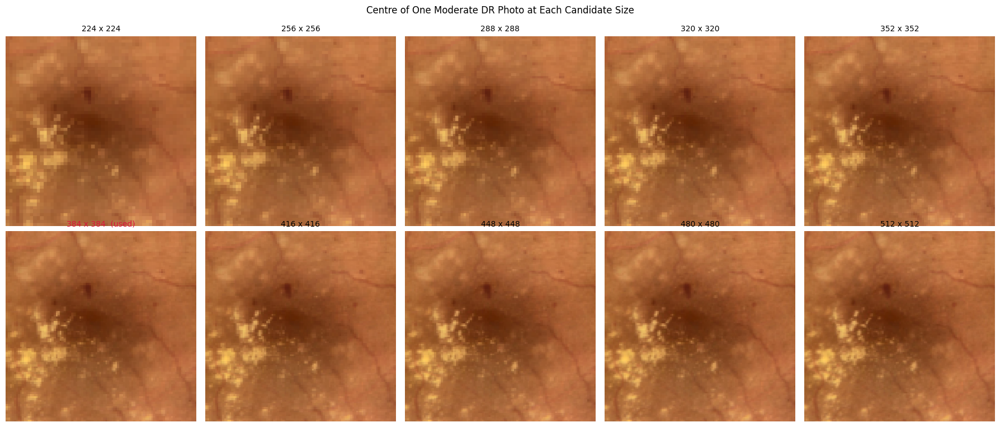

  figure saved: figures/03_image_size_study/image_size_patch_comparison.png
Cell 21 finished: patch comparison saved. Small red dots and vessel edges blur as the size drops.


In [21]:
# Cell 21: image size check part 4, show the same small patch of one eye at every size so the blur is visible
patch_example_row = size_study_sample_dataframe[size_study_sample_dataframe["diagnosis"] == 2].iloc[0]
patch_reference_rgb = cv2.resize(
    run_preprocessing_steps(load_image_as_rgb(build_image_path_from_id(patch_example_row["id_code"])), reference_image_size, "clahe")["enhanced"],
    (reference_image_size, reference_image_size), interpolation=cv2.INTER_AREA,
)
patch_start, patch_end = int(reference_image_size * 0.375), int(reference_image_size * 0.625)
number_of_patch_columns = 5
number_of_patch_rows = int(np.ceil(len(candidate_image_sizes) / number_of_patch_columns))
figure_object, axis_grid = plt.subplots(number_of_patch_rows, number_of_patch_columns, figsize=(18, 3.8 * number_of_patch_rows), squeeze=False)
for panel_index, candidate_size in enumerate(candidate_image_sizes):
    restored_image = cv2.resize(cv2.resize(patch_reference_rgb, (candidate_size, candidate_size), interpolation=cv2.INTER_AREA),
                                (reference_image_size, reference_image_size), interpolation=cv2.INTER_NEAREST)
    current_axis = axis_grid[panel_index // number_of_patch_columns, panel_index % number_of_patch_columns]
    current_axis.imshow(restored_image[patch_start:patch_end, patch_start:patch_end])
    is_used_size = candidate_size == used_image_size
    current_axis.set_title(f"{candidate_size} x {candidate_size}" + ("  (used)" if is_used_size else ""), fontsize=10, color="crimson" if is_used_size else "black")
    current_axis.axis("off")
for empty_panel_index in range(len(candidate_image_sizes), number_of_patch_rows * number_of_patch_columns):
    axis_grid[empty_panel_index // number_of_patch_columns, empty_panel_index % number_of_patch_columns].axis("off")
plt.suptitle("Centre of One Moderate DR Photo at Each Candidate Size", y=1.0)
save_current_figure("03_image_size_study", "image_size_patch_comparison.png")

print("Cell 21 finished: patch comparison saved. Small red dots and vessel edges blur as the size drops.")

In [22]:
# Cell 22: clean every photo once with each of the three methods and cache the results, using worker processes
class CacheBuilderDataset(Dataset):
    def __init__(self, image_id_codes, target_image_size, preprocessing_method):
        self.image_id_codes = list(image_id_codes)
        self.target_image_size = target_image_size
        self.preprocessing_method = preprocessing_method

    def __len__(self):
        return len(self.image_id_codes)

    def __getitem__(self, item_index):
        preprocess_fundus_image(build_image_path_from_id(self.image_id_codes[item_index]), self.target_image_size, self.preprocessing_method)
        return 0


cache_build_rows = []
for method_name in preprocessing_method_names:
    cache_build_start_time = time.time()
    cache_builder_loader = DataLoader(
        CacheBuilderDataset(diabetic_retinopathy_labels_dataframe["id_code"], project_configuration["target_image_size"], method_name),
        batch_size=32, shuffle=False, num_workers=project_configuration["number_of_data_loader_workers"],
    )
    for _ in cache_builder_loader:
        pass
    cache_build_rows.append({
        "method": method_name,
        "minutes": round((time.time() - cache_build_start_time) / 60, 1),
        "cached_photos": len(os.listdir(cache_folder_paths[method_name])),
        "expected_photos": len(diabetic_retinopathy_labels_dataframe),
    })
cache_build_dataframe = pd.DataFrame(cache_build_rows)
save_results_table(cache_build_dataframe, "02_preprocessing_methods", "cache_build_times.csv")

print("Cell 22 finished: all three caches built.")
print(cache_build_dataframe.to_string(index=False))

  table saved: results/02_preprocessing_methods/cache_build_times.csv
Cell 22 finished: all three caches built.
     method  minutes  cached_photos  expected_photos
resize_only      4.2           3662             3662
      clahe      7.2           3662             3662
 ben_graham      3.8           3662             3662


## 5. Data Splits and Class Weights
70% of photos train the models, 15% (validation) are used to compare options and pick the best version of each model, and 15% (test) are locked away until the very end. Every split keeps the same share of each grade.

Class weights are worked out now from the training split only. **Whether to use them is tested** in the class balance experiment.

In [23]:
# Cell 23: split the photos into training, validation and test sets, keeping the same grade mix in each
all_image_ids = diabetic_retinopathy_labels_dataframe["id_code"].to_numpy(dtype=object)
all_diagnosis_labels = diabetic_retinopathy_labels_dataframe["diagnosis"].to_numpy()

train_ids, remaining_ids, train_labels, remaining_labels = train_test_split(
    all_image_ids, all_diagnosis_labels,
    test_size=project_configuration["validation_split_fraction"] + project_configuration["test_split_fraction"],
    stratify=all_diagnosis_labels, random_state=RANDOM_SEED,
)
relative_test_fraction = project_configuration["test_split_fraction"] / (project_configuration["validation_split_fraction"] + project_configuration["test_split_fraction"])
validation_ids, test_ids, validation_labels, test_labels = train_test_split(
    remaining_ids, remaining_labels, test_size=relative_test_fraction, stratify=remaining_labels, random_state=RANDOM_SEED,
)
train_split_dataframe = pd.DataFrame({"id_code": train_ids, "diagnosis": train_labels})
validation_split_dataframe = pd.DataFrame({"id_code": validation_ids, "diagnosis": validation_labels})
test_split_dataframe = pd.DataFrame({"id_code": test_ids, "diagnosis": test_labels})
split_dataframes_by_name = {"train": train_split_dataframe, "validation": validation_split_dataframe, "test": test_split_dataframe}

save_results_table(pd.concat([split_dataframe.assign(split=split_name) for split_name, split_dataframe in split_dataframes_by_name.items()]),
                   "04_splits_and_class_weights", "split_membership.csv")
split_counts_dataframe = pd.DataFrame({split_name: split_dataframe["diagnosis"].value_counts().sort_index() for split_name, split_dataframe in split_dataframes_by_name.items()})
split_counts_dataframe.index = [diagnosis_stage_names[grade] for grade in split_counts_dataframe.index]
split_counts_dataframe.loc["Total"] = split_counts_dataframe.sum()
save_results_table(split_counts_dataframe, "04_splits_and_class_weights", "split_counts_per_grade.csv", keep_index=True)
split_proportions_dataframe = pd.DataFrame({
    "full_dataset": diabetic_retinopathy_labels_dataframe["diagnosis"].value_counts(normalize=True).sort_index(),
    **{split_name: split_dataframe["diagnosis"].value_counts(normalize=True).sort_index() for split_name, split_dataframe in split_dataframes_by_name.items()},
}).round(3)
split_proportions_dataframe.index = [diagnosis_stage_names[grade] for grade in split_proportions_dataframe.index]
save_results_table(split_proportions_dataframe, "04_splits_and_class_weights", "split_proportions_per_grade.csv", keep_index=True)

print("Cell 23 finished: data split into training, validation and test sets.")
print(split_counts_dataframe.to_string())
print()
print("Share of each grade in every split (should be almost identical):")
print(split_proportions_dataframe.to_string())

  table saved: results/04_splits_and_class_weights/split_membership.csv
  table saved: results/04_splits_and_class_weights/split_counts_per_grade.csv
  table saved: results/04_splits_and_class_weights/split_proportions_per_grade.csv
Cell 23 finished: data split into training, validation and test sets.
                  train  validation  test
No DR              1263         271   271
Mild                259          55    56
Moderate            699         150   150
Severe              135          29    29
Proliferative DR    207          44    44
Total              2563         549   550

Share of each grade in every split (should be almost identical):
                  full_dataset  train  validation   test
No DR                    0.493  0.493       0.494  0.493
Mild                     0.101  0.101       0.100  0.102
Moderate                 0.273  0.273       0.273  0.273
Severe                   0.053  0.053       0.053  0.053
Proliferative DR         0.081  0.081       0.080  0

In [24]:
# Cell 24: work out the class weights from the training split only, so rare grades can count for more if chosen
computed_class_weights = compute_class_weight(
    class_weight="balanced", classes=np.arange(project_configuration["number_of_dr_classes"]), y=train_split_dataframe["diagnosis"].values,
)
class_weights_tensor = torch.tensor(computed_class_weights, dtype=torch.float32).to(compute_device)
class_weights_dataframe = pd.DataFrame({
    "grade": list_of_class_indices, "stage": stage_names_in_order,
    "training_photos": train_split_dataframe["diagnosis"].value_counts().sort_index().values,
    "loss_weight": np.round(computed_class_weights, 3),
})
save_results_table(class_weights_dataframe, "04_splits_and_class_weights", "class_weights.csv")

print("Cell 24 finished: class weights worked out from the training split only.")
print(class_weights_dataframe.to_string(index=False))

  table saved: results/04_splits_and_class_weights/class_weights.csv
Cell 24 finished: class weights worked out from the training split only.
 grade            stage  training_photos  loss_weight
     0            No DR             1263        0.406
     1             Mild              259        1.979
     2         Moderate              699        0.733
     3           Severe              135        3.797
     4 Proliferative DR              207        2.476


## 6. Augmentation Policies
Augmentation makes small random changes to a training photo each time the model sees it, so the model learns the disease and not the exact photo. The changed photos are synthetic, made from real ones. That is acceptable because they are **only used for training**. Validation and test photos are never changed, so every score comes from real photos.

Four policies are compared in the augmentation experiment, from none at all to the strongest:

| Policy | What it adds | Why |
|---|---|---|
| none | Nothing | Baseline: is augmentation needed at all? |
| flips_and_rotation | Left/right and up/down flips (50% each), rotation up to 25 degrees | An eye photo has no fixed orientation, and patients tilt their head |
| full | The above, plus zoom in 1.0 to 1.1, brightness and contrast up to 15%, saturation up to 5% | Cameras sit at different distances and expose photos differently. Saturation is kept small because colour helps tell lesions apart |
| full_with_zoom_out | Same as full, but zoom from 0.9 to 1.1 | Tests whether zooming out also helps, or hurts because it shrinks the eye and hides small lesions |

In [25]:
# Cell 25: define the four augmentation policies and the plain transform for validation and test photos
imagenet_normalisation_mean = [0.485, 0.456, 0.406]
imagenet_normalisation_std = [0.229, 0.224, 0.225]
augmentation_policy_names = ["none", "flips_and_rotation", "full", "full_with_zoom_out"]


def build_training_transform(augmentation_policy):
    transform_steps = [transforms.ToPILImage()]
    if augmentation_policy in ("flips_and_rotation", "full", "full_with_zoom_out"):
        transform_steps += [transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5), transforms.RandomRotation(degrees=25)]
    if augmentation_policy == "full":
        transform_steps.append(transforms.RandomAffine(degrees=0, scale=(1.0, 1.1)))
    if augmentation_policy == "full_with_zoom_out":
        transform_steps.append(transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)))
    if augmentation_policy in ("full", "full_with_zoom_out"):
        transform_steps.append(transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.05))
    transform_steps += [transforms.ToTensor(), transforms.Normalize(mean=imagenet_normalisation_mean, std=imagenet_normalisation_std)]
    return transforms.Compose(transform_steps)


evaluation_time_image_transform = transforms.Compose([
    transforms.ToPILImage(), transforms.ToTensor(), transforms.Normalize(mean=imagenet_normalisation_mean, std=imagenet_normalisation_std),
])

for policy_name in augmentation_policy_names:
    print(f"  {policy_name}: {[type(step).__name__ for step in build_training_transform(policy_name).transforms]}")
print("Cell 25 finished: four augmentation policies and the evaluation transform ready.")

  none: ['ToPILImage', 'ToTensor', 'Normalize']
  flips_and_rotation: ['ToPILImage', 'RandomHorizontalFlip', 'RandomVerticalFlip', 'RandomRotation', 'ToTensor', 'Normalize']
  full: ['ToPILImage', 'RandomHorizontalFlip', 'RandomVerticalFlip', 'RandomRotation', 'RandomAffine', 'ColorJitter', 'ToTensor', 'Normalize']
  full_with_zoom_out: ['ToPILImage', 'RandomHorizontalFlip', 'RandomVerticalFlip', 'RandomRotation', 'RandomAffine', 'ColorJitter', 'ToTensor', 'Normalize']
Cell 25 finished: four augmentation policies and the evaluation transform ready.


In [26]:
# Cell 26: AUGMENTATION TESTS, check each policy changes photos the way it should and never changes their size
test_photo_for_augmentation = preprocess_fundus_image(
    build_image_path_from_id(train_split_dataframe["id_code"].iloc[0]), project_configuration["target_image_size"], starting_training_recipe["preprocessing_method"])
expected_tensor_shape = (3, project_configuration["target_image_size"], project_configuration["target_image_size"])
augmentation_test_rows = []
for policy_name in augmentation_policy_names:
    policy_transform = build_training_transform(policy_name)
    torch.manual_seed(RANDOM_SEED)
    repeated_outputs = [policy_transform(test_photo_for_augmentation) for _ in range(5)]
    outputs_differ = any(not torch.equal(repeated_outputs[0], other_output) for other_output in repeated_outputs[1:])
    augmentation_test_rows.append({
        "policy": policy_name,
        "size_unchanged": all(tuple(output.shape) == expected_tensor_shape for output in repeated_outputs),
        "values_are_finite": all(torch.isfinite(output).all().item() for output in repeated_outputs),
        "random_changes_seen": outputs_differ,
        "random_changes_expected": policy_name != "none",
    })
augmentation_test_dataframe = pd.DataFrame(augmentation_test_rows)
augmentation_test_dataframe["result"] = np.where(
    augmentation_test_dataframe["size_unchanged"] & augmentation_test_dataframe["values_are_finite"]
    & (augmentation_test_dataframe["random_changes_seen"] == augmentation_test_dataframe["random_changes_expected"]), "PASS", "FAIL")

always_flip_transform = transforms.Compose([transforms.ToPILImage(), transforms.RandomHorizontalFlip(p=1.0), transforms.PILToTensor()])
flip_is_exact_mirror = torch.equal(always_flip_transform(test_photo_for_augmentation), torch.from_numpy(np.ascontiguousarray(test_photo_for_augmentation[:, ::-1])).permute(2, 0, 1))
evaluation_is_repeatable = torch.equal(evaluation_time_image_transform(test_photo_for_augmentation), evaluation_time_image_transform(test_photo_for_augmentation))
extra_augmentation_checks = pd.DataFrame([
    {"check": "A horizontal flip gives an exact mirror image", "result": "PASS" if flip_is_exact_mirror else "FAIL"},
    {"check": "Validation and test transform gives the same output every time", "result": "PASS" if evaluation_is_repeatable else "FAIL"},
])
save_results_table(augmentation_test_dataframe, "05_augmentation_policies", "augmentation_tests_per_policy.csv")
save_results_table(extra_augmentation_checks, "05_augmentation_policies", "augmentation_extra_checks.csv")

print("Cell 26 finished: augmentation tests complete.")
print(augmentation_test_dataframe.to_string(index=False))
print(extra_augmentation_checks.to_string(index=False))

  table saved: results/05_augmentation_policies/augmentation_tests_per_policy.csv
  table saved: results/05_augmentation_policies/augmentation_extra_checks.csv
Cell 26 finished: augmentation tests complete.
            policy  size_unchanged  values_are_finite  random_changes_seen  random_changes_expected result
              none            True               True                False                    False   PASS
flips_and_rotation            True               True                 True                     True   PASS
              full            True               True                 True                     True   PASS
full_with_zoom_out            True               True                 True                     True   PASS
                                                         check result
                 A horizontal flip gives an exact mirror image   PASS
Validation and test transform gives the same output every time   PASS


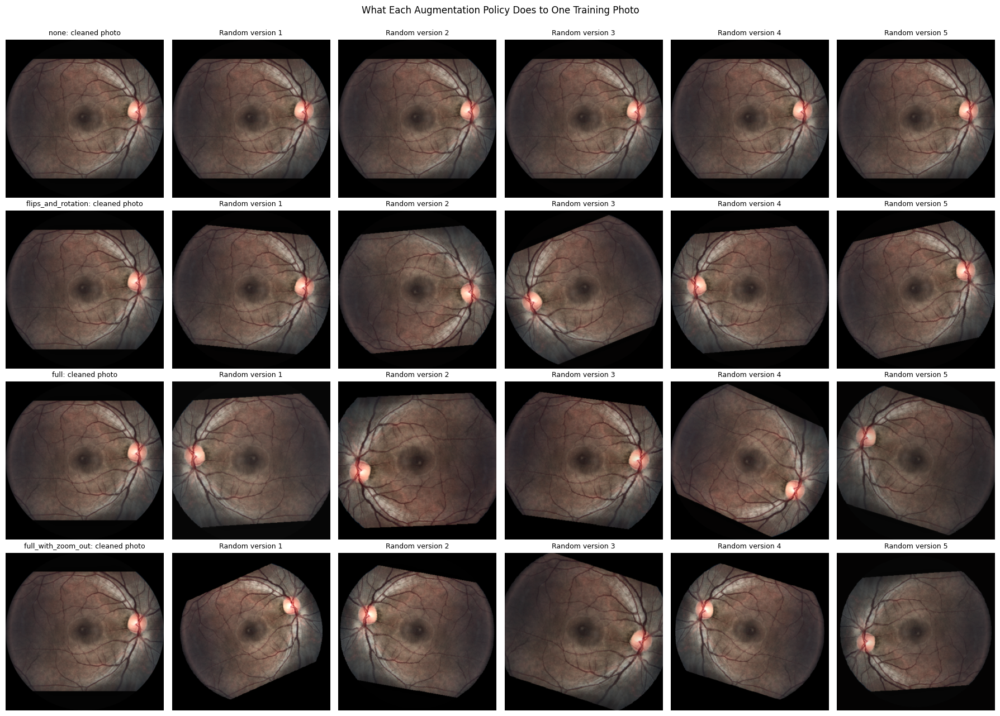

  figure saved: figures/05_augmentation_policies/augmentation_policies_preview.png
Cell 27 finished: augmentation preview saved for all four policies.


In [27]:
# Cell 27: show five random training versions of the same photo under each policy
number_of_augmented_previews = 5
normalisation_mean_tensor = torch.tensor(imagenet_normalisation_mean).view(3, 1, 1)
normalisation_std_tensor = torch.tensor(imagenet_normalisation_std).view(3, 1, 1)
figure_object, axis_grid = plt.subplots(len(augmentation_policy_names), number_of_augmented_previews + 1, figsize=(18, 3.2 * len(augmentation_policy_names)))
torch.manual_seed(RANDOM_SEED)
for row_index, policy_name in enumerate(augmentation_policy_names):
    policy_transform = build_training_transform(policy_name)
    axis_grid[row_index, 0].imshow(test_photo_for_augmentation)
    axis_grid[row_index, 0].set_title(f"{policy_name}: cleaned photo", fontsize=9)
    for preview_index in range(number_of_augmented_previews):
        displayable_image = (policy_transform(test_photo_for_augmentation) * normalisation_std_tensor + normalisation_mean_tensor).permute(1, 2, 0).clamp(0, 1).numpy()
        axis_grid[row_index, preview_index + 1].imshow(displayable_image)
        axis_grid[row_index, preview_index + 1].set_title(f"Random version {preview_index + 1}", fontsize=9)
    for current_axis in axis_grid[row_index]:
        current_axis.axis("off")
plt.suptitle("What Each Augmentation Policy Does to One Training Photo", y=1.0)
save_current_figure("05_augmentation_policies", "augmentation_policies_preview.png")

print("Cell 27 finished: augmentation preview saved for all four policies.")

## 7. Feeding Photos to the Model
A **Dataset** reads one cleaned photo and its grade. A **DataLoader** groups them into batches of 16. Both the preprocessing method and the augmentation policy are settings, so every experiment reuses the same code with only those settings changed.

In [28]:
# Cell 28: define how one photo and its grade are read, cleaned and turned into numbers
class DiabeticRetinopathyFundusImageDataset(Dataset):
    def __init__(self, labels_dataframe, target_image_size, image_transform, preprocessing_method):
        self.labels_dataframe = labels_dataframe.reset_index(drop=True)
        self.target_image_size = target_image_size
        self.image_transform = image_transform
        self.preprocessing_method = preprocessing_method

    def __len__(self):
        return len(self.labels_dataframe)

    def __getitem__(self, item_index):
        row = self.labels_dataframe.iloc[item_index]
        preprocessed_image_array = preprocess_fundus_image(build_image_path_from_id(row["id_code"]), self.target_image_size, self.preprocessing_method)
        return self.image_transform(preprocessed_image_array), torch.tensor(row["diagnosis"], dtype=torch.long)


print("Cell 28 finished: dataset class ready.")

Cell 28 finished: dataset class ready.


In [29]:
# Cell 29: build training, validation and test loaders for any method and policy, then pull one real batch through as a check
def build_data_loaders(preprocessing_method, augmentation_policy):
    split_settings = {
        "train": (train_split_dataframe, build_training_transform(augmentation_policy), True),
        "validation": (validation_split_dataframe, evaluation_time_image_transform, False),
        "test": (test_split_dataframe, evaluation_time_image_transform, False),
    }
    return {
        split_name: DataLoader(
            DiabeticRetinopathyFundusImageDataset(split_dataframe, project_configuration["target_image_size"], image_transform, preprocessing_method),
            batch_size=project_configuration["batch_size"], shuffle=shuffle_each_epoch,
            num_workers=project_configuration["number_of_data_loader_workers"], pin_memory=is_gpu_available,
        )
        for split_name, (split_dataframe, image_transform, shuffle_each_epoch) in split_settings.items()
    }


sanity_check_loaders = build_data_loaders(starting_training_recipe["preprocessing_method"], starting_training_recipe["augmentation_policy"])
sanity_check_images, sanity_check_labels = next(iter(sanity_check_loaders["train"]))
expected_batch_shape = (project_configuration["batch_size"], 3, project_configuration["target_image_size"], project_configuration["target_image_size"])

print("Cell 29 finished: loader builder ready and one batch checked.")
print("Batches per epoch, training:", len(sanity_check_loaders["train"]), "| validation:", len(sanity_check_loaders["validation"]), "| test:", len(sanity_check_loaders["test"]))
print("Batch image shape:", tuple(sanity_check_images.shape), "| shape check:", "PASS" if tuple(sanity_check_images.shape) == expected_batch_shape else "FAIL")

Cell 29 finished: loader builder ready and one batch checked.
Batches per epoch, training: 161 | validation: 35 | test: 35
Batch image shape: (16, 3, 384, 384) | shape check: PASS


## 8. Models, Freezing and the Training Engine
**Transfer learning** starts from a model that already learned edges, shapes and textures from over a million everyday photos (ImageNet), then teaches it to grade eyes. Only the last layer is swapped so it gives 5 grades.

Three models are used in the final stage:
- **EfficientNet-B3:** accurate for its size and widely used for eye photos (Bhimavarapu & Battineni, 2022; Acharya et al., 2023).
- **EfficientNet-B0:** a smaller, faster version. It also runs every experiment, because it trains fastest.
- **ResNet50:** built differently, with shortcut connections, so it tends to make different mistakes, which is what makes combining the three worthwhile.

**Freezing** means locking layers so they do not change during training. The freezing experiment tests four strategies:

| Strategy | What learns | Idea |
|---|---|---|
| head_only | Only the new last layer | Safest against overfitting, but the model cannot adapt its features to eyes |
| two_phase_partial_unfreeze | Last layer first, then the last half of the model too | Early layers keep general edge detectors, later layers adapt to eyes |
| two_phase_full_unfreeze | Last layer first, then everything | The usual transfer learning recipe, and the starting point for the experiments |
| full_fine_tune | Everything from the start | Fastest to adapt, but the random new last layer can damage the pretrained weights early on |

In [30]:
# Cell 30: compare how big the three pretrained models are before anything is changed
architecture_names_to_compare = ["efficientnet_b3", "efficientnet_b0", "resnet50"]
pretrained_model_builders = {
    "efficientnet_b3": lambda: efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1),
    "efficientnet_b0": lambda: efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1),
    "resnet50": lambda: resnet50(weights=ResNet50_Weights.IMAGENET1K_V2),
}
parameter_count_dataframe = pd.DataFrame([
    {"architecture": architecture_name, "total_parameters_with_imagenet_head": sum(parameter.numel() for parameter in pretrained_model_builders[architecture_name]().parameters())}
    for architecture_name in architecture_names_to_compare
])
save_results_table(parameter_count_dataframe, "06_models_and_freezing", "parameter_counts_before_changes.csv")

print("Cell 30 finished: model sizes compared (original ImageNet versions, 1000 outputs).")
print(parameter_count_dataframe.to_string(index=False))

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 190MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s] 


  table saved: results/06_models_and_freezing/parameter_counts_before_changes.csv
Cell 30 finished: model sizes compared (original ImageNet versions, 1000 outputs).
   architecture  total_parameters_with_imagenet_head
efficientnet_b3                             12233232
efficientnet_b0                              5288548
       resnet50                             25557032


In [31]:
# Cell 31: the model factory, plus the helpers that freeze or unfreeze parts of any model
def build_transfer_learning_model(architecture_name, number_of_output_classes, head_dropout=None):
    model = pretrained_model_builders[architecture_name]()
    if architecture_name in ("efficientnet_b3", "efficientnet_b0"):
        if head_dropout is not None:
            model.classifier[0].p = head_dropout
        model.classifier[1] = neural_network_layers.Linear(model.classifier[1].in_features, number_of_output_classes)
    elif architecture_name == "resnet50":
        model.fc = neural_network_layers.Sequential(
            neural_network_layers.Dropout(head_dropout if head_dropout is not None else 0.0),
            neural_network_layers.Linear(model.fc.in_features, number_of_output_classes),
        )
    else:
        raise ValueError(f"Unknown architecture name: {architecture_name}")
    return model


def get_backbone_blocks(model, architecture_name):
    if architecture_name == "resnet50":
        return [model.conv1, model.bn1, model.layer1, model.layer2, model.layer3, model.layer4]
    return list(model.features.children())


def get_classifier_head(model, architecture_name):
    return model.fc if architecture_name == "resnet50" else model.classifier


def set_trainable_part(model, architecture_name, trainable_part):
    for parameter in model.parameters():
        parameter.requires_grad = trainable_part == "everything"
    if trainable_part != "everything":
        for parameter in get_classifier_head(model, architecture_name).parameters():
            parameter.requires_grad = True
    if trainable_part == "last_half":
        backbone_blocks = get_backbone_blocks(model, architecture_name)
        for backbone_block in backbone_blocks[len(backbone_blocks) // 2:]:
            for parameter in backbone_block.parameters():
                parameter.requires_grad = True
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


print("Cell 31 finished: model factory and freezing helpers ready.")
print("Trainable parts: head_only, last_half (the head plus the last half of the backbone), everything.")

Cell 31 finished: model factory and freezing helpers ready.
Trainable parts: head_only, last_half (the head plus the last half of the backbone), everything.


In [32]:
# Cell 32: SMOKE TESTS, check every model's output, pretrained weights, ability to learn, and that freezing really freezes
probe_batch_images, probe_batch_labels = sanity_check_images[:8], sanity_check_labels[:8]
model_smoke_test_rows = []
freezing_rows = []
for architecture_name in architecture_names_to_compare:
    probe_model = build_transfer_learning_model(architecture_name, project_configuration["number_of_dr_classes"]).to(compute_device)
    probe_model.eval()
    with torch.no_grad():
        output_shape_passed = tuple(probe_model(probe_batch_images.to(compute_device)).shape) == (len(probe_batch_images), project_configuration["number_of_dr_classes"])
    first_backbone_parameter = next(parameter for name, parameter in probe_model.named_parameters() if not name.startswith(("fc", "classifier")))
    pretrained_weights_passed = bool(first_backbone_parameter.std().item() > 1e-6)

    total_parameters = sum(parameter.numel() for parameter in probe_model.parameters())
    head_parameters = sum(parameter.numel() for parameter in get_classifier_head(probe_model, architecture_name).parameters())
    trainable_counts = {part: set_trainable_part(probe_model, architecture_name, part) for part in ["head_only", "last_half", "everything"]}
    freezing_passed = trainable_counts["head_only"] == head_parameters and head_parameters < trainable_counts["last_half"] < total_parameters and trainable_counts["everything"] == total_parameters
    for part, trainable_count in trainable_counts.items():
        freezing_rows.append({"architecture": architecture_name, "trainable_part": part, "trainable_parameters": trainable_count,
                              "percent_of_model": round(trainable_count / total_parameters * 100, 2)})

    probe_model.train()
    learning_optimizer = optimizers.Adam(probe_model.parameters(), lr=1e-3)
    learning_loss_function = neural_network_layers.CrossEntropyLoss()
    loss_values = []
    for _ in range(25):
        learning_optimizer.zero_grad()
        step_loss = learning_loss_function(probe_model(probe_batch_images.to(compute_device)), probe_batch_labels.to(compute_device))
        step_loss.backward()
        learning_optimizer.step()
        loss_values.append(step_loss.item())
    loss_reduction_fraction = (loss_values[0] - loss_values[-1]) / loss_values[0]
    model_smoke_test_rows.append({
        "architecture": architecture_name,
        "output_shape_test": "PASS" if output_shape_passed else "FAIL",
        "pretrained_weight_test": "PASS" if pretrained_weights_passed else "FAIL",
        "freezing_test": "PASS" if freezing_passed else "FAIL",
        "single_batch_learning_test": "PASS" if loss_reduction_fraction > 0.5 else "FAIL",
        "loss_reduction_percent": round(loss_reduction_fraction * 100, 1),
    })
    del probe_model, learning_optimizer
    if is_gpu_available:
        torch.cuda.empty_cache()

model_smoke_test_dataframe = pd.DataFrame(model_smoke_test_rows)
freezing_dataframe = pd.DataFrame(freezing_rows)
save_results_table(model_smoke_test_dataframe, "06_models_and_freezing", "model_smoke_tests.csv")
save_results_table(freezing_dataframe, "06_models_and_freezing", "trainable_parameters_per_freezing_option.csv")
test_columns = ["output_shape_test", "pretrained_weight_test", "freezing_test", "single_batch_learning_test"]
all_model_smoke_tests_passed = bool((model_smoke_test_dataframe[test_columns] == "PASS").all().all())

print("Cell 32 finished: model smoke tests complete.")
print(model_smoke_test_dataframe.to_string(index=False))
print()
print("How much of each model learns under each freezing option:")
print(freezing_dataframe.to_string(index=False))
print("All model checks passed, safe to start training." if all_model_smoke_tests_passed else "At least one model check failed. Stop and fix it before training.")

  table saved: results/06_models_and_freezing/model_smoke_tests.csv
  table saved: results/06_models_and_freezing/trainable_parameters_per_freezing_option.csv
Cell 32 finished: model smoke tests complete.
   architecture output_shape_test pretrained_weight_test freezing_test single_batch_learning_test  loss_reduction_percent
efficientnet_b3              PASS                   PASS          PASS                       PASS                   100.0
efficientnet_b0              PASS                   PASS          PASS                       PASS                   100.0
       resnet50              PASS                   PASS          PASS                       PASS                   100.0

How much of each model learns under each freezing option:
   architecture trainable_part  trainable_parameters  percent_of_model
efficientnet_b3      head_only                  7685              0.07
efficientnet_b3      last_half              10540223             98.47
efficientnet_b3     everything     

In [33]:
# Cell 33: the loss function builder and the helper that trains for one epoch and tracks training QWK
def build_loss_function(training_recipe):
    return neural_network_layers.CrossEntropyLoss(
        weight=class_weights_tensor if training_recipe["use_class_weights"] else None, label_smoothing=training_recipe["label_smoothing"],
    )


def run_one_training_epoch(model, data_loader, optimizer, loss_function, device):
    model.train()
    running_loss_total = 0.0
    all_true_labels = []
    all_predicted_labels = []
    for batch_images, batch_labels in data_loader:
        batch_images = batch_images.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        predicted_logits = model(batch_images)
        batch_loss = loss_function(predicted_logits, batch_labels)
        batch_loss.backward()
        optimizer.step()
        running_loss_total += batch_loss.item() * batch_images.size(0)
        all_true_labels.extend(batch_labels.cpu().numpy().tolist())
        all_predicted_labels.extend(predicted_logits.argmax(dim=1).cpu().numpy().tolist())
    return (
        running_loss_total / len(all_true_labels),
        accuracy_score(all_true_labels, all_predicted_labels),
        cohen_kappa_score(all_true_labels, all_predicted_labels, weights="quadratic"),
    )


print("Cell 33 finished: loss builder and one-epoch helper ready.")
print("Training QWK is measured on the augmented batches as the model trains, so it costs no extra time.")

Cell 33 finished: loss builder and one-epoch helper ready.
Training QWK is measured on the augmented batches as the model trains, so it costs no extra time.


In [34]:
# Cell 34: the helper that scores a model on validation or test photos without changing it
def run_evaluation_pass(model, data_loader, loss_function, device):
    model.eval()
    running_loss_total = 0.0
    all_true_labels = []
    all_predicted_labels = []
    all_predicted_probabilities = []
    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(device, non_blocking=True)
            batch_labels = batch_labels.to(device, non_blocking=True)
            predicted_logits = model(batch_images)
            running_loss_total += loss_function(predicted_logits, batch_labels).item() * batch_images.size(0)
            all_true_labels.extend(batch_labels.cpu().numpy().tolist())
            all_predicted_labels.extend(predicted_logits.argmax(dim=1).cpu().numpy().tolist())
            all_predicted_probabilities.extend(torch.softmax(predicted_logits, dim=1).cpu().numpy().tolist())
    return (
        running_loss_total / len(all_true_labels),
        accuracy_score(all_true_labels, all_predicted_labels),
        cohen_kappa_score(all_true_labels, all_predicted_labels, weights="quadratic"),
        np.array(all_true_labels), np.array(all_predicted_labels), np.array(all_predicted_probabilities),
    )


print("Cell 34 finished: evaluation helper ready. It also returns the probability of every grade, which the ensemble needs.")

Cell 34 finished: evaluation helper ready. It also returns the probability of every grade, which the ensemble needs.


In [35]:
# Cell 35: early stopping on validation QWK, best-checkpoint saving, and a helper that records each epoch
class EarlyStoppingOnValidationQWK:
    def __init__(self, patience, checkpoint_file_path):
        self.patience = patience
        self.checkpoint_file_path = checkpoint_file_path
        self.best_validation_qwk_so_far = -1.0
        self.epochs_since_last_improvement = 0
        self.should_stop_training = False

    def reset_patience(self):
        self.epochs_since_last_improvement = 0
        self.should_stop_training = False

    def check_after_epoch(self, current_validation_qwk, model):
        if current_validation_qwk > self.best_validation_qwk_so_far:
            self.best_validation_qwk_so_far = current_validation_qwk
            self.epochs_since_last_improvement = 0
            torch.save(model.state_dict(), self.checkpoint_file_path)
            return True
        self.epochs_since_last_improvement += 1
        if self.epochs_since_last_improvement >= self.patience:
            self.should_stop_training = True
        return False


history_column_names = ["epoch", "phase", "learning_rate", "train_loss", "train_accuracy", "train_qwk", "val_loss", "val_accuracy", "val_qwk"]


def create_empty_history():
    return {column_name: [] for column_name in history_column_names}


print("Cell 35 finished: early stopping, checkpoint saving and history recording ready.")

Cell 35 finished: early stopping, checkpoint saving and history recording ready.


In [36]:
# Cell 36: run one training phase for a set number of epochs, with an optional learning rate schedule and early stopping
def run_training_phase(model, data_loaders, loss_function, optimizer, learning_rate_scheduler, number_of_epochs, first_epoch_number,
                       phase_name, early_stopping_tracker, history_records, run_label, allow_early_stop, print_every_epoch):
    for epoch_offset in range(number_of_epochs):
        epoch_number = first_epoch_number + epoch_offset
        current_learning_rate = optimizer.param_groups[0]["lr"]
        train_loss, train_accuracy, train_qwk = run_one_training_epoch(model, data_loaders["train"], optimizer, loss_function, compute_device)
        val_loss, val_accuracy, val_qwk, _, _, _ = run_evaluation_pass(model, data_loaders["validation"], loss_function, compute_device)
        if isinstance(learning_rate_scheduler, optimizers.lr_scheduler.ReduceLROnPlateau):
            learning_rate_scheduler.step(val_qwk)
        elif learning_rate_scheduler is not None:
            learning_rate_scheduler.step()
        improved = early_stopping_tracker.check_after_epoch(val_qwk, model)
        for column_name, column_value in zip(history_column_names, [epoch_number, phase_name, current_learning_rate, train_loss, train_accuracy, train_qwk, val_loss, val_accuracy, val_qwk]):
            history_records[column_name].append(column_value)
        if print_every_epoch:
            print(f"[{run_label}][{phase_name}][epoch {epoch_number}] lr={current_learning_rate:.1e} "
                  f"train loss={train_loss:.4f} acc={train_accuracy:.4f} qwk={train_qwk:.4f} | "
                  f"val loss={val_loss:.4f} acc={val_accuracy:.4f} qwk={val_qwk:.4f} {'(new best, saved)' if improved else ''}")
        if allow_early_stop and early_stopping_tracker.should_stop_training:
            print(f"[{run_label}] early stopping: validation QWK has not improved for {early_stopping_tracker.patience} epochs.")
            break


print("Cell 36 finished: training phase helper ready.")

Cell 36 finished: training phase helper ready.


In [37]:
# Cell 37: one function that trains any model with any recipe, used for every experiment and every final model
screening_schedule = {
    "phase_one_epochs": project_configuration["screening_phase_one_epochs"],
    "phase_two_max_epochs": project_configuration["screening_phase_two_max_epochs"],
    "patience": project_configuration["screening_early_stopping_patience"],
}
final_schedule = {
    "phase_one_epochs": project_configuration["final_phase_one_epochs"],
    "phase_two_max_epochs": project_configuration["final_phase_two_max_epochs"],
    "patience": project_configuration["final_early_stopping_patience"],
}


def train_with_recipe(architecture_name, training_recipe, training_schedule, run_label, checkpoint_file_path, seed_value, print_every_epoch):
    set_global_random_seed(seed_value)
    run_start_time = time.time()
    data_loaders = build_data_loaders(training_recipe["preprocessing_method"], training_recipe["augmentation_policy"])
    model = build_transfer_learning_model(architecture_name, project_configuration["number_of_dr_classes"], training_recipe["head_dropout"]).to(compute_device)
    loss_function = build_loss_function(training_recipe)
    early_stopping_tracker = EarlyStoppingOnValidationQWK(training_schedule["patience"], checkpoint_file_path)
    history_records = create_empty_history()
    total_epochs = training_schedule["phase_one_epochs"] + training_schedule["phase_two_max_epochs"]
    strategy = training_recipe["transfer_strategy"]

    def make_optimizer(learning_rate):
        return optimizers.AdamW([parameter for parameter in model.parameters() if parameter.requires_grad], lr=learning_rate, weight_decay=training_recipe["weight_decay"])

    def make_scheduler(optimizer, number_of_epochs):
        if training_recipe["phase_two_schedule"] == "cosine":
            return optimizers.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(number_of_epochs, 1))
        return optimizers.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    common_arguments = dict(model=model, data_loaders=data_loaders, loss_function=loss_function, early_stopping_tracker=early_stopping_tracker,
                            history_records=history_records, run_label=run_label, print_every_epoch=print_every_epoch)
    if strategy in ("head_only", "full_fine_tune"):
        trainable_parameter_count = set_trainable_part(model, architecture_name, "head_only" if strategy == "head_only" else "everything")
        learning_rate = training_recipe["phase_one_learning_rate"] if strategy == "head_only" else training_recipe["phase_two_learning_rate"]
        optimizer = make_optimizer(learning_rate)
        run_training_phase(optimizer=optimizer, learning_rate_scheduler=make_scheduler(optimizer, total_epochs), number_of_epochs=total_epochs,
                           first_epoch_number=1, phase_name=strategy, allow_early_stop=True, **common_arguments)
    elif strategy in ("two_phase_full_unfreeze", "two_phase_partial_unfreeze"):
        set_trainable_part(model, architecture_name, "head_only")
        run_training_phase(optimizer=make_optimizer(training_recipe["phase_one_learning_rate"]), learning_rate_scheduler=None,
                           number_of_epochs=training_schedule["phase_one_epochs"], first_epoch_number=1, phase_name="phase_1_head_only",
                           allow_early_stop=False, **common_arguments)
        early_stopping_tracker.reset_patience()
        trainable_parameter_count = set_trainable_part(model, architecture_name, "everything" if strategy == "two_phase_full_unfreeze" else "last_half")
        phase_two_optimizer = make_optimizer(training_recipe["phase_two_learning_rate"])
        run_training_phase(optimizer=phase_two_optimizer, learning_rate_scheduler=make_scheduler(phase_two_optimizer, training_schedule["phase_two_max_epochs"]),
                           number_of_epochs=training_schedule["phase_two_max_epochs"], first_epoch_number=training_schedule["phase_one_epochs"] + 1,
                           phase_name="phase_2_fine_tuning", allow_early_stop=True, **common_arguments)
    else:
        raise ValueError(f"Unknown transfer strategy: {strategy}")

    history_dataframe = pd.DataFrame(history_records)
    best_row = history_dataframe.loc[history_dataframe["val_qwk"].idxmax()]
    training_result = {
        "architecture_name": architecture_name,
        "run_label": run_label,
        "seed": seed_value,
        "recipe": copy.deepcopy(training_recipe),
        "checkpoint_path": checkpoint_file_path,
        "history_dataframe": history_dataframe,
        "best_validation_qwk": float(best_row["val_qwk"]),
        "best_epoch": int(best_row["epoch"]),
        "train_qwk_at_best_epoch": float(best_row["train_qwk"]),
        "train_accuracy_at_best_epoch": float(best_row["train_accuracy"]),
        "val_accuracy_at_best_epoch": float(best_row["val_accuracy"]),
        "val_loss_at_best_epoch": float(best_row["val_loss"]),
        "epoch_with_lowest_val_loss": int(history_dataframe.loc[history_dataframe["val_loss"].idxmin(), "epoch"]),
        "epochs_trained": int(len(history_dataframe)),
        "trainable_parameters": int(trainable_parameter_count),
        "total_parameters": int(sum(parameter.numel() for parameter in model.parameters())),
        "training_duration_minutes": (time.time() - run_start_time) / 60,
    }
    del model, data_loaders
    if is_gpu_available:
        torch.cuda.empty_cache()
    return training_result


print("Cell 37 finished: recipe-driven training function ready.")
print("It supports four freezing strategies, two learning rate schedules, class weights, label smoothing, weight decay and head dropout.")
print("The seed is reset at the start of every run, so runs with the same seed start from the same point.")

Cell 37 finished: recipe-driven training function ready.
It supports four freezing strategies, two learning rate schedules, class weights, label smoothing, weight decay and head dropout.
The seed is reset at the start of every run, so runs with the same seed start from the same point.


## 9. Experiments
Each experiment changes **one** part of the recipe, keeps everything else the same, and trains EfficientNet-B0 with the short schedule. Every option runs **twice, with two different seeds**, because a difference smaller than the seed-to-seed wobble is just luck.

**How a winner is picked (fixed before any results):**
1. The option with the highest **average validation QWK** across both seeds leads.
2. If a simpler or safer option is within **0.005 QWK** of the leader, the simpler or safer option wins, because a change that does not clearly help is not worth the extra complexity.
3. The winner replaces that part of the recipe, and the next experiment starts from there.

**The test set is never used in this section.** Each run also records validation macro F1, recall per grade, and the gap between training QWK and validation QWK, which shows overfitting.

**Honest limit:** the experiments use B0 only, to fit the GPU budget. The final recipe is assumed to carry over to B3 and ResNet50. Choosing on the validation set many times can also slightly flatter validation scores, which is exactly why the test set stays locked until section 12.

In [38]:
# Cell 38: the experiment runner, which trains every option with every seed, summarises, charts and picks a winner
experiment_run_cache = {}
experiment_decisions = []
current_training_recipe = copy.deepcopy(starting_training_recipe)


def run_one_screening_experiment(training_recipe, seed_value, run_label):
    cache_key = json_module.dumps(training_recipe, sort_keys=True) + f"|seed={seed_value}"
    if cache_key in experiment_run_cache:
        print(f"  {run_label}: identical run already done in a previous experiment, reusing its result")
        return experiment_run_cache[cache_key]
    training_result = train_with_recipe(project_configuration["screening_architecture"], training_recipe, screening_schedule, run_label,
                                        experiment_checkpoint_path, seed_value, print_every_epoch=False)
    evaluation_model = build_transfer_learning_model(project_configuration["screening_architecture"], project_configuration["number_of_dr_classes"],
                                                     training_recipe["head_dropout"]).to(compute_device)
    evaluation_model.load_state_dict(torch.load(experiment_checkpoint_path, map_location=compute_device))
    validation_loader = build_data_loaders(training_recipe["preprocessing_method"], "none")["validation"]
    _, _, _, true_labels, predicted_labels, _ = run_evaluation_pass(evaluation_model, validation_loader, neural_network_layers.CrossEntropyLoss(), compute_device)
    del evaluation_model
    _, recall_per_grade, _, _ = precision_recall_fscore_support(true_labels, predicted_labels, labels=list_of_class_indices, zero_division=0)
    experiment_row = {
        "best_val_qwk": training_result["best_validation_qwk"],
        "best_epoch": training_result["best_epoch"],
        "train_qwk_at_best_epoch": training_result["train_qwk_at_best_epoch"],
        "train_minus_val_qwk_gap": training_result["train_qwk_at_best_epoch"] - training_result["best_validation_qwk"],
        "val_macro_f1": precision_recall_fscore_support(true_labels, predicted_labels, average="macro", zero_division=0)[2],
        "val_accuracy": training_result["val_accuracy_at_best_epoch"],
        "trainable_parameters": training_result["trainable_parameters"],
        "minutes": training_result["training_duration_minutes"],
        **{f"val_recall_{stage_name.lower().replace(' ', '_')}": recall_per_grade[grade] for grade, stage_name in enumerate(stage_names_in_order)},
    }
    print(f"  {run_label}: best val QWK {experiment_row['best_val_qwk']:.4f} at epoch {experiment_row['best_epoch']}, "
          f"train-val QWK gap {experiment_row['train_minus_val_qwk_gap']:+.4f}, {experiment_row['minutes']:.1f} min")
    experiment_run_cache[cache_key] = (experiment_row, training_result["history_dataframe"])
    return experiment_run_cache[cache_key]


def run_experiment_stage(stage_title, section_name, option_recipes, preference_order, preference_reason):
    run_rows = []
    first_seed_histories = {}
    for option_name, option_recipe in option_recipes.items():
        for seed_value in project_configuration["experiment_seeds"]:
            experiment_row, history_dataframe = run_one_screening_experiment(option_recipe, seed_value, f"{stage_title} | {option_name} | seed {seed_value}")
            run_rows.append({"option": option_name, "seed": seed_value, **experiment_row})
            if seed_value == project_configuration["experiment_seeds"][0]:
                first_seed_histories[option_name] = history_dataframe
    runs_dataframe = pd.DataFrame(run_rows)
    save_results_table(runs_dataframe.round(4), section_name, "all_runs.csv")

    summary_dataframe = runs_dataframe.groupby("option", sort=False).agg(
        mean_val_qwk=("best_val_qwk", "mean"), lowest_val_qwk=("best_val_qwk", "min"), highest_val_qwk=("best_val_qwk", "max"),
        mean_val_macro_f1=("val_macro_f1", "mean"), mean_val_accuracy=("val_accuracy", "mean"),
        mean_train_minus_val_qwk_gap=("train_minus_val_qwk_gap", "mean"), mean_val_recall_severe=("val_recall_severe", "mean"),
        mean_best_epoch=("best_epoch", "mean"), trainable_parameters=("trainable_parameters", "first"), mean_minutes=("minutes", "mean"),
    )
    save_results_table(summary_dataframe.round(4).reset_index(), section_name, "summary_per_option.csv")

    leader_name = summary_dataframe["mean_val_qwk"].idxmax()
    leader_qwk = summary_dataframe.loc[leader_name, "mean_val_qwk"]
    winner_name = leader_name
    for preferred_option in preference_order:
        if summary_dataframe.loc[preferred_option, "mean_val_qwk"] >= leader_qwk - project_configuration["tie_margin_qwk"]:
            winner_name = preferred_option
            break
    if winner_name == leader_name:
        decision_reason = f"{winner_name} had the highest average validation QWK ({leader_qwk:.4f})."
    else:
        decision_reason = (f"{leader_name} led narrowly ({leader_qwk:.4f}), but {winner_name} was within {project_configuration['tie_margin_qwk']} "
                           f"({summary_dataframe.loc[winner_name, 'mean_val_qwk']:.4f}), so it wins because {preference_reason}.")

    figure_object, axis_array = plt.subplots(1, 3, figsize=(20, 5))
    option_positions = np.arange(len(summary_dataframe))
    bar_colours = ["crimson" if option_name == winner_name else "steelblue" for option_name in summary_dataframe.index]
    axis_array[0].bar(option_positions, summary_dataframe["mean_val_qwk"], color=bar_colours, alpha=0.8)
    for option_index, option_name in enumerate(summary_dataframe.index):
        seed_values = runs_dataframe.loc[runs_dataframe["option"] == option_name, "best_val_qwk"]
        axis_array[0].scatter([option_index] * len(seed_values), seed_values, color="black", zorder=5, s=18)
        axis_array[0].text(option_index, summary_dataframe.loc[option_name, "mean_val_qwk"] + 0.003, f"{summary_dataframe.loc[option_name, 'mean_val_qwk']:.3f}", ha="center", fontsize=8)
    lowest_value = runs_dataframe["best_val_qwk"].min()
    axis_array[0].set_ylim(max(0, lowest_value - 0.05), min(1, runs_dataframe["best_val_qwk"].max() + 0.03))
    axis_array[0].set_xticks(option_positions)
    axis_array[0].set_xticklabels(summary_dataframe.index, rotation=15, fontsize=8)
    axis_array[0].set_title("Best Validation QWK (bar = average, dots = each seed, red = winner)")
    axis_array[0].set_ylabel("Validation QWK")
    for option_name, history_dataframe in first_seed_histories.items():
        axis_array[1].plot(history_dataframe["epoch"], history_dataframe["val_qwk"], marker="o", markersize=3, label=option_name)
    axis_array[1].set_title(f"Validation QWK per Epoch (seed {project_configuration['experiment_seeds'][0]})")
    axis_array[1].set_xlabel("Epoch")
    axis_array[1].set_ylabel("Validation QWK")
    axis_array[1].legend(fontsize=8)
    axis_array[2].bar(option_positions, summary_dataframe["mean_train_minus_val_qwk_gap"], color=bar_colours, alpha=0.8)
    axis_array[2].set_xticks(option_positions)
    axis_array[2].set_xticklabels(summary_dataframe.index, rotation=15, fontsize=8)
    axis_array[2].set_title("Overfitting Gap: Training QWK minus Validation QWK (lower is better)")
    axis_array[2].set_ylabel("QWK gap")
    plt.suptitle(stage_title, y=1.02)
    save_current_figure(section_name, "experiment_comparison.png")

    stage_decision = {
        "stage": stage_title,
        "options_tested": list(option_recipes.keys()),
        "seeds": project_configuration["experiment_seeds"],
        "leader_by_mean_val_qwk": leader_name,
        "winner": winner_name,
        "winner_mean_val_qwk": round(float(summary_dataframe.loc[winner_name, "mean_val_qwk"]), 4),
        "reason": decision_reason,
        "summary": summary_dataframe.round(4).reset_index().to_dict(orient="records"),
    }
    save_results_json(stage_decision, section_name, "decision.json")
    experiment_decisions.append(stage_decision)
    print()
    print(summary_dataframe[["mean_val_qwk", "lowest_val_qwk", "highest_val_qwk", "mean_val_macro_f1", "mean_train_minus_val_qwk_gap", "mean_val_recall_severe"]].round(4).to_string())
    print("Decision:", decision_reason)
    return winner_name, summary_dataframe


print("Cell 38 finished: experiment runner ready.")
print(f"Each option runs with seeds {project_configuration['experiment_seeds']} on {project_configuration['screening_architecture']}, "
      f"with ties decided by a margin of {project_configuration['tie_margin_qwk']} QWK.")

Cell 38 finished: experiment runner ready.
Each option runs with seeds [42, 7] on efficientnet_b0, with ties decided by a margin of 0.005 QWK.


### Experiment 1: Preprocessing method
Resize only (baseline), CLAHE and Ben Graham, with everything else unchanged. On a tie, the simpler method wins: resize only first, then CLAHE (one step, keeps natural colours, which makes Grad-CAM easier for clinicians to read), then Ben Graham.

[Experiment 1: Preprocessing Method | resize_only | seed 42] early stopping: validation QWK has not improved for 3 epochs.
  Experiment 1: Preprocessing Method | resize_only | seed 42: best val QWK 0.8630 at epoch 6, train-val QWK gap +0.0235, 5.0 min
[Experiment 1: Preprocessing Method | resize_only | seed 7] early stopping: validation QWK has not improved for 3 epochs.
  Experiment 1: Preprocessing Method | resize_only | seed 7: best val QWK 0.8709 at epoch 8, train-val QWK gap +0.0374, 6.3 min
[Experiment 1: Preprocessing Method | clahe | seed 42] early stopping: validation QWK has not improved for 3 epochs.
  Experiment 1: Preprocessing Method | clahe | seed 42: best val QWK 0.8612 at epoch 5, train-val QWK gap +0.0122, 4.4 min
[Experiment 1: Preprocessing Method | clahe | seed 7] early stopping: validation QWK has not improved for 3 epochs.
  Experiment 1: Preprocessing Method | clahe | seed 7: best val QWK 0.8871 at epoch 8, train-val QWK gap +0.0225, 6.3 min
[Experiment 1: Prepr

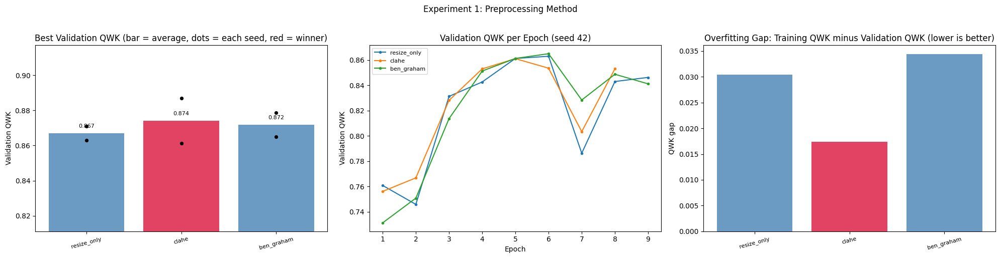

  figure saved: figures/07_experiment_preprocessing/experiment_comparison.png
  summary saved: results/07_experiment_preprocessing/decision.json

             mean_val_qwk  lowest_val_qwk  highest_val_qwk  mean_val_macro_f1  mean_train_minus_val_qwk_gap  mean_val_recall_severe
option                                                                                                                             
resize_only        0.8670          0.8630           0.8709             0.6579                        0.0305                  0.6379
clahe              0.8741          0.8612           0.8871             0.6616                        0.0174                  0.6897
ben_graham         0.8719          0.8651           0.8787             0.6464                        0.0344                  0.5862
Decision: clahe had the highest average validation QWK (0.8741).
Cell 39 finished: preprocessing method set to clahe.


In [39]:
# Cell 39: EXPERIMENT 1, which preprocessing method gives the best validation QWK?
preprocessing_options = {method_name: {**current_training_recipe, "preprocessing_method": method_name} for method_name in preprocessing_method_names}
preprocessing_winner, preprocessing_summary = run_experiment_stage(
    "Experiment 1: Preprocessing Method", "07_experiment_preprocessing", preprocessing_options,
    preference_order=["resize_only", "clahe", "ben_graham"], preference_reason="it is the simpler preprocessing",
)
current_training_recipe["preprocessing_method"] = preprocessing_winner
print(f"Cell 39 finished: preprocessing method set to {preprocessing_winner}.")

### Experiment 2: Augmentation
Is augmentation needed, and how much? On a tie the lighter policy wins, because it changes the photos less.

[Experiment 2: Augmentation Policy | none | seed 42] early stopping: validation QWK has not improved for 3 epochs.
  Experiment 2: Augmentation Policy | none | seed 42: best val QWK 0.8554 at epoch 4, train-val QWK gap +0.0352, 3.6 min
[Experiment 2: Augmentation Policy | none | seed 7] early stopping: validation QWK has not improved for 3 epochs.
  Experiment 2: Augmentation Policy | none | seed 7: best val QWK 0.8673 at epoch 9, train-val QWK gap +0.1110, 6.8 min
  Experiment 2: Augmentation Policy | flips_and_rotation | seed 42: best val QWK 0.8832 at epoch 11, train-val QWK gap +0.0501, 6.9 min
[Experiment 2: Augmentation Policy | flips_and_rotation | seed 7] early stopping: validation QWK has not improved for 3 epochs.
  Experiment 2: Augmentation Policy | flips_and_rotation | seed 7: best val QWK 0.8604 at epoch 4, train-val QWK gap -0.0020, 3.6 min
  Experiment 2: Augmentation Policy | full | seed 42: identical run already done in a previous experiment, reusing its result
  Expe

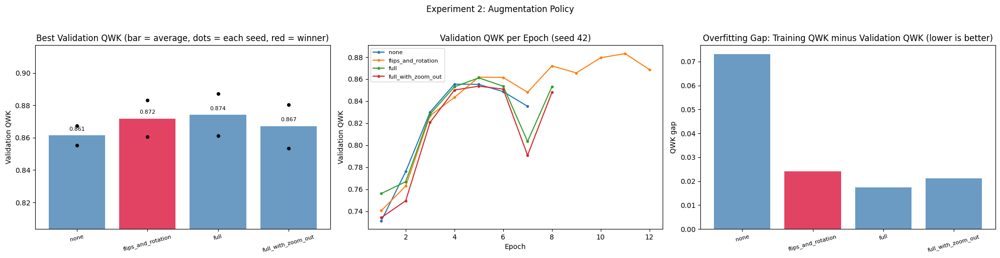

  figure saved: figures/08_experiment_augmentation/experiment_comparison.png
  summary saved: results/08_experiment_augmentation/decision.json

                    mean_val_qwk  lowest_val_qwk  highest_val_qwk  mean_val_macro_f1  mean_train_minus_val_qwk_gap  mean_val_recall_severe
option                                                                                                                                    
none                      0.8614          0.8554           0.8673             0.6591                        0.0731                  0.4828
flips_and_rotation        0.8718          0.8604           0.8832             0.6389                        0.0240                  0.6034
full                      0.8741          0.8612           0.8871             0.6616                        0.0174                  0.6897
full_with_zoom_out        0.8670          0.8536           0.8804             0.6398                        0.0213                  0.5862
Decision: full led nar

In [40]:
# Cell 40: EXPERIMENT 2, is augmentation needed, and which policy gives the best validation QWK?
augmentation_options = {policy_name: {**current_training_recipe, "augmentation_policy": policy_name} for policy_name in augmentation_policy_names}
augmentation_winner, augmentation_summary = run_experiment_stage(
    "Experiment 2: Augmentation Policy", "08_experiment_augmentation", augmentation_options,
    preference_order=augmentation_policy_names, preference_reason="it changes the photos less",
)
current_training_recipe["augmentation_policy"] = augmentation_winner
print(f"Cell 40 finished: augmentation policy set to {augmentation_winner}.")

### Experiment 3: Class balance
Plain loss vs class-weighted loss, where mistakes on rare grades count for more. Look at Severe recall in the table as well as QWK. On a tie the plain loss wins, because it is simpler.

  Experiment 3: Class Balance | no_class_weights | seed 42: best val QWK 0.8784 at epoch 11, train-val QWK gap +0.0670, 6.8 min
  Experiment 3: Class Balance | no_class_weights | seed 7: best val QWK 0.8813 at epoch 10, train-val QWK gap +0.0510, 6.8 min
  Experiment 3: Class Balance | class_weighted_loss | seed 42: identical run already done in a previous experiment, reusing its result
  Experiment 3: Class Balance | class_weighted_loss | seed 7: identical run already done in a previous experiment, reusing its result
  table saved: results/09_experiment_class_balance/all_runs.csv
  table saved: results/09_experiment_class_balance/summary_per_option.csv


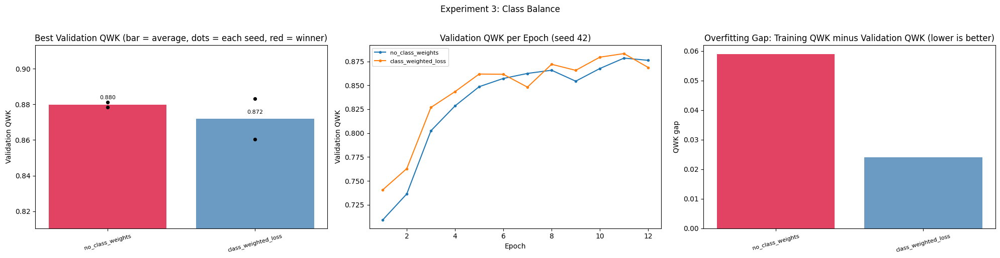

  figure saved: figures/09_experiment_class_balance/experiment_comparison.png
  summary saved: results/09_experiment_class_balance/decision.json

                     mean_val_qwk  lowest_val_qwk  highest_val_qwk  mean_val_macro_f1  mean_train_minus_val_qwk_gap  mean_val_recall_severe
option                                                                                                                                     
no_class_weights           0.8799          0.8784           0.8813             0.6511                         0.059                  0.3793
class_weighted_loss        0.8718          0.8604           0.8832             0.6389                         0.024                  0.6034
Decision: no_class_weights had the highest average validation QWK (0.8799).
Cell 41 finished: class weights off.


In [41]:
# Cell 41: EXPERIMENT 3, does weighting the loss towards rare grades help?
class_balance_options = {
    "no_class_weights": {**current_training_recipe, "use_class_weights": False},
    "class_weighted_loss": {**current_training_recipe, "use_class_weights": True},
}
class_balance_winner, class_balance_summary = run_experiment_stage(
    "Experiment 3: Class Balance", "09_experiment_class_balance", class_balance_options,
    preference_order=["no_class_weights", "class_weighted_loss"], preference_reason="the plain loss is simpler",
)
current_training_recipe["use_class_weights"] = class_balance_winner == "class_weighted_loss"
print(f"Cell 41 finished: class weights {'on' if current_training_recipe['use_class_weights'] else 'off'}.")

### Experiment 4: Transfer learning and freezing
Which parts of the model should learn? On a tie, the option that trains fewer weights wins, because fewer changing weights means less room to overfit.

  Experiment 4: Transfer Learning and Freezing | head_only | seed 42: best val QWK 0.7992 at epoch 12, train-val QWK gap +0.0046, 2.6 min
[Experiment 4: Transfer Learning and Freezing | head_only | seed 7] early stopping: validation QWK has not improved for 3 epochs.
  Experiment 4: Transfer Learning and Freezing | head_only | seed 7: best val QWK 0.7963 at epoch 7, train-val QWK gap +0.0003, 2.2 min
  Experiment 4: Transfer Learning and Freezing | two_phase_partial_unfreeze | seed 42: best val QWK 0.8765 at epoch 11, train-val QWK gap +0.0653, 4.3 min
  Experiment 4: Transfer Learning and Freezing | two_phase_partial_unfreeze | seed 7: best val QWK 0.8743 at epoch 10, train-val QWK gap +0.0543, 4.2 min
  Experiment 4: Transfer Learning and Freezing | two_phase_full_unfreeze | seed 42: identical run already done in a previous experiment, reusing its result
  Experiment 4: Transfer Learning and Freezing | two_phase_full_unfreeze | seed 7: identical run already done in a previous experim

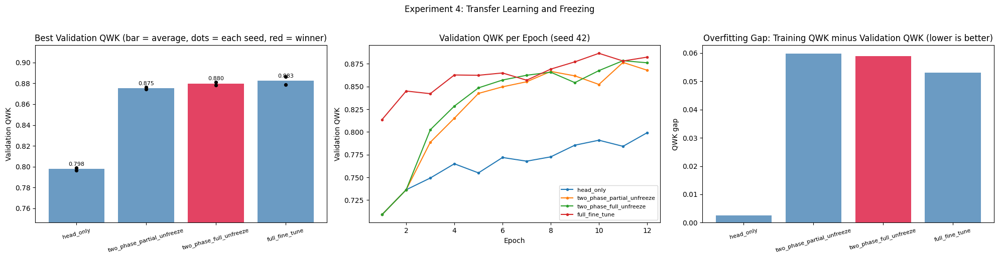

  figure saved: figures/10_experiment_transfer_learning/experiment_comparison.png
  summary saved: results/10_experiment_transfer_learning/decision.json

                            mean_val_qwk  lowest_val_qwk  highest_val_qwk  mean_val_macro_f1  mean_train_minus_val_qwk_gap  mean_val_recall_severe
option                                                                                                                                            
head_only                         0.7977          0.7963           0.7992             0.5715                        0.0025                  0.2759
two_phase_partial_unfreeze        0.8754          0.8743           0.8765             0.6580                        0.0598                  0.4655
two_phase_full_unfreeze           0.8799          0.8784           0.8813             0.6511                        0.0590                  0.3793
full_fine_tune                    0.8826          0.8786           0.8866             0.6887                   

In [42]:
# Cell 42: EXPERIMENT 4, how much of the pretrained model should be frozen?
transfer_strategy_names = ["head_only", "two_phase_partial_unfreeze", "two_phase_full_unfreeze", "full_fine_tune"]
transfer_strategy_options = {strategy_name: {**current_training_recipe, "transfer_strategy": strategy_name} for strategy_name in transfer_strategy_names}
transfer_strategy_winner, transfer_strategy_summary = run_experiment_stage(
    "Experiment 4: Transfer Learning and Freezing", "10_experiment_transfer_learning", transfer_strategy_options,
    preference_order=transfer_strategy_names, preference_reason="it trains fewer weights, leaving less room to overfit",
)
current_training_recipe["transfer_strategy"] = transfer_strategy_winner
print(f"Cell 42 finished: transfer strategy set to {transfer_strategy_winner}.")

### Experiment 5: Learning rate
The learning rate of the phase where the model adapts is tested at the default and at roughly three times lower and higher. If only the last layer learns, that is the phase 1 rate. Otherwise it is the fine-tuning rate. On a tie the default wins, because it was the starting point.

  Experiment 5: Learning Rate (phase_two_learning_rate) | lr_1e-04 | seed 42: identical run already done in a previous experiment, reusing its result
  Experiment 5: Learning Rate (phase_two_learning_rate) | lr_1e-04 | seed 7: identical run already done in a previous experiment, reusing its result
  Experiment 5: Learning Rate (phase_two_learning_rate) | lr_3e-05 | seed 42: best val QWK 0.8740 at epoch 11, train-val QWK gap +0.0397, 6.8 min
  Experiment 5: Learning Rate (phase_two_learning_rate) | lr_3e-05 | seed 7: best val QWK 0.8684 at epoch 12, train-val QWK gap +0.0462, 6.8 min
[Experiment 5: Learning Rate (phase_two_learning_rate) | lr_3e-04 | seed 42] early stopping: validation QWK has not improved for 3 epochs.
  Experiment 5: Learning Rate (phase_two_learning_rate) | lr_3e-04 | seed 42: best val QWK 0.8766 at epoch 6, train-val QWK gap +0.0301, 4.9 min
  Experiment 5: Learning Rate (phase_two_learning_rate) | lr_3e-04 | seed 7: best val QWK 0.8885 at epoch 10, train-val QWK ga

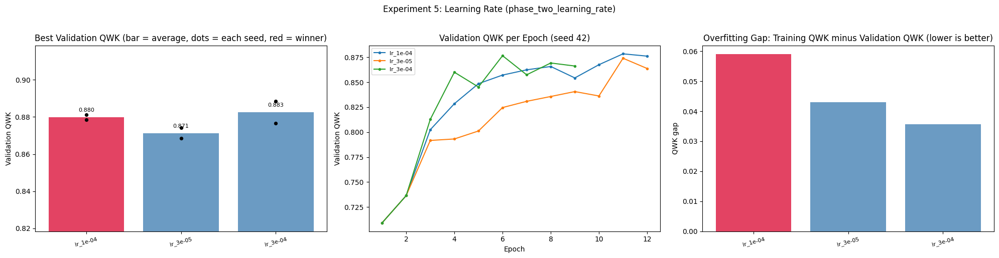

  figure saved: figures/11_experiment_learning_rate/experiment_comparison.png
  summary saved: results/11_experiment_learning_rate/decision.json

          mean_val_qwk  lowest_val_qwk  highest_val_qwk  mean_val_macro_f1  mean_train_minus_val_qwk_gap  mean_val_recall_severe
option                                                                                                                          
lr_1e-04        0.8799          0.8784           0.8813             0.6511                        0.0590                  0.3793
lr_3e-05        0.8712          0.8684           0.8740             0.6595                        0.0430                  0.3793
lr_3e-04        0.8826          0.8766           0.8885             0.6741                        0.0357                  0.5517
Decision: lr_3e-04 led narrowly (0.8826), but lr_1e-04 was within 0.005 (0.8799), so it wins because it is the default starting value.
Cell 43 finished: phase_two_learning_rate set to 1e-04.


In [43]:
# Cell 43: EXPERIMENT 5, which learning rate works best for the chosen strategy?
learning_rate_setting_name = "phase_one_learning_rate" if current_training_recipe["transfer_strategy"] == "head_only" else "phase_two_learning_rate"
default_learning_rate = current_training_recipe[learning_rate_setting_name]
learning_rate_values = [default_learning_rate, default_learning_rate / 3, default_learning_rate * 3]
learning_rate_options = {f"lr_{learning_rate_value:.0e}": {**current_training_recipe, learning_rate_setting_name: learning_rate_value} for learning_rate_value in learning_rate_values}
learning_rate_winner, learning_rate_summary = run_experiment_stage(
    f"Experiment 5: Learning Rate ({learning_rate_setting_name})", "11_experiment_learning_rate", learning_rate_options,
    preference_order=list(learning_rate_options.keys()), preference_reason="it is the default starting value",
)
current_training_recipe = copy.deepcopy(learning_rate_options[learning_rate_winner])
print(f"Cell 43 finished: {learning_rate_setting_name} set to {current_training_recipe[learning_rate_setting_name]:.0e}.")

### Experiment 6: Regularisation against overfitting
Deep models trained on a few thousand photos tend to overfit: training accuracy climbs well above validation accuracy, and validation loss starts rising while QWK is still creeping up, a sign of over-confident wrong answers. This experiment adds four standard fixes together:

- **Label smoothing (0.1):** the model is trained to be 90% sure instead of 100%, which directly targets over-confidence.
- **Weight decay (0.01, with AdamW):** keeps weights small, so the model cannot memorise individual photos.
- **Higher dropout (0.4) before the last layer:** randomly switches off features during training, so the model cannot rely on any single one.
- **Cosine learning rate schedule:** lowers the rate smoothly instead of in sudden halvings.

QWK stays the metric that picks the best version. **On a tie the regularised recipe wins**, because generalising to new photos is the goal. The chart's right panel shows the overfitting gap directly.

  Experiment 6: Regularisation | regularised | seed 42: best val QWK 0.8824 at epoch 11, train-val QWK gap +0.0527, 6.8 min
[Experiment 6: Regularisation | regularised | seed 7] early stopping: validation QWK has not improved for 3 epochs.
  Experiment 6: Regularisation | regularised | seed 7: best val QWK 0.8829 at epoch 7, train-val QWK gap +0.0294, 5.6 min
  Experiment 6: Regularisation | no_extra_regularisation | seed 42: identical run already done in a previous experiment, reusing its result
  Experiment 6: Regularisation | no_extra_regularisation | seed 7: identical run already done in a previous experiment, reusing its result
  table saved: results/12_experiment_regularisation/all_runs.csv
  table saved: results/12_experiment_regularisation/summary_per_option.csv


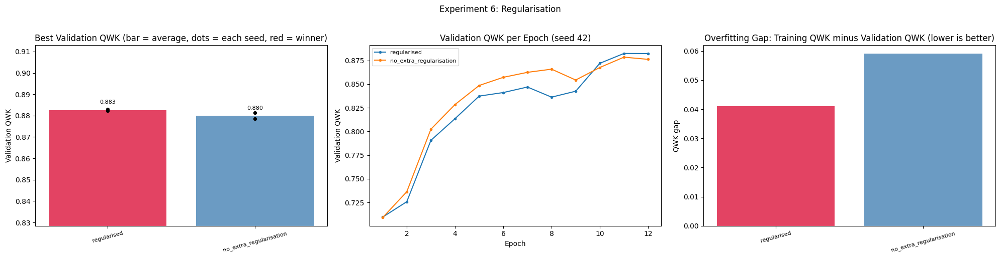

  figure saved: figures/12_experiment_regularisation/experiment_comparison.png
  summary saved: results/12_experiment_regularisation/decision.json

                         mean_val_qwk  lowest_val_qwk  highest_val_qwk  mean_val_macro_f1  mean_train_minus_val_qwk_gap  mean_val_recall_severe
option                                                                                                                                         
regularised                    0.8826          0.8824           0.8829             0.6964                         0.041                  0.4828
no_extra_regularisation        0.8799          0.8784           0.8813             0.6511                         0.059                  0.3793
Decision: regularised had the highest average validation QWK (0.8826).


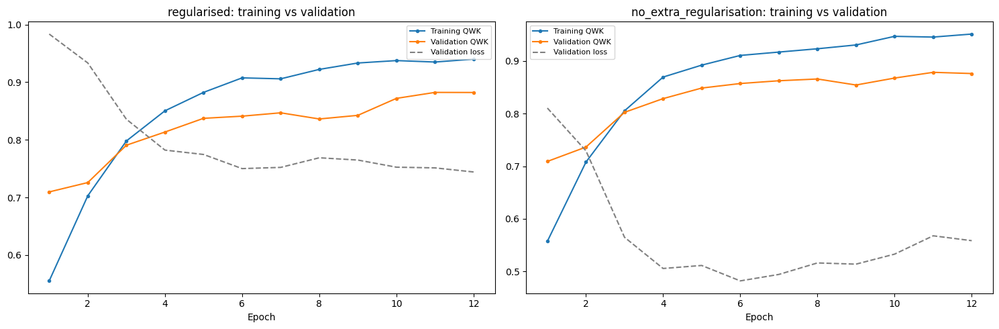

  figure saved: figures/12_experiment_regularisation/train_vs_validation_qwk_with_and_without_regularisation.png
Cell 44 finished: regularisation set to regularised.


In [44]:
# Cell 44: EXPERIMENT 6, does regularisation reduce overfitting without losing validation QWK?
regularisation_options = {
    "regularised": {**current_training_recipe, "label_smoothing": 0.1, "weight_decay": 0.01, "head_dropout": 0.4, "phase_two_schedule": "cosine"},
    "no_extra_regularisation": {**current_training_recipe},
}
regularisation_winner, regularisation_summary = run_experiment_stage(
    "Experiment 6: Regularisation", "12_experiment_regularisation", regularisation_options,
    preference_order=["regularised", "no_extra_regularisation"], preference_reason="it generalises better, with a smaller training vs validation gap",
)
current_training_recipe = copy.deepcopy(regularisation_options[regularisation_winner])

regularisation_histories = {option_name: experiment_run_cache[json_module.dumps(option_recipe, sort_keys=True) + f"|seed={project_configuration['experiment_seeds'][0]}"][1]
                            for option_name, option_recipe in regularisation_options.items()}
figure_object, axis_array = plt.subplots(1, 2, figsize=(15, 5))
for axis_index, (option_name, history_dataframe) in enumerate(regularisation_histories.items()):
    axis_array[axis_index].plot(history_dataframe["epoch"], history_dataframe["train_qwk"], marker="o", markersize=3, label="Training QWK")
    axis_array[axis_index].plot(history_dataframe["epoch"], history_dataframe["val_qwk"], marker="o", markersize=3, label="Validation QWK")
    axis_array[axis_index].plot(history_dataframe["epoch"], history_dataframe["val_loss"], linestyle="--", color="grey", label="Validation loss")
    axis_array[axis_index].set_title(f"{option_name}: training vs validation")
    axis_array[axis_index].set_xlabel("Epoch")
    axis_array[axis_index].legend(fontsize=8)
save_current_figure("12_experiment_regularisation", "train_vs_validation_qwk_with_and_without_regularisation.png")
print(f"Cell 44 finished: regularisation set to {regularisation_winner}.")

## 10. Final Configuration
Every tested choice is now fixed. The table below is the justification trail for the report: what was tested, what won and why.

  table saved: results/13_final_configuration/experiment_decisions_table.csv
  summary saved: results/13_final_configuration/final_project_configuration.json


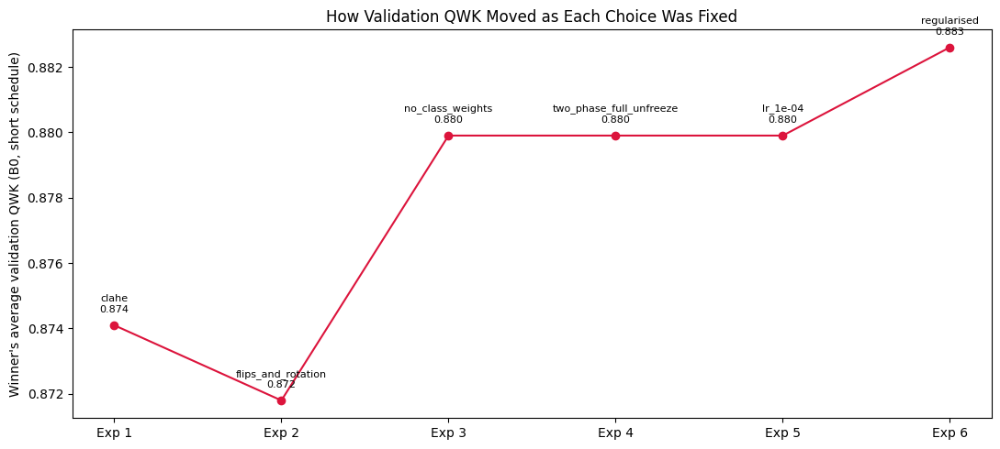

  figure saved: figures/13_final_configuration/validation_qwk_by_experiment_stage.png
Cell 45 finished: final configuration fixed and saved.
                                           experiment                  winner  winner_mean_val_qwk
                   Experiment 1: Preprocessing Method                   clahe               0.8741
                    Experiment 2: Augmentation Policy      flips_and_rotation               0.8718
                          Experiment 3: Class Balance        no_class_weights               0.8799
         Experiment 4: Transfer Learning and Freezing two_phase_full_unfreeze               0.8799
Experiment 5: Learning Rate (phase_two_learning_rate)                lr_1e-04               0.8799
                         Experiment 6: Regularisation             regularised               0.8826

Final recipe used for all three models:
{
  "preprocessing_method": "clahe",
  "augmentation_policy": "flips_and_rotation",
  "use_class_weights": false,
  "transfer

In [45]:
# Cell 45: gather every experiment decision into the final configuration and chart how validation QWK moved stage by stage
final_training_recipe = copy.deepcopy(current_training_recipe)
decision_table_dataframe = pd.DataFrame([
    {"experiment": decision["stage"], "options_tested": ", ".join(decision["options_tested"]), "winner": decision["winner"],
     "winner_mean_val_qwk": decision["winner_mean_val_qwk"], "reason": decision["reason"]}
    for decision in experiment_decisions
])
save_results_table(decision_table_dataframe, "13_final_configuration", "experiment_decisions_table.csv")
final_project_configuration = {
    "fixed_settings": project_configuration,
    "tested_and_chosen_recipe": final_training_recipe,
    "starting_recipe_before_experiments": starting_training_recipe,
    "final_training_schedule": final_schedule,
    "experiment_decisions": experiment_decisions,
}
save_results_json(final_project_configuration, "13_final_configuration", "final_project_configuration.json")

figure_object, axis_object = plt.subplots(figsize=(11, 5))
axis_object.plot(range(1, len(decision_table_dataframe) + 1), decision_table_dataframe["winner_mean_val_qwk"], marker="o", color="crimson")
for stage_index, row in decision_table_dataframe.iterrows():
    axis_object.annotate(f"{row['winner']}\n{row['winner_mean_val_qwk']:.3f}", (stage_index + 1, row["winner_mean_val_qwk"]),
                         textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
axis_object.set_xticks(range(1, len(decision_table_dataframe) + 1))
axis_object.set_xticklabels([f"Exp {number}" for number in range(1, len(decision_table_dataframe) + 1)])
axis_object.set_ylabel("Winner's average validation QWK (B0, short schedule)")
axis_object.set_title("How Validation QWK Moved as Each Choice Was Fixed")
save_current_figure("13_final_configuration", "validation_qwk_by_experiment_stage.png")

print("Cell 45 finished: final configuration fixed and saved.")
print(decision_table_dataframe[["experiment", "winner", "winner_mean_val_qwk"]].to_string(index=False))
print()
print("Final recipe used for all three models:")
print(json_module.dumps(final_training_recipe, indent=2))
print("Total experiment runs actually trained (reused runs not counted):", len(experiment_run_cache))

## 11. Final Training
All three models are trained with the final recipe and the full schedule, using seed 42. The best version of each is kept by **validation QWK**. Training QWK is plotted next to validation QWK for every model, so the overfitting gap is shown in the metric that actually matters.

In [46]:
# Cell 46: train EfficientNet-B3 with the final recipe
def build_main_checkpoint_path(architecture_name):
    return os.path.join(main_models_folder_path, f"best_{architecture_name}_by_validation_qwk.pth")


efficientnet_b3_training_result = train_with_recipe("efficientnet_b3", final_training_recipe, final_schedule, "efficientnet_b3",
                                                    build_main_checkpoint_path("efficientnet_b3"), RANDOM_SEED, print_every_epoch=True)
print(f"Cell 46 finished: EfficientNet-B3 trained in {efficientnet_b3_training_result['training_duration_minutes']:.1f} minutes, "
      f"best validation QWK {efficientnet_b3_training_result['best_validation_qwk']:.4f} at epoch {efficientnet_b3_training_result['best_epoch']}.")

[efficientnet_b3][phase_1_head_only][epoch 1] lr=1.0e-03 train loss=1.1214 acc=0.6512 qwk=0.5282 | val loss=1.0212 acc=0.7086 qwk=0.7340 (new best, saved)
[efficientnet_b3][phase_1_head_only][epoch 2] lr=1.0e-03 train loss=0.9657 acc=0.7175 qwk=0.7127 | val loss=0.9593 acc=0.7250 qwk=0.7515 (new best, saved)
[efficientnet_b3][phase_2_fine_tuning][epoch 6] lr=1.0e-04 train loss=0.8571 acc=0.7764 qwk=0.8073 | val loss=0.8177 acc=0.7687 qwk=0.8163 (new best, saved)
[efficientnet_b3][phase_2_fine_tuning][epoch 7] lr=1.0e-04 train loss=0.7737 acc=0.8158 qwk=0.8699 | val loss=0.7831 acc=0.7905 qwk=0.8591 (new best, saved)
[efficientnet_b3][phase_2_fine_tuning][epoch 8] lr=9.8e-05 train loss=0.7384 acc=0.8373 qwk=0.8906 | val loss=0.7832 acc=0.8069 qwk=0.8566 
[efficientnet_b3][phase_2_fine_tuning][epoch 9] lr=9.6e-05 train loss=0.7152 acc=0.8416 qwk=0.8970 | val loss=0.7696 acc=0.8160 qwk=0.8712 (new best, saved)
[efficientnet_b3][phase_2_fine_tuning][epoch 10] lr=9.4e-05 train loss=0.6753 a

In [47]:
# Cell 47: train EfficientNet-B0 with the final recipe
efficientnet_b0_training_result = train_with_recipe("efficientnet_b0", final_training_recipe, final_schedule, "efficientnet_b0",
                                                    build_main_checkpoint_path("efficientnet_b0"), RANDOM_SEED, print_every_epoch=True)
print(f"Cell 47 finished: EfficientNet-B0 trained in {efficientnet_b0_training_result['training_duration_minutes']:.1f} minutes, "
      f"best validation QWK {efficientnet_b0_training_result['best_validation_qwk']:.4f} at epoch {efficientnet_b0_training_result['best_epoch']}.")

[efficientnet_b0][phase_1_head_only][epoch 1] lr=1.0e-03 train loss=1.1068 acc=0.6551 qwk=0.5551 | val loss=0.9837 acc=0.7213 qwk=0.7096 (new best, saved)
[efficientnet_b0][phase_1_head_only][epoch 2] lr=1.0e-03 train loss=0.9724 acc=0.7136 qwk=0.7028 | val loss=0.9335 acc=0.7286 qwk=0.7258 (new best, saved)
[efficientnet_b0][phase_1_head_only][epoch 3] lr=1.0e-03 train loss=0.9323 acc=0.7382 qwk=0.7420 | val loss=0.9211 acc=0.7450 qwk=0.7470 (new best, saved)
[efficientnet_b0][phase_1_head_only][epoch 4] lr=1.0e-03 train loss=0.9159 acc=0.7347 qwk=0.7508 | val loss=0.9104 acc=0.7450 qwk=0.7582 (new best, saved)
[efficientnet_b0][phase_1_head_only][epoch 5] lr=1.0e-03 train loss=0.9207 acc=0.7405 qwk=0.7444 | val loss=0.9168 acc=0.7596 qwk=0.7733 (new best, saved)
[efficientnet_b0][phase_2_fine_tuning][epoch 6] lr=1.0e-04 train loss=0.8569 acc=0.7706 qwk=0.8029 | val loss=0.8345 acc=0.7887 qwk=0.7974 (new best, saved)
[efficientnet_b0][phase_2_fine_tuning][epoch 7] lr=1.0e-04 train los

In [48]:
# Cell 48: train ResNet50 with the final recipe
resnet50_training_result = train_with_recipe("resnet50", final_training_recipe, final_schedule, "resnet50",
                                             build_main_checkpoint_path("resnet50"), RANDOM_SEED, print_every_epoch=True)
print(f"Cell 48 finished: ResNet50 trained in {resnet50_training_result['training_duration_minutes']:.1f} minutes, "
      f"best validation QWK {resnet50_training_result['best_validation_qwk']:.4f} at epoch {resnet50_training_result['best_epoch']}.")

[resnet50][phase_1_head_only][epoch 1] lr=1.0e-03 train loss=1.1064 acc=0.6621 qwk=0.5504 | val loss=1.0448 acc=0.6958 qwk=0.7021 (new best, saved)
[resnet50][phase_1_head_only][epoch 2] lr=1.0e-03 train loss=0.9584 acc=0.7195 qwk=0.7083 | val loss=0.9719 acc=0.7359 qwk=0.7041 (new best, saved)
[resnet50][phase_1_head_only][epoch 3] lr=1.0e-03 train loss=0.9132 acc=0.7452 qwk=0.7467 | val loss=0.9372 acc=0.7450 qwk=0.7449 (new best, saved)
[resnet50][phase_1_head_only][epoch 4] lr=1.0e-03 train loss=0.8848 acc=0.7577 qwk=0.7761 | val loss=0.9234 acc=0.7505 qwk=0.7619 (new best, saved)
[resnet50][phase_1_head_only][epoch 5] lr=1.0e-03 train loss=0.8731 acc=0.7702 qwk=0.7925 | val loss=0.9099 acc=0.7486 qwk=0.7608 
[resnet50][phase_2_fine_tuning][epoch 6] lr=1.0e-04 train loss=0.8155 acc=0.7983 qwk=0.8437 | val loss=0.8312 acc=0.7723 qwk=0.7882 (new best, saved)
[resnet50][phase_2_fine_tuning][epoch 7] lr=1.0e-04 train loss=0.7546 acc=0.8338 qwk=0.8902 | val loss=0.7818 acc=0.8233 qwk=0.

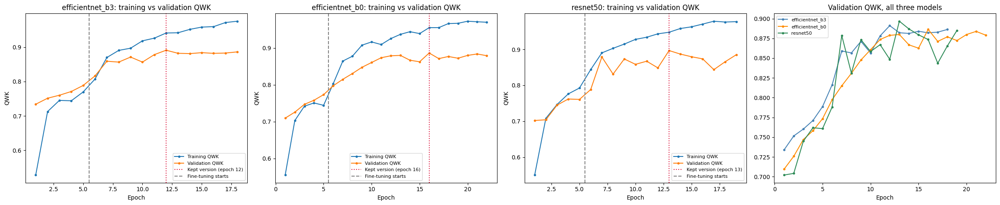

  figure saved: figures/14_final_training/train_vs_validation_qwk_per_model.png
Cell 49 finished: QWK curves saved.
Training QWK is measured on augmented photos, which are harder than clean ones, so a small gap is expected even without overfitting.


In [49]:
# Cell 49: training QWK vs validation QWK per epoch for every model, the main overfitting evidence
all_training_results = [efficientnet_b3_training_result, efficientnet_b0_training_result, resnet50_training_result]
architecture_display_colours = {"efficientnet_b3": "steelblue", "efficientnet_b0": "darkorange", "resnet50": "seagreen"}
phase_boundary_epoch_position = final_schedule["phase_one_epochs"] + 0.5
uses_two_phases = final_training_recipe["transfer_strategy"].startswith("two_phase")

figure_object, axis_array = plt.subplots(1, len(all_training_results) + 1, figsize=(24, 5))
for axis_index, training_result in enumerate(all_training_results):
    history_dataframe = training_result["history_dataframe"]
    current_axis = axis_array[axis_index]
    current_axis.plot(history_dataframe["epoch"], history_dataframe["train_qwk"], marker="o", markersize=3, label="Training QWK")
    current_axis.plot(history_dataframe["epoch"], history_dataframe["val_qwk"], marker="o", markersize=3, label="Validation QWK")
    current_axis.axvline(training_result["best_epoch"], color="crimson", linestyle=":", label=f"Kept version (epoch {training_result['best_epoch']})")
    if uses_two_phases:
        current_axis.axvline(phase_boundary_epoch_position, color="grey", linestyle="--", label="Fine-tuning starts")
    current_axis.set_title(f"{training_result['architecture_name']}: training vs validation QWK")
    current_axis.set_xlabel("Epoch")
    current_axis.set_ylabel("QWK")
    current_axis.legend(fontsize=8)
for training_result in all_training_results:
    axis_array[-1].plot(training_result["history_dataframe"]["epoch"], training_result["history_dataframe"]["val_qwk"], marker="o", markersize=3,
                        color=architecture_display_colours[training_result["architecture_name"]], label=training_result["architecture_name"])
axis_array[-1].set_title("Validation QWK, all three models")
axis_array[-1].set_xlabel("Epoch")
axis_array[-1].legend(fontsize=8)
save_current_figure("14_final_training", "train_vs_validation_qwk_per_model.png")

print("Cell 49 finished: QWK curves saved.")
print("Training QWK is measured on augmented photos, which are harder than clean ones, so a small gap is expected even without overfitting.")

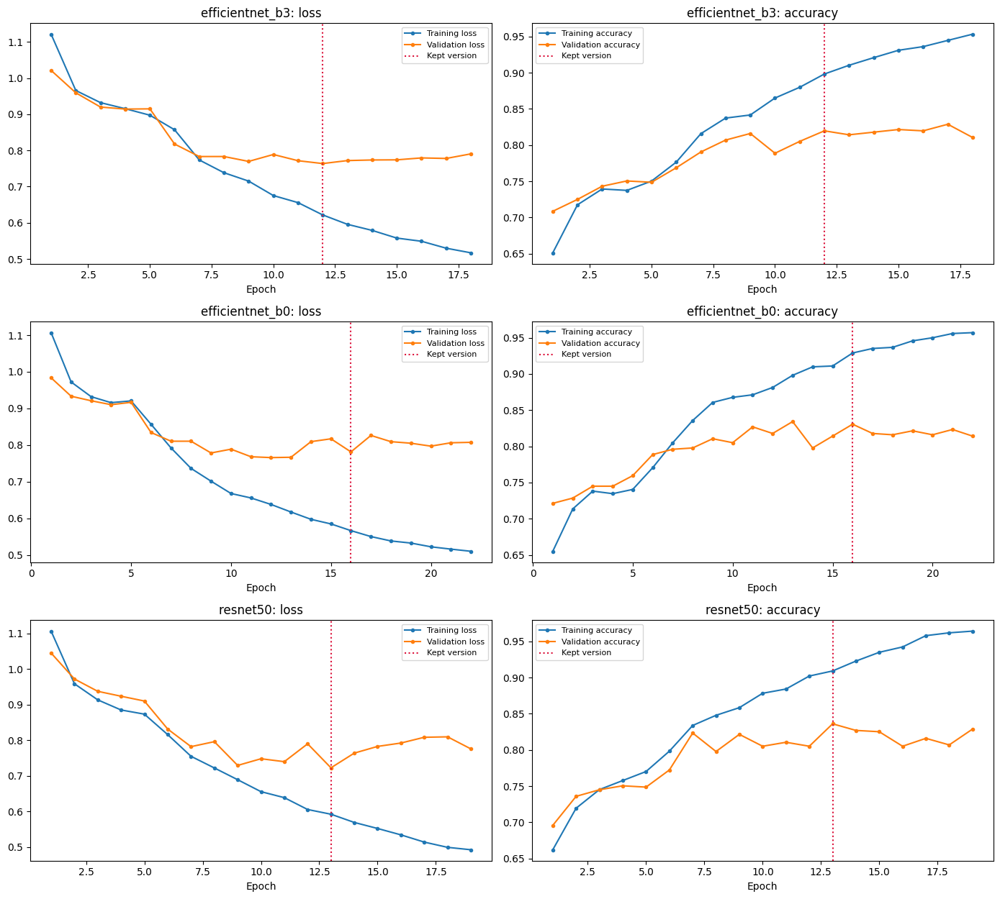

  figure saved: figures/14_final_training/train_vs_validation_loss_and_accuracy_per_model.png
  table saved: results/14_final_training/overfitting_gaps_at_kept_epoch.csv
Cell 50 finished: loss and accuracy curves and the overfitting gap table saved.
   architecture  kept_epoch  epochs_trained  train_qwk  val_qwk  qwk_gap  train_accuracy  val_accuracy  accuracy_gap  train_loss  val_loss  epoch_with_lowest_val_loss
efficientnet_b3          12              18     0.9412   0.8911   0.0501          0.8982        0.8197        0.0785      0.6217    0.7637                          12
efficientnet_b0          16              22     0.9553   0.8865   0.0688          0.9290        0.8306        0.0984      0.5669    0.7816                          12
       resnet50          13              19     0.9477   0.8967   0.0509          0.9091        0.8361        0.0730      0.5919    0.7223                          13
Compare these gaps with the no_extra_regularisation option in experiment 6 to see 

In [50]:
# Cell 50: training vs validation loss and accuracy per model, plus a table of the gaps at the kept epoch
figure_object, axis_grid = plt.subplots(len(all_training_results), 2, figsize=(14, 4.2 * len(all_training_results)), squeeze=False)
overfitting_gap_rows = []
for row_index, training_result in enumerate(all_training_results):
    history_dataframe = training_result["history_dataframe"]
    for column_index, (train_column, val_column, chart_label) in enumerate([("train_loss", "val_loss", "loss"), ("train_accuracy", "val_accuracy", "accuracy")]):
        current_axis = axis_grid[row_index, column_index]
        current_axis.plot(history_dataframe["epoch"], history_dataframe[train_column], marker="o", markersize=3, label=f"Training {chart_label}")
        current_axis.plot(history_dataframe["epoch"], history_dataframe[val_column], marker="o", markersize=3, label=f"Validation {chart_label}")
        current_axis.axvline(training_result["best_epoch"], color="crimson", linestyle=":", label="Kept version")
        current_axis.set_title(f"{training_result['architecture_name']}: {chart_label}")
        current_axis.set_xlabel("Epoch")
        current_axis.legend(fontsize=8)
    kept_row = history_dataframe[history_dataframe["epoch"] == training_result["best_epoch"]].iloc[0]
    overfitting_gap_rows.append({
        "architecture": training_result["architecture_name"],
        "kept_epoch": training_result["best_epoch"],
        "epochs_trained": training_result["epochs_trained"],
        "train_qwk": round(float(kept_row["train_qwk"]), 4),
        "val_qwk": round(float(kept_row["val_qwk"]), 4),
        "qwk_gap": round(float(kept_row["train_qwk"] - kept_row["val_qwk"]), 4),
        "train_accuracy": round(float(kept_row["train_accuracy"]), 4),
        "val_accuracy": round(float(kept_row["val_accuracy"]), 4),
        "accuracy_gap": round(float(kept_row["train_accuracy"] - kept_row["val_accuracy"]), 4),
        "train_loss": round(float(kept_row["train_loss"]), 4),
        "val_loss": round(float(kept_row["val_loss"]), 4),
        "epoch_with_lowest_val_loss": training_result["epoch_with_lowest_val_loss"],
    })
save_current_figure("14_final_training", "train_vs_validation_loss_and_accuracy_per_model.png")
overfitting_gap_dataframe = pd.DataFrame(overfitting_gap_rows)
save_results_table(overfitting_gap_dataframe, "14_final_training", "overfitting_gaps_at_kept_epoch.csv")

print("Cell 50 finished: loss and accuracy curves and the overfitting gap table saved.")
print(overfitting_gap_dataframe.to_string(index=False))
print("Compare these gaps with the no_extra_regularisation option in experiment 6 to see how much the regularisation helped.")

In [51]:
# Cell 51: save every model's epoch-by-epoch history and a size, speed and score table, and pick the best single model by validation QWK
for training_result in all_training_results:
    save_results_table(training_result["history_dataframe"], "14_final_training", f"training_history_{training_result['architecture_name']}.csv")

architecture_comparison_dataframe = pd.DataFrame([{
    "architecture": result["architecture_name"], "total_parameters": result["total_parameters"], "trainable_parameters": result["trainable_parameters"],
    "epochs_trained": result["epochs_trained"], "kept_epoch": result["best_epoch"], "best_validation_qwk": round(result["best_validation_qwk"], 4),
    "training_minutes": round(result["training_duration_minutes"], 1),
} for result in all_training_results])
save_results_table(architecture_comparison_dataframe, "14_final_training", "architecture_comparison.csv")

best_single_architecture_name = architecture_comparison_dataframe.loc[architecture_comparison_dataframe["best_validation_qwk"].idxmax(), "architecture"]

print("Cell 51 finished: histories and comparison table saved.")
print(architecture_comparison_dataframe.to_string(index=False))
print(f"Best single model, chosen on validation QWK only: {best_single_architecture_name}. The test set has still not been used.")

  table saved: results/14_final_training/training_history_efficientnet_b3.csv
  table saved: results/14_final_training/training_history_efficientnet_b0.csv
  table saved: results/14_final_training/training_history_resnet50.csv
  table saved: results/14_final_training/architecture_comparison.csv
Cell 51 finished: histories and comparison table saved.
   architecture  total_parameters  trainable_parameters  epochs_trained  kept_epoch  best_validation_qwk  training_minutes
efficientnet_b3          10703917              10703917              18          12               0.8911              19.2
efficientnet_b0           4013953               4013953              22          16               0.8865              12.0
       resnet50          23518277              23518277              19          13               0.8967              23.4
Best single model, chosen on validation QWK only: resnet50. The test set has still not been used.


In [52]:
# Cell 52: time how fast each model predicts, on the GPU in batches and on the CPU one photo at a time like the web app
final_data_loaders = build_data_loaders(final_training_recipe["preprocessing_method"], final_training_recipe["augmentation_policy"])
latency_probe_images, _ = next(iter(final_data_loaders["test"]))


def time_model_forward_passes(model, input_batch, number_of_repeats, device):
    model = model.to(device).eval()
    input_batch = input_batch.to(device)
    with torch.no_grad():
        for _ in range(2):
            model(input_batch)
        if device.type == "cuda":
            torch.cuda.synchronize()
        timing_start = time.time()
        for _ in range(number_of_repeats):
            model(input_batch)
        if device.type == "cuda":
            torch.cuda.synchronize()
    return (time.time() - timing_start) / number_of_repeats * 1000 / input_batch.shape[0]


def load_trained_model(architecture_name, device):
    model = build_transfer_learning_model(architecture_name, project_configuration["number_of_dr_classes"], final_training_recipe["head_dropout"])
    model.load_state_dict(torch.load(build_main_checkpoint_path(architecture_name), map_location="cpu"))
    return model.to(device).eval()


inference_latency_rows = []
for architecture_name in architecture_names_to_compare:
    timing_model = load_trained_model(architecture_name, torch.device("cpu"))
    inference_latency_rows.append({
        "model": architecture_name,
        "gpu_milliseconds_per_photo_in_batches_of_16": round(time_model_forward_passes(timing_model, latency_probe_images, 30, compute_device), 2) if is_gpu_available else float("nan"),
        "cpu_milliseconds_for_one_photo": round(time_model_forward_passes(timing_model, latency_probe_images[:1].clone(), 5, torch.device("cpu")), 1),
    })
    del timing_model
inference_latency_dataframe = pd.DataFrame(inference_latency_rows)
inference_latency_dataframe.loc[len(inference_latency_dataframe)] = {
    "model": "ensemble (all three)",
    "gpu_milliseconds_per_photo_in_batches_of_16": round(inference_latency_dataframe["gpu_milliseconds_per_photo_in_batches_of_16"].sum(), 2),
    "cpu_milliseconds_for_one_photo": round(inference_latency_dataframe["cpu_milliseconds_for_one_photo"].sum(), 1),
}
save_results_table(inference_latency_dataframe, "14_final_training", "inference_speed.csv")

print("Cell 52 finished: prediction speed measured.")
print(inference_latency_dataframe.to_string(index=False))

  table saved: results/14_final_training/inference_speed.csv
Cell 52 finished: prediction speed measured.
               model  gpu_milliseconds_per_photo_in_batches_of_16  cpu_milliseconds_for_one_photo
     efficientnet_b3                                         6.95                           124.5
     efficientnet_b0                                         3.33                            62.5
            resnet50                                         8.35                           180.4
ensemble (all three)                                        18.63                           367.4


## 12. Testing the Models
The test set is used **now, and only once**. Each model and the ensemble (the average of the three models' grade probabilities, called soft voting) are scored on:

- **QWK** with a 95% confidence interval from bootstrapping (re-sampling the test photos 1000 times), so the report shows how certain each number is
- **Accuracy, precision, recall and F1**, overall and per grade
- **Confusion matrices**, which show which grades get mixed up
- A **screening view**: are patients who need a specialist caught?
- **Model agreement** and **McNemar's test**, which checks whether the ensemble is really better than the best single model

In [53]:
# Cell 53: test all three models once on the held-out test photos and build the soft-voting ensemble
evaluation_loss_function = build_loss_function(final_training_recipe)
per_architecture_test_results = {}
for architecture_name in architecture_names_to_compare:
    evaluation_model = load_trained_model(architecture_name, compute_device)
    test_loss, test_accuracy, test_qwk, true_labels, predicted_labels, predicted_probabilities = run_evaluation_pass(
        evaluation_model, final_data_loaders["test"], evaluation_loss_function, compute_device)
    per_architecture_test_results[architecture_name] = {
        "test_loss": test_loss, "test_accuracy": test_accuracy, "test_qwk": test_qwk,
        "test_true_labels": true_labels, "test_predicted_labels": predicted_labels, "test_predicted_probabilities": predicted_probabilities,
    }
    del evaluation_model

ensemble_true_labels = per_architecture_test_results["efficientnet_b3"]["test_true_labels"]
assert all(np.array_equal(per_architecture_test_results[name]["test_true_labels"], ensemble_true_labels) for name in architecture_names_to_compare), \
    "The test photos came out in a different order for different models, so averaging would be wrong."
ensemble_averaged_probabilities = np.stack([per_architecture_test_results[name]["test_predicted_probabilities"] for name in architecture_names_to_compare]).mean(axis=0)
ensemble_predicted_labels = ensemble_averaged_probabilities.argmax(axis=1)
ensemble_test_accuracy = accuracy_score(ensemble_true_labels, ensemble_predicted_labels)
ensemble_test_qwk = cohen_kappa_score(ensemble_true_labels, ensemble_predicted_labels, weights="quadratic")

all_model_predictions_by_name = {
    name: (per_architecture_test_results[name]["test_true_labels"], per_architecture_test_results[name]["test_predicted_labels"], per_architecture_test_results[name]["test_predicted_probabilities"])
    for name in architecture_names_to_compare
}
all_model_predictions_by_name["ensemble (soft vote)"] = (ensemble_true_labels, ensemble_predicted_labels, ensemble_averaged_probabilities)
test_split_in_loader_order = test_split_dataframe.reset_index(drop=True)

print("Cell 53 finished: all models tested on the same", len(ensemble_true_labels), "test photos, and the ensemble built.")
for model_name, (true_labels_array, predicted_labels_array, _) in all_model_predictions_by_name.items():
    print(f"  {model_name}: accuracy {accuracy_score(true_labels_array, predicted_labels_array):.4f}, QWK {cohen_kappa_score(true_labels_array, predicted_labels_array, weights='quadratic'):.4f}")

Cell 53 finished: all models tested on the same 550 test photos, and the ensemble built.
  efficientnet_b3: accuracy 0.8055, QWK 0.8715
  efficientnet_b0: accuracy 0.8218, QWK 0.8771
  resnet50: accuracy 0.8073, QWK 0.8735
  ensemble (soft vote): accuracy 0.8418, QWK 0.8998


  table saved: results/15_evaluation/headline_metrics_with_confidence_intervals.csv


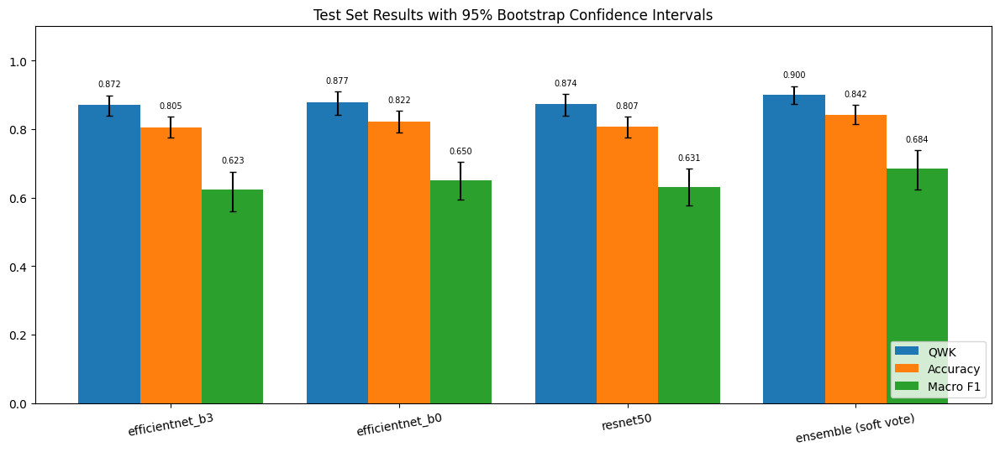

  figure saved: figures/15_evaluation/headline_metrics_with_confidence_intervals.png
Cell 54 finished: headline metrics with confidence intervals saved.
               model    qwk  qwk_ci_low  qwk_ci_high  accuracy  macro_f1  weighted_f1
     efficientnet_b3 0.8715      0.8390       0.8981    0.8055    0.6226       0.7987
     efficientnet_b0 0.8771      0.8422       0.9086    0.8218    0.6498       0.8178
            resnet50 0.8735      0.8381       0.9019    0.8073    0.6310       0.8029
ensemble (soft vote) 0.8998      0.8728       0.9253    0.8418    0.6837       0.8361
Overlapping confidence intervals mean the difference between two models may not be real on this test set.


In [54]:
# Cell 54: headline metrics for all four models, with 95% bootstrap confidence intervals for QWK, accuracy and macro F1
number_of_bootstrap_resamples = 1000
bootstrap_random_generator = np.random.default_rng(RANDOM_SEED)
bootstrap_index_sets = [bootstrap_random_generator.integers(0, len(ensemble_true_labels), len(ensemble_true_labels)) for _ in range(number_of_bootstrap_resamples)]


def bootstrap_confidence_interval(true_labels_array, predicted_labels_array, metric_function):
    resampled_scores = [metric_function(true_labels_array[index_set], predicted_labels_array[index_set]) for index_set in bootstrap_index_sets]
    return np.percentile(resampled_scores, 2.5), np.percentile(resampled_scores, 97.5)


metric_functions = {
    "qwk": lambda true_values, predicted_values: cohen_kappa_score(true_values, predicted_values, weights="quadratic"),
    "accuracy": accuracy_score,
    "macro_f1": lambda true_values, predicted_values: precision_recall_fscore_support(true_values, predicted_values, average="macro", zero_division=0)[2],
}
headline_metric_rows = []
for model_name, (true_labels_array, predicted_labels_array, _) in all_model_predictions_by_name.items():
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(true_labels_array, predicted_labels_array, average="macro", zero_division=0)
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(true_labels_array, predicted_labels_array, average="weighted", zero_division=0)
    headline_row = {
        "model": model_name,
        "qwk": cohen_kappa_score(true_labels_array, predicted_labels_array, weights="quadratic"),
        "accuracy": accuracy_score(true_labels_array, predicted_labels_array),
        "macro_precision": macro_precision, "macro_recall": macro_recall, "macro_f1": macro_f1,
        "weighted_precision": weighted_precision, "weighted_recall": weighted_recall, "weighted_f1": weighted_f1,
    }
    for metric_name, metric_function in metric_functions.items():
        headline_row[f"{metric_name}_ci_low"], headline_row[f"{metric_name}_ci_high"] = bootstrap_confidence_interval(true_labels_array, predicted_labels_array, metric_function)
    headline_metric_rows.append(headline_row)
headline_metrics_dataframe = pd.DataFrame(headline_metric_rows).round(4)
save_results_table(headline_metrics_dataframe, "15_evaluation", "headline_metrics_with_confidence_intervals.csv")

figure_object, axis_object = plt.subplots(figsize=(12, 5.5))
bar_x_positions = np.arange(len(headline_metrics_dataframe))
for metric_index, (metric_name, metric_label) in enumerate([("qwk", "QWK"), ("accuracy", "Accuracy"), ("macro_f1", "Macro F1")]):
    metric_values = headline_metrics_dataframe[metric_name]
    error_bars = [metric_values - headline_metrics_dataframe[f"{metric_name}_ci_low"], headline_metrics_dataframe[f"{metric_name}_ci_high"] - metric_values]
    metric_bars = axis_object.bar(bar_x_positions + (metric_index - 1) * 0.27, metric_values, 0.27, yerr=error_bars, capsize=3, label=metric_label)
    axis_object.bar_label(metric_bars, fmt="%.3f", fontsize=7, padding=6)
axis_object.set_xticks(bar_x_positions)
axis_object.set_xticklabels(headline_metrics_dataframe["model"], rotation=10)
axis_object.set_ylim(0, 1.1)
axis_object.set_title("Test Set Results with 95% Bootstrap Confidence Intervals")
axis_object.legend(loc="lower right")
save_current_figure("15_evaluation", "headline_metrics_with_confidence_intervals.png")

print("Cell 54 finished: headline metrics with confidence intervals saved.")
print(headline_metrics_dataframe[["model", "qwk", "qwk_ci_low", "qwk_ci_high", "accuracy", "macro_f1", "weighted_f1"]].to_string(index=False))
print("Overlapping confidence intervals mean the difference between two models may not be real on this test set.")

  table saved: results/15_evaluation/per_grade_precision_recall_f1_all_models.csv


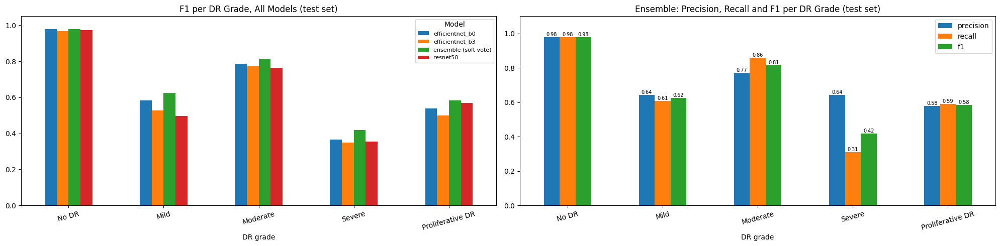

  figure saved: figures/15_evaluation/per_grade_scores.png
Cell 55 finished: per-grade scores saved for all models.
model             efficientnet_b0  efficientnet_b3  ensemble (soft vote)  resnet50
stage                                                                             
No DR                       0.978            0.974                 0.978     0.974
Mild                        0.589            0.518                 0.607     0.464
Moderate                    0.807            0.807                 0.860     0.800
Severe                      0.276            0.276                 0.310     0.310
Proliferative DR            0.568            0.477                 0.591     0.568

                  precision    recall  f1-score   support

           No DR      0.978     0.978     0.978       271
            Mild      0.642     0.607     0.624        56
        Moderate      0.772     0.860     0.814       150
          Severe      0.643     0.310     0.419        29
Proliferati

In [55]:
# Cell 55: precision, recall and F1 for every grade and every model, plus the full ensemble report
per_class_report_rows = []
for model_name, (true_labels_array, predicted_labels_array, _) in all_model_predictions_by_name.items():
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        true_labels_array, predicted_labels_array, labels=list_of_class_indices, zero_division=0)
    for class_index in list_of_class_indices:
        per_class_report_rows.append({"model": model_name, "stage": diagnosis_stage_names[class_index], "precision": precision_per_class[class_index],
                                      "recall": recall_per_class[class_index], "f1": f1_per_class[class_index], "test_photos": int(support_per_class[class_index])})
per_class_report_dataframe = pd.DataFrame(per_class_report_rows).round(3)
save_results_table(per_class_report_dataframe, "15_evaluation", "per_grade_precision_recall_f1_all_models.csv")
ensemble_classification_report_text = classification_report(ensemble_true_labels, ensemble_predicted_labels, labels=list_of_class_indices,
                                                            target_names=stage_names_in_order, digits=3, zero_division=0)
with open(os.path.join(results_folder_paths["15_evaluation"], "classification_report_ensemble.txt"), "w") as report_file:
    report_file.write(ensemble_classification_report_text)

figure_object, axis_array = plt.subplots(1, 2, figsize=(20, 5))
per_class_report_dataframe.pivot(index="stage", columns="model", values="f1").reindex(stage_names_in_order).plot(kind="bar", ax=axis_array[0])
axis_array[0].set_title("F1 per DR Grade, All Models (test set)")
axis_array[0].set_ylim(0, 1.05)
axis_array[0].legend(title="Model", fontsize=8)
ensemble_rows = per_class_report_dataframe[per_class_report_dataframe["model"] == "ensemble (soft vote)"].set_index("stage").reindex(stage_names_in_order)
ensemble_rows[["precision", "recall", "f1"]].plot(kind="bar", ax=axis_array[1])
for bar_container in axis_array[1].containers:
    axis_array[1].bar_label(bar_container, fmt="%.2f", fontsize=7)
axis_array[1].set_title("Ensemble: Precision, Recall and F1 per DR Grade (test set)")
axis_array[1].set_ylim(0, 1.1)
for current_axis in axis_array:
    current_axis.tick_params(axis="x", rotation=15)
    current_axis.set_xlabel("DR grade")
save_current_figure("15_evaluation", "per_grade_scores.png")

print("Cell 55 finished: per-grade scores saved for all models.")
print(per_class_report_dataframe.pivot(index="stage", columns="model", values="recall").reindex(stage_names_in_order).to_string())
print()
print(ensemble_classification_report_text)

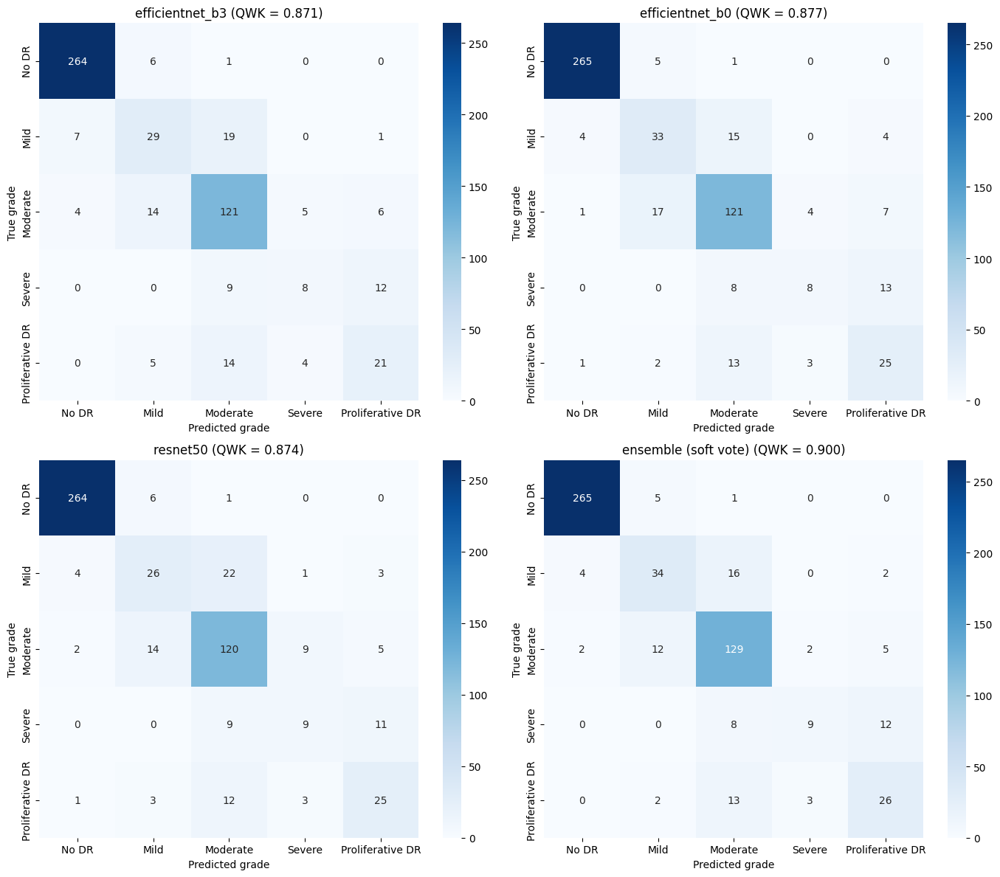

  figure saved: figures/15_evaluation/confusion_matrices_counts.png


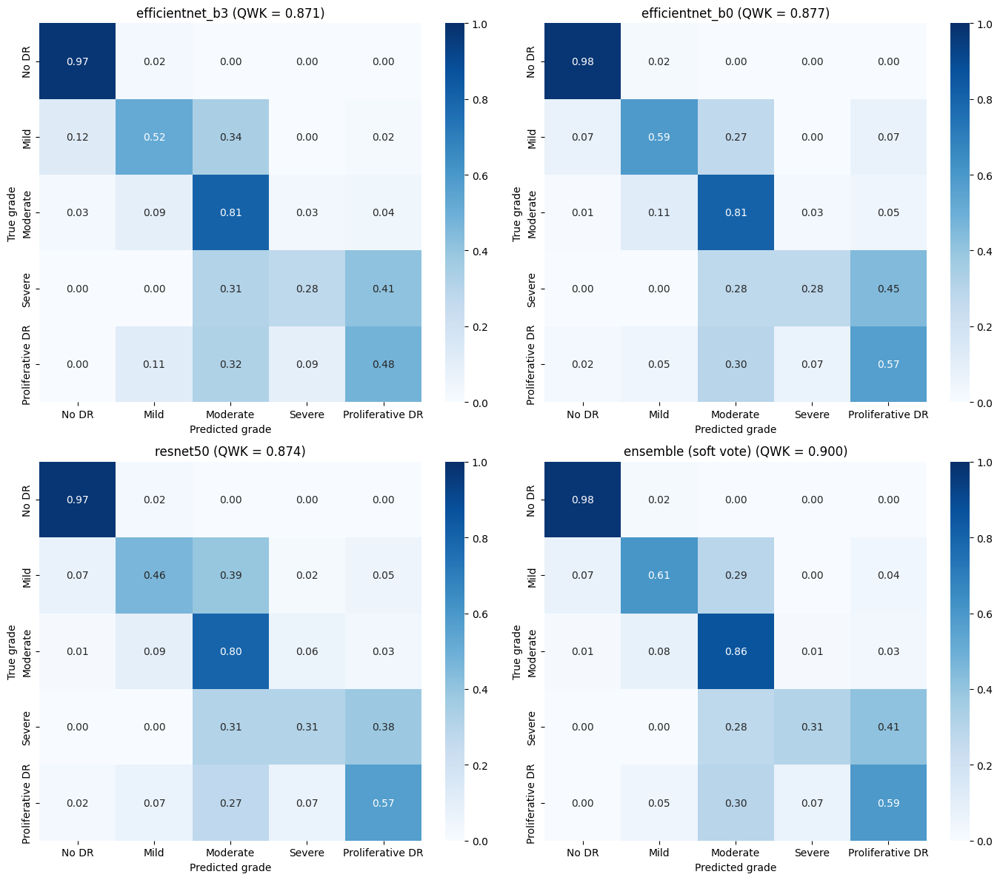

  figure saved: figures/15_evaluation/confusion_matrices_row_normalised.png
  table saved: results/15_evaluation/confusion_matrix_ensemble_counts.csv
Cell 56 finished: confusion matrices saved as counts and as row percentages.
                       predicted No DR  predicted Mild  predicted Moderate  predicted Severe  predicted Proliferative DR
true No DR                         265               5                   1                 0                           0
true Mild                            4              34                  16                 0                           2
true Moderate                        2              12                 129                 2                           5
true Severe                          0               0                   8                 9                          12
true Proliferative DR                0               2                  13                 3                          26


In [56]:
# Cell 56: confusion matrices for all four models, as raw counts and as percentages of each true grade
for matrix_style, value_format, file_name in [("counts", "d", "confusion_matrices_counts.png"), ("row_percent", ".2f", "confusion_matrices_row_normalised.png")]:
    figure_object, axis_grid = plt.subplots(2, 2, figsize=(14, 12))
    for plot_index, (model_name, (true_labels_array, predicted_labels_array, _)) in enumerate(all_model_predictions_by_name.items()):
        current_axis = axis_grid[plot_index // 2, plot_index % 2]
        matrix_values = confusion_matrix(true_labels_array, predicted_labels_array, labels=list_of_class_indices, normalize="true" if matrix_style == "row_percent" else None)
        seaborn_plotting_library.heatmap(matrix_values, annot=True, fmt=value_format, cmap="Blues", vmin=0, vmax=1 if matrix_style == "row_percent" else None,
                                         xticklabels=stage_names_in_order, yticklabels=stage_names_in_order, ax=current_axis)
        current_axis.set_title(f"{model_name} (QWK = {cohen_kappa_score(true_labels_array, predicted_labels_array, weights='quadratic'):.3f})")
        current_axis.set_xlabel("Predicted grade")
        current_axis.set_ylabel("True grade")
    save_current_figure("15_evaluation", file_name)
ensemble_confusion_matrix_dataframe = pd.DataFrame(confusion_matrix(ensemble_true_labels, ensemble_predicted_labels, labels=list_of_class_indices),
                                                   index=[f"true {stage}" for stage in stage_names_in_order], columns=[f"predicted {stage}" for stage in stage_names_in_order])
save_results_table(ensemble_confusion_matrix_dataframe, "15_evaluation", "confusion_matrix_ensemble_counts.csv", keep_index=True)

print("Cell 56 finished: confusion matrices saved as counts and as row percentages.")
print(ensemble_confusion_matrix_dataframe.to_string())

  table saved: results/15_evaluation/screening_metrics_referable_and_any_dr.csv


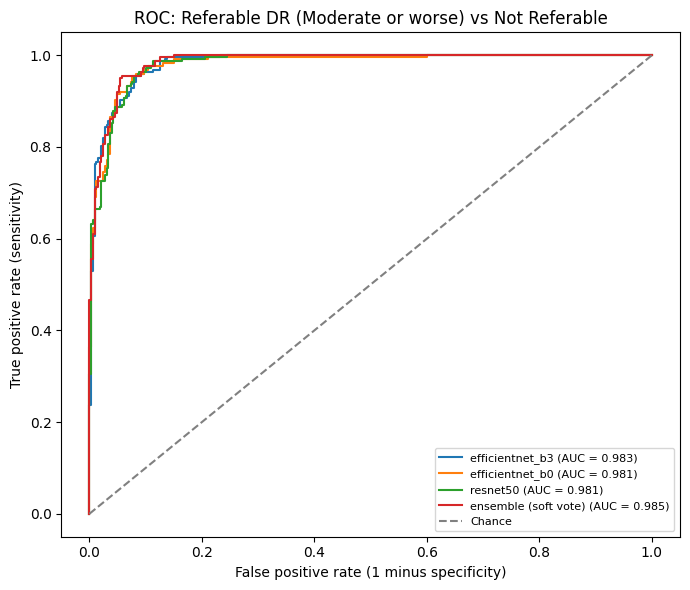

  figure saved: figures/15_evaluation/roc_referable_dr_all_models.png
Cell 57 finished: screening metrics and referable DR ROC curves saved.
               model            screening_question  sensitivity  specificity  positive_predictive_value  negative_predictive_value  roc_auc
     efficientnet_b3 referable_dr_grade_2_or_above       0.8969       0.9358                     0.9050                     0.9301   0.9829
     efficientnet_b3       any_dr_grade_1_or_above       0.9606       0.9742                     0.9745                     0.9600   0.9974
     efficientnet_b0 referable_dr_grade_2_or_above       0.9058       0.9388                     0.9099                     0.9360   0.9805
     efficientnet_b0       any_dr_grade_1_or_above       0.9785       0.9779                     0.9785                     0.9779   0.9980
            resnet50 referable_dr_grade_2_or_above       0.9103       0.9174                     0.8826                     0.9375   0.9810
            resnet5

In [57]:
# Cell 57: screening view, turning the 5 grades into two yes or no questions a clinic actually asks
def compute_binary_screening_metrics(true_binary_labels, predicted_binary_labels, positive_class_scores):
    true_positive_count = int(np.sum((true_binary_labels == 1) & (predicted_binary_labels == 1)))
    false_negative_count = int(np.sum((true_binary_labels == 1) & (predicted_binary_labels == 0)))
    true_negative_count = int(np.sum((true_binary_labels == 0) & (predicted_binary_labels == 0)))
    false_positive_count = int(np.sum((true_binary_labels == 0) & (predicted_binary_labels == 1)))
    safe_ratio = lambda numerator, denominator: numerator / denominator if denominator > 0 else float("nan")
    return {
        "true_positives": true_positive_count, "false_negatives": false_negative_count, "true_negatives": true_negative_count, "false_positives": false_positive_count,
        "sensitivity": safe_ratio(true_positive_count, true_positive_count + false_negative_count),
        "specificity": safe_ratio(true_negative_count, true_negative_count + false_positive_count),
        "positive_predictive_value": safe_ratio(true_positive_count, true_positive_count + false_positive_count),
        "negative_predictive_value": safe_ratio(true_negative_count, true_negative_count + false_negative_count),
        "roc_auc": roc_auc_score(true_binary_labels, positive_class_scores),
    }


screening_metric_rows = []
for model_name, (true_labels_array, predicted_labels_array, predicted_probability_array) in all_model_predictions_by_name.items():
    for screening_question_name, grade_threshold in {"referable_dr_grade_2_or_above": 2, "any_dr_grade_1_or_above": 1}.items():
        screening_metric_rows.append({"model": model_name, "screening_question": screening_question_name, **compute_binary_screening_metrics(
            (true_labels_array >= grade_threshold).astype(int), (predicted_labels_array >= grade_threshold).astype(int), predicted_probability_array[:, grade_threshold:].sum(axis=1))})
screening_metrics_dataframe = pd.DataFrame(screening_metric_rows).round(4)
save_results_table(screening_metrics_dataframe, "15_evaluation", "screening_metrics_referable_and_any_dr.csv")

figure_object, axis_object = plt.subplots(figsize=(7, 6))
for model_name, (true_labels_array, _, predicted_probability_array) in all_model_predictions_by_name.items():
    true_binary_labels = (true_labels_array >= 2).astype(int)
    referable_scores = predicted_probability_array[:, 2:].sum(axis=1)
    false_positive_rates, true_positive_rates, _ = roc_curve(true_binary_labels, referable_scores)
    axis_object.plot(false_positive_rates, true_positive_rates, label=f"{model_name} (AUC = {roc_auc_score(true_binary_labels, referable_scores):.3f})")
axis_object.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
axis_object.set_xlabel("False positive rate (1 minus specificity)")
axis_object.set_ylabel("True positive rate (sensitivity)")
axis_object.set_title("ROC: Referable DR (Moderate or worse) vs Not Referable")
axis_object.legend(fontsize=8, loc="lower right")
save_current_figure("15_evaluation", "roc_referable_dr_all_models.png")

print("Cell 57 finished: screening metrics and referable DR ROC curves saved.")
print(screening_metrics_dataframe[["model", "screening_question", "sensitivity", "specificity", "positive_predictive_value", "negative_predictive_value", "roc_auc"]].to_string(index=False))

In [58]:
# Cell 58: how often do the three models agree, and how accurate is the ensemble when they do and do not?
predictions_by_architecture = {name: per_architecture_test_results[name]["test_predicted_labels"] for name in architecture_names_to_compare}
pairwise_agreement_rates = {
    f"{first_name} vs {second_name}": float((predictions_by_architecture[first_name] == predictions_by_architecture[second_name]).mean())
    for first_index, first_name in enumerate(architecture_names_to_compare) for second_name in architecture_names_to_compare[first_index + 1:]
}
all_three_agree_mask = (predictions_by_architecture["efficientnet_b3"] == predictions_by_architecture["efficientnet_b0"]) & (predictions_by_architecture["efficientnet_b0"] == predictions_by_architecture["resnet50"])
ensemble_answer_is_correct = ensemble_predicted_labels == ensemble_true_labels
accuracy_when_models_agree = float(ensemble_answer_is_correct[all_three_agree_mask].mean())
accuracy_when_models_disagree = float(ensemble_answer_is_correct[~all_three_agree_mask].mean()) if (~all_three_agree_mask).any() else float("nan")
model_agreement_dataframe = pd.DataFrame(
    [{"comparison": pair_name, "agreement_percent": round(rate * 100, 1)} for pair_name, rate in pairwise_agreement_rates.items()]
    + [{"comparison": "all three models", "agreement_percent": round(float(all_three_agree_mask.mean()) * 100, 1)}]
)
save_results_table(model_agreement_dataframe, "15_evaluation", "model_agreement.csv")

print("Cell 58 finished: model agreement measured.")
print(model_agreement_dataframe.to_string(index=False))
print(f"Ensemble accuracy when all three agree: {accuracy_when_models_agree:.3f} ({int(all_three_agree_mask.sum())} photos)")
print(f"Ensemble accuracy when they disagree:   {accuracy_when_models_disagree:.3f} ({int((~all_three_agree_mask).sum())} photos)")

  table saved: results/15_evaluation/model_agreement.csv
Cell 58 finished: model agreement measured.
                        comparison  agreement_percent
efficientnet_b3 vs efficientnet_b0               89.1
       efficientnet_b3 vs resnet50               88.4
       efficientnet_b0 vs resnet50               89.5
                  all three models               84.0
Ensemble accuracy when all three agree: 0.881 (462 photos)
Ensemble accuracy when they disagree:   0.636 (88 photos)


In [59]:
# Cell 59: McNemar's test, is the ensemble really better than the best single model (chosen on validation) or just lucky?
def run_mcnemar_test_on_paired_predictions(first_model_correct, second_model_correct):
    first_right_second_wrong_count = int(np.sum(first_model_correct & ~second_model_correct))
    second_right_first_wrong_count = int(np.sum(~first_model_correct & second_model_correct))
    total_disagreements = first_right_second_wrong_count + second_right_first_wrong_count
    if total_disagreements == 0:
        return first_right_second_wrong_count, second_right_first_wrong_count, 0.0, 1.0
    chi_squared_statistic = (abs(first_right_second_wrong_count - second_right_first_wrong_count) - 1) ** 2 / total_disagreements
    return first_right_second_wrong_count, second_right_first_wrong_count, chi_squared_statistic, float(chi2.sf(chi_squared_statistic, df=1))


best_single_model_correct = per_architecture_test_results[best_single_architecture_name]["test_predicted_labels"] == ensemble_true_labels
ensemble_right_single_wrong_count, single_right_ensemble_wrong_count, mcnemar_statistic, mcnemar_p_value = run_mcnemar_test_on_paired_predictions(
    ensemble_answer_is_correct, best_single_model_correct)
ensemble_mcnemar_summary = {
    "best_single_model_by_validation_qwk": best_single_architecture_name,
    "ensemble_right_single_model_wrong": ensemble_right_single_wrong_count,
    "single_model_right_ensemble_wrong": single_right_ensemble_wrong_count,
    "chi_squared_statistic": round(float(mcnemar_statistic), 4),
    "p_value": round(float(mcnemar_p_value), 4),
    "significant_at_0_05": bool(mcnemar_p_value < 0.05),
}
save_results_json(ensemble_mcnemar_summary, "15_evaluation", "mcnemar_ensemble_vs_best_single.json")

print("Cell 59 finished: McNemar's test done.")
for summary_key, summary_value in ensemble_mcnemar_summary.items():
    print(f"  {summary_key}: {summary_value}")

  summary saved: results/15_evaluation/mcnemar_ensemble_vs_best_single.json
Cell 59 finished: McNemar's test done.
  best_single_model_by_validation_qwk: resnet50
  ensemble_right_single_model_wrong: 28
  single_model_right_ensemble_wrong: 9
  chi_squared_statistic: 8.7568
  p_value: 0.0031
  significant_at_0_05: True


  table saved: results/15_evaluation/qwk_detail_table.csv


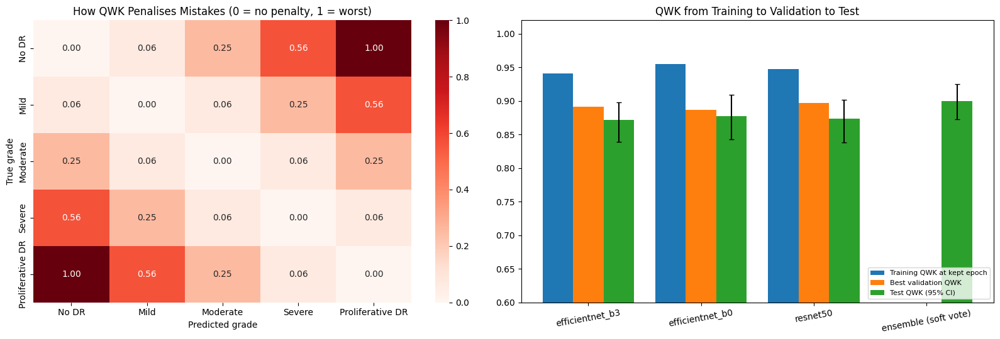

  figure saved: figures/15_evaluation/qwk_explained_and_train_val_test.png
Cell 60 finished: QWK detail table and chart saved.
               model  kept_epoch  train_qwk_at_kept_epoch  best_validation_qwk  train_minus_validation_gap  test_qwk  test_qwk_ci_low  test_qwk_ci_high  validation_to_test_change
     efficientnet_b3        12.0                   0.9412               0.8911                      0.0501    0.8715           0.8390            0.8981                    -0.0196
     efficientnet_b0        16.0                   0.9553               0.8865                      0.0688    0.8771           0.8422            0.9086                    -0.0094
            resnet50        13.0                   0.9477               0.8967                      0.0509    0.8735           0.8381            0.9019                    -0.0232
ensemble (soft vote)         NaN                      NaN                  NaN                         NaN    0.8998           0.8728            0.9253      

In [60]:
# Cell 60: everything about QWK in one place, from training through validation to test, plus how QWK scores mistakes
qwk_detail_rows = []
for training_result in all_training_results:
    architecture_name = training_result["architecture_name"]
    headline_row = headline_metrics_dataframe.set_index("model").loc[architecture_name]
    qwk_detail_rows.append({
        "model": architecture_name, "kept_epoch": training_result["best_epoch"],
        "train_qwk_at_kept_epoch": round(training_result["train_qwk_at_best_epoch"], 4),
        "best_validation_qwk": round(training_result["best_validation_qwk"], 4),
        "train_minus_validation_gap": round(training_result["train_qwk_at_best_epoch"] - training_result["best_validation_qwk"], 4),
        "test_qwk": headline_row["qwk"], "test_qwk_ci_low": headline_row["qwk_ci_low"], "test_qwk_ci_high": headline_row["qwk_ci_high"],
        "validation_to_test_change": round(headline_row["qwk"] - training_result["best_validation_qwk"], 4),
    })
ensemble_headline_row = headline_metrics_dataframe.set_index("model").loc["ensemble (soft vote)"]
qwk_detail_rows.append({"model": "ensemble (soft vote)", "test_qwk": ensemble_headline_row["qwk"],
                        "test_qwk_ci_low": ensemble_headline_row["qwk_ci_low"], "test_qwk_ci_high": ensemble_headline_row["qwk_ci_high"]})
qwk_detail_dataframe = pd.DataFrame(qwk_detail_rows)
save_results_table(qwk_detail_dataframe, "15_evaluation", "qwk_detail_table.csv")

number_of_grades = len(list_of_class_indices)
quadratic_penalty_weights = np.array([[(row - column) ** 2 / (number_of_grades - 1) ** 2 for column in list_of_class_indices] for row in list_of_class_indices])
figure_object, axis_array = plt.subplots(1, 2, figsize=(16, 5.5))
seaborn_plotting_library.heatmap(quadratic_penalty_weights, annot=True, fmt=".2f", cmap="Reds", xticklabels=stage_names_in_order, yticklabels=stage_names_in_order, ax=axis_array[0])
axis_array[0].set_title("How QWK Penalises Mistakes (0 = no penalty, 1 = worst)")
axis_array[0].set_xlabel("Predicted grade")
axis_array[0].set_ylabel("True grade")
model_positions = np.arange(len(qwk_detail_dataframe))
axis_array[1].bar(model_positions - 0.27, qwk_detail_dataframe["train_qwk_at_kept_epoch"].fillna(0), 0.27, label="Training QWK at kept epoch")
axis_array[1].bar(model_positions, qwk_detail_dataframe["best_validation_qwk"].fillna(0), 0.27, label="Best validation QWK")
axis_array[1].bar(model_positions + 0.27, qwk_detail_dataframe["test_qwk"], 0.27,
                  yerr=[qwk_detail_dataframe["test_qwk"] - qwk_detail_dataframe["test_qwk_ci_low"], qwk_detail_dataframe["test_qwk_ci_high"] - qwk_detail_dataframe["test_qwk"]],
                  capsize=3, label="Test QWK (95% CI)")
axis_array[1].set_xticks(model_positions)
axis_array[1].set_xticklabels(qwk_detail_dataframe["model"], rotation=10)
axis_array[1].set_ylim(0.6, 1.02)
axis_array[1].set_title("QWK from Training to Validation to Test")
axis_array[1].legend(fontsize=8, loc="lower right")
save_current_figure("15_evaluation", "qwk_explained_and_train_val_test.png")

print("Cell 60 finished: QWK detail table and chart saved.")
print(qwk_detail_dataframe.to_string(index=False))
print("A one-grade mistake costs 0.06 of the worst-case penalty, while mixing up No DR and Proliferative costs 1.0.")
print("That is why QWK suits ordered grades better than plain accuracy.")

In [61]:
# Cell 61: should the app use the ensemble or the best single model? Put all the evidence for that decision in one place
headline_by_model = headline_metrics_dataframe.set_index("model")
latency_by_model = inference_latency_dataframe.set_index("model")
ensemble_qwk_gain = float(headline_by_model.loc["ensemble (soft vote)", "qwk"] - headline_by_model.loc[best_single_architecture_name, "qwk"])
confidence_intervals_overlap = bool(
    headline_by_model.loc["ensemble (soft vote)", "qwk_ci_low"] <= headline_by_model.loc[best_single_architecture_name, "qwk_ci_high"])
disagreement_signal_strength = accuracy_when_models_agree - accuracy_when_models_disagree
if ensemble_mcnemar_summary["significant_at_0_05"] and ensemble_qwk_gain > 0:
    ensemble_decision = "use_ensemble_because_it_is_significantly_better"
elif disagreement_signal_strength > 0.1:
    ensemble_decision = "use_ensemble_for_its_disagreement_warning_not_for_accuracy"
else:
    ensemble_decision = "use_best_single_model"
ensemble_decision_summary = {
    "best_single_model_by_validation": best_single_architecture_name,
    "test_qwk_gain_of_ensemble": round(ensemble_qwk_gain, 4),
    "qwk_confidence_intervals_overlap": confidence_intervals_overlap,
    "mcnemar_p_value": ensemble_mcnemar_summary["p_value"],
    "ensemble_accuracy_when_models_agree": round(accuracy_when_models_agree, 3),
    "ensemble_accuracy_when_models_disagree": round(accuracy_when_models_disagree, 3),
    "cpu_milliseconds_best_single": float(latency_by_model.loc[best_single_architecture_name, "cpu_milliseconds_for_one_photo"]),
    "cpu_milliseconds_ensemble": float(latency_by_model.loc["ensemble (all three)", "cpu_milliseconds_for_one_photo"]),
    "decision": ensemble_decision,
}
save_results_json(ensemble_decision_summary, "15_evaluation", "ensemble_vs_single_model_decision.json")

print("Cell 61 finished: ensemble decision evidence saved.")
for summary_key, summary_value in ensemble_decision_summary.items():
    print(f"  {summary_key}: {summary_value}")

  summary saved: results/15_evaluation/ensemble_vs_single_model_decision.json
Cell 61 finished: ensemble decision evidence saved.
  best_single_model_by_validation: resnet50
  test_qwk_gain_of_ensemble: 0.0263
  qwk_confidence_intervals_overlap: True
  mcnemar_p_value: 0.0031
  ensemble_accuracy_when_models_agree: 0.881
  ensemble_accuracy_when_models_disagree: 0.636
  cpu_milliseconds_best_single: 180.4
  cpu_milliseconds_ensemble: 367.4
  decision: use_ensemble_because_it_is_significantly_better


## 13. Where Is the Model Looking? (Grad-CAM)
Grad-CAM draws a heat map over the photo. Red areas pushed the model towards its answer the most, so a doctor can check whether it looked at real lesions or at something irrelevant. It is shown for the best single model (picked on validation QWK), because the ensemble is an average of three models and has no single set of layers to look inside.

In [62]:
# Cell 62: build Grad-CAM with hooks on the last convolution block of the best single model
class GradientWeightedClassActivationMapping:
    def __init__(self, model, target_convolutional_layer):
        self.model = model
        self.captured_activations = None
        self.captured_gradients = None
        target_convolutional_layer.register_forward_hook(self._store_activations)
        target_convolutional_layer.register_full_backward_hook(self._store_gradients)

    def _store_activations(self, module, layer_input, layer_output):
        self.captured_activations = layer_output.detach()

    def _store_gradients(self, module, grad_input, grad_output):
        self.captured_gradients = grad_output[0].detach()

    def generate_heatmap_for_image(self, input_image_tensor, target_class_index=None):
        self.model.eval()
        predicted_logits = self.model(input_image_tensor.unsqueeze(0).to(compute_device))
        if target_class_index is None:
            target_class_index = predicted_logits.argmax(dim=1).item()
        self.model.zero_grad()
        predicted_logits[0, target_class_index].backward()
        channel_importance_weights = self.captured_gradients.mean(dim=(2, 3), keepdim=True)
        heatmap_as_numpy = torch.relu((channel_importance_weights * self.captured_activations).sum(dim=1).squeeze()).cpu().numpy()
        if heatmap_as_numpy.max() > 0:
            heatmap_as_numpy = heatmap_as_numpy / heatmap_as_numpy.max()
        return heatmap_as_numpy, target_class_index


def overlay_heatmap_on_image(original_image_rgb, heatmap_array):
    resized_heatmap = cv2.resize(heatmap_array, (original_image_rgb.shape[1], original_image_rgb.shape[0]))
    heatmap_as_colour_rgb = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * resized_heatmap), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(original_image_rgb, 0.6, heatmap_as_colour_rgb, 0.4, 0)


def load_final_preprocessed_photo(image_id_code):
    return preprocess_fundus_image(build_image_path_from_id(image_id_code), project_configuration["target_image_size"], final_training_recipe["preprocessing_method"])


best_single_model_for_gradcam = load_trained_model(best_single_architecture_name, compute_device)
grad_cam_target_layer = best_single_model_for_gradcam.layer4[-1] if best_single_architecture_name == "resnet50" else best_single_model_for_gradcam.features[-1]
grad_cam_generator = GradientWeightedClassActivationMapping(best_single_model_for_gradcam, grad_cam_target_layer)

print("Cell 62 finished: Grad-CAM ready on", best_single_architecture_name, "using its last convolution block.")

Cell 62 finished: Grad-CAM ready on resnet50 using its last convolution block.


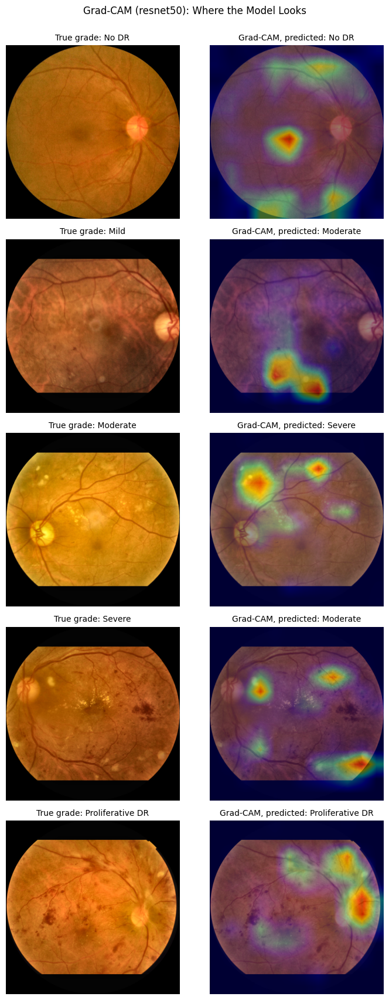

  figure saved: figures/16_gradcam/gradcam_one_photo_per_grade.png
Cell 63 finished: Grad-CAM heat maps saved for one test photo of each grade.


In [63]:
# Cell 63: Grad-CAM heat maps for one test photo of each grade
figure_object, axis_grid = plt.subplots(len(list_of_class_indices), 2, figsize=(7.5, len(list_of_class_indices) * 3.4), squeeze=False)
for class_label in list_of_class_indices:
    chosen_row = test_split_in_loader_order[test_split_in_loader_order["diagnosis"] == class_label].iloc[0]
    preprocessed_image = load_final_preprocessed_photo(chosen_row["id_code"])
    generated_heatmap, predicted_class_index = grad_cam_generator.generate_heatmap_for_image(evaluation_time_image_transform(preprocessed_image))
    axis_grid[class_label, 0].imshow(preprocessed_image)
    axis_grid[class_label, 0].set_title(f"True grade: {diagnosis_stage_names[class_label]}", fontsize=10)
    axis_grid[class_label, 1].imshow(overlay_heatmap_on_image(preprocessed_image, generated_heatmap))
    axis_grid[class_label, 1].set_title(f"Grad-CAM, predicted: {diagnosis_stage_names[predicted_class_index]}", fontsize=10)
    axis_grid[class_label, 0].axis("off")
    axis_grid[class_label, 1].axis("off")
plt.suptitle(f"Grad-CAM ({best_single_architecture_name}): Where the Model Looks", y=1.0)
save_current_figure("16_gradcam", "gradcam_one_photo_per_grade.png")

print("Cell 63 finished: Grad-CAM heat maps saved for one test photo of each grade.")

## 14. Error Analysis
How far off are the wrong answers, which grades get mixed up, does the ensemble know when it is unsure, and what was the model looking at when it got things badly wrong?

  table saved: results/17_error_analysis/error_distance_all_models.csv
  table saved: results/17_error_analysis/most_common_confusions_ensemble.csv


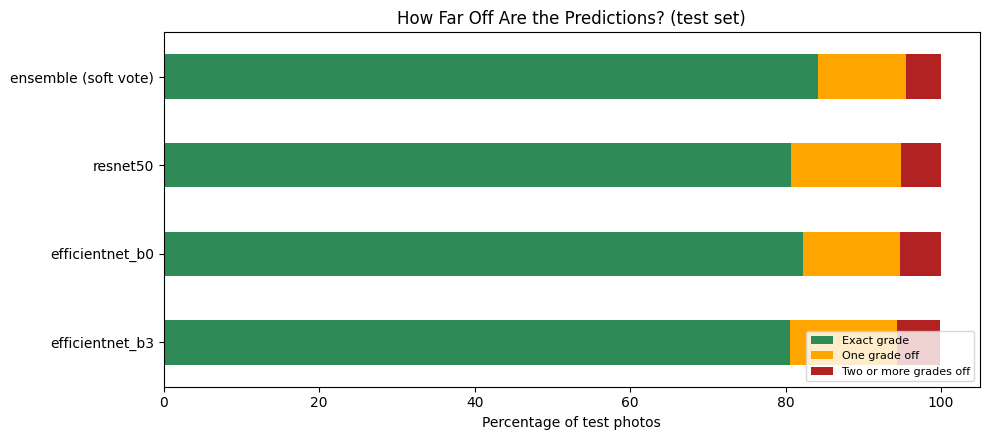

  figure saved: figures/17_error_analysis/error_distance_all_models.png
Cell 64 finished: mistake distance and most common confusions saved.
               model  exact_grade_percent  one_grade_off_percent  two_or_more_grades_off_percent  share_of_mistakes_one_grade_off_percent
     efficientnet_b3                 80.5                   13.8                             5.6                                     71.0
     efficientnet_b0                 82.2                   12.5                             5.3                                     70.4
            resnet50                 80.7                   14.2                             5.1                                     73.6
ensemble (soft vote)                 84.2                   11.3                             4.5                                     71.3

      true_stage  predicted_stage  number_of_photos  share_of_all_mistakes_percent    direction
            Mild         Moderate                16                     

In [64]:
# Cell 64: how far off are the mistakes, and which grade pairs get mixed up most often
error_distance_rows = []
for model_name, (true_labels_array, predicted_labels_array, _) in all_model_predictions_by_name.items():
    absolute_grade_distance = np.abs(true_labels_array - predicted_labels_array)
    number_of_errors = int((absolute_grade_distance > 0).sum())
    error_distance_rows.append({
        "model": model_name,
        "exact_grade_percent": round(float((absolute_grade_distance == 0).mean() * 100), 1),
        "one_grade_off_percent": round(float((absolute_grade_distance == 1).mean() * 100), 1),
        "two_or_more_grades_off_percent": round(float((absolute_grade_distance >= 2).mean() * 100), 1),
        "share_of_mistakes_one_grade_off_percent": round(float((absolute_grade_distance == 1).sum() / number_of_errors * 100), 1) if number_of_errors > 0 else 0.0,
    })
error_distance_dataframe = pd.DataFrame(error_distance_rows)
save_results_table(error_distance_dataframe, "17_error_analysis", "error_distance_all_models.csv")

ensemble_mistake_pairs = pd.DataFrame({"true_grade": ensemble_true_labels, "predicted_grade": ensemble_predicted_labels})
ensemble_mistake_pairs = ensemble_mistake_pairs[ensemble_mistake_pairs["true_grade"] != ensemble_mistake_pairs["predicted_grade"]]
most_common_confusions_dataframe = ensemble_mistake_pairs.value_counts().rename("number_of_photos").reset_index()
most_common_confusions_dataframe["true_stage"] = most_common_confusions_dataframe["true_grade"].map(diagnosis_stage_names)
most_common_confusions_dataframe["predicted_stage"] = most_common_confusions_dataframe["predicted_grade"].map(diagnosis_stage_names)
most_common_confusions_dataframe["share_of_all_mistakes_percent"] = (most_common_confusions_dataframe["number_of_photos"] / max(len(ensemble_mistake_pairs), 1) * 100).round(1)
most_common_confusions_dataframe["direction"] = np.where(most_common_confusions_dataframe["predicted_grade"] > most_common_confusions_dataframe["true_grade"], "over-graded", "under-graded")
save_results_table(most_common_confusions_dataframe, "17_error_analysis", "most_common_confusions_ensemble.csv")

figure_object, axis_object = plt.subplots(figsize=(10, 4.5))
error_distance_dataframe.set_index("model")[["exact_grade_percent", "one_grade_off_percent", "two_or_more_grades_off_percent"]].plot(
    kind="barh", stacked=True, ax=axis_object, color=["seagreen", "orange", "firebrick"])
axis_object.set_xlabel("Percentage of test photos")
axis_object.set_ylabel("")
axis_object.set_title("How Far Off Are the Predictions? (test set)")
axis_object.legend(["Exact grade", "One grade off", "Two or more grades off"], loc="lower right", fontsize=8)
save_current_figure("17_error_analysis", "error_distance_all_models.png")

print("Cell 64 finished: mistake distance and most common confusions saved.")
print(error_distance_dataframe.to_string(index=False))
print()
print(most_common_confusions_dataframe[["true_stage", "predicted_stage", "number_of_photos", "share_of_all_mistakes_percent", "direction"]].head(8).to_string(index=False))

  table saved: results/17_error_analysis/ensemble_accuracy_by_confidence.csv
  summary saved: results/17_error_analysis/ensemble_confidence_summary.json


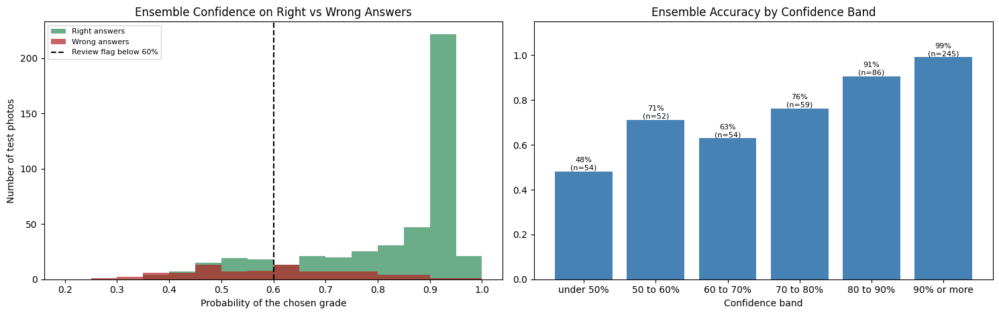

  figure saved: figures/17_error_analysis/ensemble_confidence_right_vs_wrong.png
Cell 65 finished: confidence analysis saved.
       band  photos  accuracy  share_of_test_photos_percent
  under 50%      54     0.481                           9.8
  50 to 60%      52     0.712                           9.5
  60 to 70%      54     0.630                           9.8
  70 to 80%      59     0.763                          10.7
  80 to 90%      86     0.907                          15.6
90% or more     245     0.992                          44.5
  low_confidence_threshold_used_by_app: 0.6
  average_confidence_when_right: 0.825
  average_confidence_when_wrong: 0.6
  share_of_photos_flagged_percent: 19.3
  accuracy_on_flagged_photos: 0.594
  accuracy_on_unflagged_photos: 0.901
  share_of_mistakes_caught_by_confidence_flag_percent: 49.4
  share_of_mistakes_caught_by_confidence_or_disagreement_percent: 52.9


In [65]:
# Cell 65: does the ensemble know when it is unsure? Compare its confidence on right and wrong answers
low_confidence_threshold = 0.6
ensemble_top_probability = ensemble_averaged_probabilities.max(axis=1)
photo_is_flagged_for_review = ensemble_top_probability < low_confidence_threshold
confidence_band_labels = ["under 50%", "50 to 60%", "60 to 70%", "70 to 80%", "80 to 90%", "90% or more"]
confidence_band_series = pd.cut(ensemble_top_probability, bins=[0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0001], labels=confidence_band_labels, right=False)
confidence_band_dataframe = pd.DataFrame({"band": confidence_band_series, "correct": ensemble_answer_is_correct}).groupby("band", observed=False).agg(
    photos=("correct", "size"), accuracy=("correct", "mean")).reset_index()
confidence_band_dataframe["share_of_test_photos_percent"] = (confidence_band_dataframe["photos"] / len(ensemble_top_probability) * 100).round(1)
confidence_band_dataframe["accuracy"] = confidence_band_dataframe["accuracy"].round(3)
save_results_table(confidence_band_dataframe, "17_error_analysis", "ensemble_accuracy_by_confidence.csv")

confidence_summary = {
    "low_confidence_threshold_used_by_app": low_confidence_threshold,
    "average_confidence_when_right": round(float(ensemble_top_probability[ensemble_answer_is_correct].mean()), 3),
    "average_confidence_when_wrong": round(float(ensemble_top_probability[~ensemble_answer_is_correct].mean()), 3) if (~ensemble_answer_is_correct).any() else None,
    "share_of_photos_flagged_percent": round(float(photo_is_flagged_for_review.mean() * 100), 1),
    "accuracy_on_flagged_photos": round(float(ensemble_answer_is_correct[photo_is_flagged_for_review].mean()), 3) if photo_is_flagged_for_review.any() else None,
    "accuracy_on_unflagged_photos": round(float(ensemble_answer_is_correct[~photo_is_flagged_for_review].mean()), 3) if (~photo_is_flagged_for_review).any() else None,
    "share_of_mistakes_caught_by_confidence_flag_percent": round(float(photo_is_flagged_for_review[~ensemble_answer_is_correct].mean() * 100), 1) if (~ensemble_answer_is_correct).any() else None,
    "share_of_mistakes_caught_by_confidence_or_disagreement_percent": round(float((photo_is_flagged_for_review | ~all_three_agree_mask)[~ensemble_answer_is_correct].mean() * 100), 1) if (~ensemble_answer_is_correct).any() else None,
}
save_results_json(confidence_summary, "17_error_analysis", "ensemble_confidence_summary.json")

figure_object, axis_array = plt.subplots(1, 2, figsize=(15, 4.8))
histogram_bins = np.linspace(0.2, 1.0, 17)
axis_array[0].hist(ensemble_top_probability[ensemble_answer_is_correct], bins=histogram_bins, alpha=0.7, color="seagreen", label="Right answers")
axis_array[0].hist(ensemble_top_probability[~ensemble_answer_is_correct], bins=histogram_bins, alpha=0.7, color="firebrick", label="Wrong answers")
axis_array[0].axvline(low_confidence_threshold, color="black", linestyle="--", label=f"Review flag below {low_confidence_threshold:.0%}")
axis_array[0].set_title("Ensemble Confidence on Right vs Wrong Answers")
axis_array[0].set_xlabel("Probability of the chosen grade")
axis_array[0].set_ylabel("Number of test photos")
axis_array[0].legend(fontsize=8)
confidence_bars = axis_array[1].bar(confidence_band_dataframe["band"].astype(str), confidence_band_dataframe["accuracy"].fillna(0), color="steelblue")
axis_array[1].bar_label(confidence_bars, labels=[f"{accuracy:.0%}\n(n={photos})" for accuracy, photos in zip(confidence_band_dataframe["accuracy"].fillna(0), confidence_band_dataframe["photos"])], fontsize=8)
axis_array[1].set_ylim(0, 1.15)
axis_array[1].set_title("Ensemble Accuracy by Confidence Band")
axis_array[1].set_xlabel("Confidence band")
save_current_figure("17_error_analysis", "ensemble_confidence_right_vs_wrong.png")

print("Cell 65 finished: confidence analysis saved.")
print(confidence_band_dataframe.to_string(index=False))
for summary_key, summary_value in confidence_summary.items():
    print(f"  {summary_key}: {summary_value}")

In [66]:
# Cell 66: save every test photo's prediction from every model into one table for the report
per_image_predictions_dataframe = test_split_in_loader_order.rename(columns={"diagnosis": "true_grade"})
assert np.array_equal(per_image_predictions_dataframe["true_grade"].values, ensemble_true_labels), "Test loader order does not match the test table."
for architecture_name in architecture_names_to_compare:
    per_image_predictions_dataframe[f"{architecture_name}_predicted_grade"] = per_architecture_test_results[architecture_name]["test_predicted_labels"]
per_image_predictions_dataframe["ensemble_predicted_grade"] = ensemble_predicted_labels
for class_index in list_of_class_indices:
    per_image_predictions_dataframe["ensemble_probability_" + diagnosis_stage_names[class_index].lower().replace(" ", "_")] = ensemble_averaged_probabilities[:, class_index].round(4)
per_image_predictions_dataframe["ensemble_confidence"] = ensemble_top_probability.round(4)
per_image_predictions_dataframe["flagged_low_confidence"] = photo_is_flagged_for_review
per_image_predictions_dataframe["all_three_models_agree"] = all_three_agree_mask
per_image_predictions_dataframe["ensemble_is_correct"] = ensemble_answer_is_correct
save_results_table(per_image_predictions_dataframe, "17_error_analysis", "test_set_predictions_per_photo.csv")

print("Cell 66 finished: per-photo predictions saved for", len(per_image_predictions_dataframe), "test photos.")

  table saved: results/17_error_analysis/test_set_predictions_per_photo.csv
Cell 66 finished: per-photo predictions saved for 550 test photos.


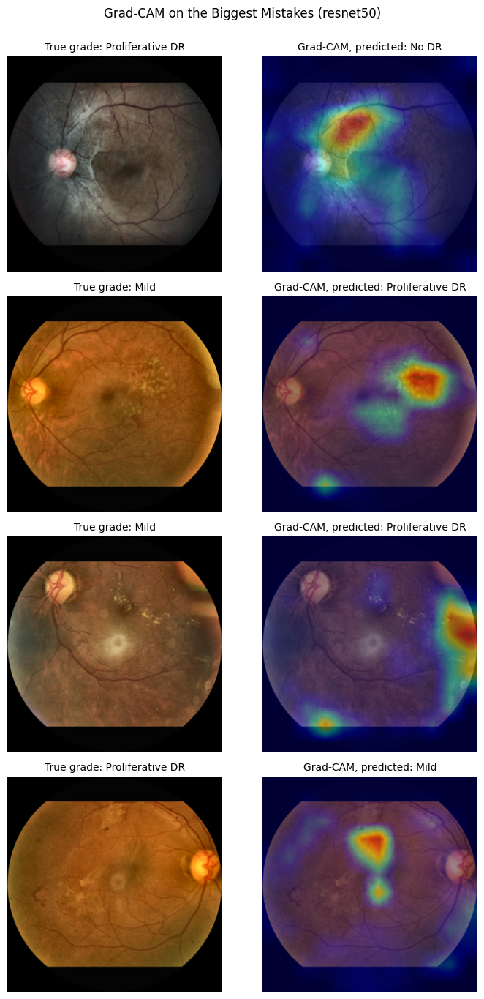

  figure saved: figures/17_error_analysis/gradcam_biggest_mistakes.png
Cell 67 finished: Grad-CAM saved for the 4 biggest mistakes.
Mistakes by the best single model: 106 | two or more grades off: 28


In [67]:
# Cell 67: Grad-CAM on the test photos the best single model got most wrong
best_single_model_predicted_labels = per_architecture_test_results[best_single_architecture_name]["test_predicted_labels"]
grade_distance_of_each_prediction = np.abs(ensemble_true_labels - best_single_model_predicted_labels)
misclassified_test_positions = np.where(grade_distance_of_each_prediction > 0)[0]
misclassified_positions_largest_first = misclassified_test_positions[np.argsort(-grade_distance_of_each_prediction[misclassified_test_positions], kind="stable")]
number_of_mistakes_to_show = min(4, len(misclassified_positions_largest_first))
if number_of_mistakes_to_show == 0:
    print("Cell 67 finished: the best single model made no mistakes on the test set, nothing to show.")
else:
    figure_object, axis_grid = plt.subplots(number_of_mistakes_to_show, 2, figsize=(7.5, number_of_mistakes_to_show * 3.4), squeeze=False)
    for row_index, test_position in enumerate(misclassified_positions_largest_first[:number_of_mistakes_to_show]):
        chosen_row = test_split_in_loader_order.iloc[test_position]
        preprocessed_image = load_final_preprocessed_photo(chosen_row["id_code"])
        generated_heatmap, predicted_class_index = grad_cam_generator.generate_heatmap_for_image(evaluation_time_image_transform(preprocessed_image))
        axis_grid[row_index, 0].imshow(preprocessed_image)
        axis_grid[row_index, 0].set_title(f"True grade: {diagnosis_stage_names[int(chosen_row['diagnosis'])]}", fontsize=10)
        axis_grid[row_index, 1].imshow(overlay_heatmap_on_image(preprocessed_image, generated_heatmap))
        axis_grid[row_index, 1].set_title(f"Grad-CAM, predicted: {diagnosis_stage_names[predicted_class_index]}", fontsize=10)
        axis_grid[row_index, 0].axis("off")
        axis_grid[row_index, 1].axis("off")
    plt.suptitle(f"Grad-CAM on the Biggest Mistakes ({best_single_architecture_name})", y=1.0)
    save_current_figure("17_error_analysis", "gradcam_biggest_mistakes.png")
    print("Cell 67 finished: Grad-CAM saved for the", number_of_mistakes_to_show, "biggest mistakes.")
    print("Mistakes by the best single model:", len(misclassified_test_positions), "| two or more grades off:", int((grade_distance_of_each_prediction >= 2).sum()))

## 15. Final Summary and Web App Export
All key numbers go into one summary file for the report. The three models and every setting the app needs, including the chosen preprocessing method, are packed for the Streamlit app, and a final check makes sure the app's copy gives the same answers as the notebook.

Download from the Kaggle output: `figures/` and `results/` for the report, `app_export/` into the app folder, and `demo_images/` for the video (keep those outside the app folder).

In [68]:
# Cell 68: gather every key number from every section into one summary file for the report
referable_screening_row = screening_metrics_dataframe[(screening_metrics_dataframe["model"] == "ensemble (soft vote)")
                                                      & (screening_metrics_dataframe["screening_question"] == "referable_dr_grade_2_or_above")].iloc[0]
consolidated_results_summary = {
    "run_metadata": {"run_finished_at": datetime.now().isoformat(timespec="minutes"), "torch_version": torch.__version__,
                     "torchvision_version": torchvision.__version__, "gpu_name": torch.cuda.get_device_name(0) if is_gpu_available else "cpu", "random_seed": RANDOM_SEED},
    "dataset": {"total_photos": int(len(diabetic_retinopathy_labels_dataframe)), "imbalance_ratio": round(float(imbalance_ratio), 1),
                "split_sizes": {name: int(len(frame)) for name, frame in split_dataframes_by_name.items()}},
    "preprocessing_tests": preprocessing_test_summary_dataframe.round(1).to_dict(orient="records"),
    "local_contrast_by_method": contrast_summary_dataframe.round(3).to_dict(orient="records"),
    "image_size_study": image_size_study_summary,
    "experiment_decisions": decision_table_dataframe.to_dict(orient="records"),
    "final_training_recipe": final_training_recipe,
    "overfitting_gaps": overfitting_gap_dataframe.to_dict(orient="records"),
    "qwk_detail": qwk_detail_dataframe.to_dict(orient="records"),
    "headline_metrics": headline_metrics_dataframe.set_index("model").to_dict(orient="index"),
    "screening_metrics": screening_metrics_dataframe.to_dict(orient="records"),
    "mcnemar_ensemble_vs_best_single": ensemble_mcnemar_summary,
    "ensemble_decision": ensemble_decision_summary,
    "error_distance": error_distance_dataframe.set_index("model").to_dict(orient="index"),
    "confidence_analysis": confidence_summary,
}
save_results_json(consolidated_results_summary, "18_app_export", "consolidated_results_summary.json")

print("Cell 68 finished: consolidated summary saved.")
print("Sections in the file:", list(consolidated_results_summary.keys()))

  summary saved: results/18_app_export/consolidated_results_summary.json
Cell 68 finished: consolidated summary saved.
Sections in the file: ['run_metadata', 'dataset', 'preprocessing_tests', 'local_contrast_by_method', 'image_size_study', 'experiment_decisions', 'final_training_recipe', 'overfitting_gaps', 'qwk_detail', 'headline_metrics', 'screening_metrics', 'mcnemar_ensemble_vs_best_single', 'ensemble_decision', 'error_distance', 'confidence_analysis']


In [69]:
# Cell 69: pack the three models and every setting the web app needs into the app_export folder
app_export_models_folder_path = os.path.join(app_export_folder_path, "models")
os.makedirs(app_export_models_folder_path, exist_ok=True)
exported_model_rows = []
for architecture_name in architecture_names_to_compare:
    full_precision_state = torch.load(build_main_checkpoint_path(architecture_name), map_location="cpu")
    export_file_name = f"{architecture_name}_fp16.pth"
    export_file_path = os.path.join(app_export_models_folder_path, export_file_name)
    torch.save({key: (value.half() if value.is_floating_point() else value) for key, value in full_precision_state.items()}, export_file_path)
    exported_model_rows.append({"architecture": architecture_name, "exported_file": export_file_name,
                                "original_size_mb": round(os.path.getsize(build_main_checkpoint_path(architecture_name)) / 1e6, 1),
                                "exported_size_mb": round(os.path.getsize(export_file_path) / 1e6, 1)})

app_configuration = {
    "model_version": f"aptos2019-ensemble-{datetime.now():%Y%m%d}",
    "created_on": datetime.now().isoformat(timespec="minutes"),
    "dataset": "APTOS 2019 Blindness Detection (Kaggle)",
    "target_image_size": project_configuration["target_image_size"],
    "preprocessing_method": final_training_recipe["preprocessing_method"],
    "dark_pixel_brightness_threshold": project_configuration["dark_pixel_brightness_threshold"],
    "clahe_clip_limit": project_configuration["clahe_clip_limit"],
    "clahe_tile_grid_size": project_configuration["clahe_tile_grid_size"],
    "ben_graham_blur_divisor": project_configuration["ben_graham_blur_divisor"],
    "normalisation_mean": imagenet_normalisation_mean,
    "normalisation_std": imagenet_normalisation_std,
    "stage_names": stage_names_in_order,
    "referable_grade_threshold": 2,
    "low_confidence_threshold": low_confidence_threshold,
    "architectures": [{"name": row["architecture"], "weights_file": row["exported_file"]} for row in exported_model_rows],
    "grad_cam_architecture": best_single_architecture_name,
    "ensemble_decision": ensemble_decision,
    "test_set_performance": {
        "test_photos": int(len(test_split_dataframe)),
        "ensemble_accuracy": round(float(ensemble_test_accuracy), 4),
        "ensemble_qwk": round(float(ensemble_test_qwk), 4),
        "ensemble_macro_f1": round(float(headline_by_model.loc["ensemble (soft vote)", "macro_f1"]), 4),
        "referable_dr_sensitivity": round(float(referable_screening_row["sensitivity"]), 4),
        "referable_dr_specificity": round(float(referable_screening_row["specificity"]), 4),
        "referable_dr_auc": round(float(referable_screening_row["roc_auc"]), 4),
    },
    "training_environment": {"torch": torch.__version__, "torchvision": torchvision.__version__},
}
with open(os.path.join(app_export_folder_path, "app_config.json"), "w") as app_config_file:
    json_module.dump(app_configuration, app_config_file, indent=2, default=convert_numpy_values_for_json)
exported_model_dataframe = pd.DataFrame(exported_model_rows)
save_results_table(exported_model_dataframe, "18_app_export", "exported_app_models.csv")

print("Cell 69 finished: app bundle written to", app_export_folder_path)
print(exported_model_dataframe.to_string(index=False))
print("Preprocessing method written to the app settings:", app_configuration["preprocessing_method"])

  table saved: results/18_app_export/exported_app_models.csv
Cell 69 finished: app bundle written to /kaggle/working/app_export
   architecture            exported_file  original_size_mb  exported_size_mb
efficientnet_b3 efficientnet_b3_fp16.pth              43.4              21.8
efficientnet_b0 efficientnet_b0_fp16.pth              16.4               8.2
       resnet50        resnet50_fp16.pth              94.4              47.2
Preprocessing method written to the app settings: clahe


In [70]:
# Cell 70: rebuild the web app's prediction steps using only the exported files, on the CPU like the app
def load_exported_models_for_cpu(exported_configuration, models_folder_path):
    loaded_models = {}
    for architecture_entry in exported_configuration["architectures"]:
        model = build_transfer_learning_model(architecture_entry["name"], len(exported_configuration["stage_names"]), final_training_recipe["head_dropout"])
        half_precision_state = torch.load(os.path.join(models_folder_path, architecture_entry["weights_file"]), map_location="cpu")
        model.load_state_dict({key: (value.float() if value.is_floating_point() else value) for key, value in half_precision_state.items()})
        loaded_models[architecture_entry["name"]] = model.eval()
    return loaded_models


def predict_stage_with_ensemble_from_raw_image(image_rgb, loaded_models, exported_configuration):
    preprocessed_image = run_preprocessing_steps(image_rgb, exported_configuration["target_image_size"], exported_configuration["preprocessing_method"])["resized"]
    input_tensor = evaluation_time_image_transform(preprocessed_image).unsqueeze(0)
    with torch.no_grad():
        per_model_probabilities = {name: torch.softmax(model(input_tensor), dim=1)[0].numpy() for name, model in loaded_models.items()}
    averaged_probabilities = np.mean(list(per_model_probabilities.values()), axis=0)
    return {"predicted_stage_index": int(averaged_probabilities.argmax()), "averaged_probabilities": averaged_probabilities}


exported_cpu_models = load_exported_models_for_cpu(app_configuration, app_export_models_folder_path)
print("Cell 70 finished: exported models loaded on the CPU and the app's prediction function is ready.")

Cell 70 finished: exported models loaded on the CPU and the app's prediction function is ready.


In [71]:
# Cell 71: check the app copy agrees with the notebook on 50 test photos, and save one demo photo per grade for the video
parity_check_positions = []
for class_label in list_of_class_indices:
    parity_check_positions.extend(np.where(ensemble_true_labels == class_label)[0][:10].tolist())
parity_rows = []
for test_position in parity_check_positions:
    test_row = test_split_in_loader_order.iloc[test_position]
    app_prediction = predict_stage_with_ensemble_from_raw_image(load_image_as_rgb(build_image_path_from_id(test_row["id_code"])), exported_cpu_models, app_configuration)
    parity_rows.append({"id_code": test_row["id_code"], "true_grade": int(test_row["diagnosis"]),
                        "notebook_prediction": int(ensemble_predicted_labels[test_position]), "app_prediction": app_prediction["predicted_stage_index"],
                        "largest_probability_difference": float(np.abs(app_prediction["averaged_probabilities"] - ensemble_averaged_probabilities[test_position]).max())})
parity_dataframe = pd.DataFrame(parity_rows)
parity_dataframe["same_grade"] = parity_dataframe["notebook_prediction"] == parity_dataframe["app_prediction"]
save_results_table(parity_dataframe.round(5), "18_app_export", "app_vs_notebook_parity_check.csv")

demo_image_rows = []
for class_label in list_of_class_indices:
    grade_rows = per_image_predictions_dataframe[(per_image_predictions_dataframe["true_grade"] == class_label) & per_image_predictions_dataframe["ensemble_is_correct"]]
    if len(grade_rows) == 0:
        grade_rows = per_image_predictions_dataframe[per_image_predictions_dataframe["true_grade"] == class_label]
    chosen_demo_row = grade_rows.iloc[0]
    demo_file_name = f"demo_grade{class_label}_{diagnosis_stage_names[class_label].lower().replace(' ', '_')}_{chosen_demo_row['id_code']}.png"
    Image.fromarray(load_image_as_rgb(build_image_path_from_id(chosen_demo_row["id_code"]))).save(os.path.join(demo_images_folder_path, demo_file_name))
    demo_image_rows.append({"file_name": demo_file_name, "true_grade": diagnosis_stage_names[class_label],
                            "ensemble_prediction": diagnosis_stage_names[int(chosen_demo_row["ensemble_predicted_grade"])],
                            "ensemble_confidence": float(chosen_demo_row["ensemble_confidence"])})
save_results_table(pd.DataFrame(demo_image_rows), "18_app_export", "demo_images_for_video.csv")

print("Cell 71 finished: app parity check and demo photos saved.")
print(f"Same grade from the app copy and the notebook: {parity_dataframe['same_grade'].mean():.1%} of {len(parity_dataframe)} photos")
print(f"Largest probability difference: {parity_dataframe['largest_probability_difference'].max():.4f}")
print("Tiny differences come from half-precision weights and CPU vs GPU maths. A grade can only flip when two grades were almost tied.")
print(pd.DataFrame(demo_image_rows).to_string(index=False))

  table saved: results/18_app_export/app_vs_notebook_parity_check.csv
  table saved: results/18_app_export/demo_images_for_video.csv
Cell 71 finished: app parity check and demo photos saved.
Same grade from the app copy and the notebook: 100.0% of 50 photos
Largest probability difference: 0.0064
Tiny differences come from half-precision weights and CPU vs GPU maths. A grade can only flip when two grades were almost tied.
                                    file_name       true_grade ensemble_prediction  ensemble_confidence
           demo_grade0_no_dr_d9ad2a0ec026.png            No DR               No DR               0.9445
            demo_grade1_mild_01b3aed3ed4c.png             Mild                Mild               0.6556
        demo_grade2_moderate_89ee1fa16f90.png         Moderate            Moderate               0.4472
          demo_grade3_severe_8b76c3c5cb3e.png           Severe              Severe               0.5751
demo_grade4_proliferative_dr_3ac3fbfca7d4.png Prolifera

In [72]:
# Cell 72: list every saved figure, table, model and app file so they are easy to find for the report
for output_folder_name in ["figures", "results", "models", "app_export", "demo_images"]:
    output_folder_path = os.path.join(output_root_directory, output_folder_name)
    print(f"\n{output_folder_path}")
    for current_directory, _, file_names in sorted(os.walk(output_folder_path)):
        for file_name in sorted(file_names):
            file_path = os.path.join(current_directory, file_name)
            print(f"  {os.path.relpath(file_path, output_folder_path)}  ({os.path.getsize(file_path) / 1e6:.2f} MB)")
print("\nCell 72 finished: every saved output listed above. Photo caches stayed in /tmp, so they are not in the saved output.")


/kaggle/working/figures
  01_data_exploration/class_distribution.png  (0.10 MB)
  01_data_exploration/resolution_and_aspect_ratio.png  (0.07 MB)
  01_data_exploration/sample_photos_by_grade.png  (4.95 MB)
  02_preprocessing/preprocessing_step_by_step.png  (9.41 MB)
  02_preprocessing_methods/egg_shape_fix_before_after.png  (1.63 MB)
  02_preprocessing_methods/eye_shape_kept_by_padding.png  (2.38 MB)
  02_preprocessing_methods/preprocessing_steps_and_methods_per_grade.png  (11.32 MB)
  03_image_size_study/image_size_detail_vs_cost.png  (0.31 MB)
  03_image_size_study/image_size_patch_comparison.png  (1.29 MB)
  03_image_size_study/image_size_ssim_vs_cost.png  (0.31 MB)
  04_augmentation_and_splits/augmentation_preview.png  (1.84 MB)
  05_augmentation_policies/augmentation_policies_preview.png  (5.74 MB)
  05_models_and_training/train_vs_validation_curves_per_model.png  (0.54 MB)
  05_models_and_training/validation_curves_all_models.png  (0.32 MB)
  06_evaluation/confusion_matrices_coun